# Notebook 5 — Trust, Fairness & Safety Evaluation

## Project
**Trustworthy Agentic AI for Healthcare**

## Purpose

This notebook evaluates the trustworthiness, fairness, calibration,
robustness, and safety of the leakage-controlled early-detection
diabetes prediction model developed in the previous notebooks.

The primary model evaluated in this notebook is the
**Early-Detection Logistic Regression** model selected as the
reference baseline after leakage-control analysis.

The evaluation is performed on the held-out test set and does not
retrain or modify the final predictive model.

## Main Objectives

1. Verify the integrity of the exported model predictions.
2. Verify the final classification threshold selected using
   out-of-fold training predictions.
3. Evaluate overall predictive performance.
4. Evaluate performance across clinically meaningful demographic
   and health-related subgroups.
5. Quantify subgroup disparities in sensitivity, specificity,
   precision, F1-score, and other relevant metrics.
6. Evaluate calibration of predicted diabetes probabilities.
7. Investigate false-negative and false-positive behaviour from a
   clinical safety perspective.
8. Examine prediction confidence and potentially uncertain cases.
9. Identify high-confidence prediction errors and potential
   failure modes.
10. Assess robustness using bootstrap-based uncertainty estimates.
11. Generate a structured trust, fairness, and safety assessment.
12. Export all evaluation results for subsequent explainability,
    clinical decision-support, and agentic-AI stages.

## Methodological Principles

- The held-out test set remains independent of model development.
- The final classification threshold is fixed at **0.35**, selected
  using out-of-fold training predictions.
- No threshold is selected using test-set performance.
- No predictive model is retrained using the test set.
- Fairness analysis will be interpreted in a clinical context rather
  than treating statistical parity alone as sufficient evidence of
  fairness.
- Calibration, discrimination, subgroup behaviour, and safety
  characteristics will be considered together.
- Limitations and potential sources of bias will be explicitly
  documented.

## Expected Outcome

The notebook will produce a transparent evidence base describing
where the early-detection model performs reliably, where performance
differs across subgroups, and where additional safeguards or
clinical review may be required.

In [ ]:
# ================================================================================
# CELL 1 — NOTEBOOK 5 ENVIRONMENT & REPRODUCIBILITY SETUP
# ================================================================================

print("=" * 80)
print("NOTEBOOK 5 — TRUST, FAIRNESS & SAFETY EVALUATION")
print("=" * 80)

# -------------------------------------------------------------------------------
# 1. Core libraries
# -------------------------------------------------------------------------------

import os
import json
import warnings
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

# -------------------------------------------------------------------------------
# 2. Reproducibility
# -------------------------------------------------------------------------------

RANDOM_STATE = 42

np.random.seed(
    RANDOM_STATE
)

# -------------------------------------------------------------------------------
# 3. Notebook identification
# -------------------------------------------------------------------------------

NOTEBOOK_NAME = (
    "Notebook 5 — Trust, Fairness & Safety Evaluation"
)

MODEL_NAME = (
    "Early-Detection Logistic Regression"
)

FINAL_THRESHOLD = 0.35

# -------------------------------------------------------------------------------
# 4. Working directories
# -------------------------------------------------------------------------------

NOTEBOOK5_DIR = (
    "/content/notebook5_trust_fairness_safety"
)

EXPORT_DIR = os.path.join(
    NOTEBOOK5_DIR,
    "exports"
)

os.makedirs(
    EXPORT_DIR,
    exist_ok=True
)

# -------------------------------------------------------------------------------
# 5. Environment summary
# -------------------------------------------------------------------------------

print("\nNotebook:")
print(NOTEBOOK_NAME)

print("\nPrimary model:")
print(MODEL_NAME)

print("\nFinal classification threshold:")
print(FINAL_THRESHOLD)

print("\nRandom state:")
print(RANDOM_STATE)

print("\nWorking directory:")
print(NOTEBOOK5_DIR)

print("\nExport directory:")
print(EXPORT_DIR)

print("\n✓ Core environment initialized.")
print("✓ Reproducibility seed established.")
print("✓ Notebook 5 configuration initialized.")

NOTEBOOK 5 — TRUST, FAIRNESS & SAFETY EVALUATION

Notebook:
Notebook 5 — Trust, Fairness & Safety Evaluation

Primary model:
Early-Detection Logistic Regression

Final classification threshold:
0.35

Random state:
42

Working directory:
/content/notebook5_trust_fairness_safety

Export directory:
/content/notebook5_trust_fairness_safety/exports

✓ Core environment initialized.
✓ Reproducibility seed established.
✓ Notebook 5 configuration initialized.


In [ ]:
# ================================================================================
# CELL 2 — UPLOAD NOTEBOOK 3 EXPORT PACKAGE
# ================================================================================

print("=" * 80)
print("UPLOAD NOTEBOOK 3 EXPORT PACKAGE")
print("=" * 80)

from google.colab import files
import os
import zipfile

print("""
Notebook 5 requires the exported artifacts from Notebook 3.

Please upload the Notebook 3 export ZIP file that you created
at the end of Notebook 3.

Do NOT upload the original dataset yet.
Do NOT upload all Notebook 1–4 files.

We will load only the required artifacts first.
""")

uploaded = files.upload()

print("\nUploaded file(s):")

for filename in uploaded.keys():
    print(" -", filename)

# -------------------------------------------------------------------------------
# Identify ZIP file
# -------------------------------------------------------------------------------

zip_files = [
    filename
    for filename in uploaded.keys()
    if filename.lower().endswith(".zip")
]

if not zip_files:
    raise FileNotFoundError(
        "No ZIP export package was uploaded. "
        "Please upload the Notebook 3 export ZIP file."
    )

notebook3_zip = zip_files[0]

print("\nNotebook 3 export package identified:")
print(" -", notebook3_zip)

# -------------------------------------------------------------------------------
# Extract package
# -------------------------------------------------------------------------------

NOTEBOOK3_IMPORT_DIR = os.path.join(
    NOTEBOOK5_DIR,
    "notebook3_import"
)

os.makedirs(
    NOTEBOOK3_IMPORT_DIR,
    exist_ok=True
)

with zipfile.ZipFile(
    notebook3_zip,
    "r"
) as zip_ref:

    zip_ref.extractall(
        NOTEBOOK3_IMPORT_DIR
    )

print("\n✓ Notebook 3 export package extracted.")

# -------------------------------------------------------------------------------
# Display extracted files
# -------------------------------------------------------------------------------

print("\nExtracted files:")

for root, dirs, filenames in os.walk(
    NOTEBOOK3_IMPORT_DIR
):

    for filename in filenames:

        full_path = os.path.join(
            root,
            filename
        )

        relative_path = os.path.relpath(
            full_path,
            NOTEBOOK3_IMPORT_DIR
        )

        print(
            " -",
            relative_path
        )

print("\n✓ Notebook 3 artifacts are now available to Notebook 5.")

UPLOAD NOTEBOOK 3 EXPORT PACKAGE

Notebook 5 requires the exported artifacts from Notebook 3.

Please upload the Notebook 3 export ZIP file that you created
at the end of Notebook 3.

Do NOT upload the original dataset yet.
Do NOT upload all Notebook 1–4 files.

We will load only the required artifacts first.



Saving notebook3_early_detection_exports.zip to notebook3_early_detection_exports.zip

Uploaded file(s):
 - notebook3_early_detection_exports.zip

Notebook 3 export package identified:
 - notebook3_early_detection_exports.zip

✓ Notebook 3 export package extracted.

Extracted files:
 - early_detection_processed_feature_names.csv
 - early_detection_test_predictions.csv
 - early_detection_logistic_regression.joblib
 - early_detection_oof_training_predictions.csv
 - early_detection_model_metadata.json
 - early_detection_preprocessor.joblib

✓ Notebook 3 artifacts are now available to Notebook 5.


In [ ]:
# ================================================================================
# CELL 3 — LOAD & AUDIT NOTEBOOK 3 ARTIFACTS
# ================================================================================

print("=" * 80)
print("LOAD & AUDIT NOTEBOOK 3 ARTIFACTS")
print("=" * 80)

import os
import json
import pandas as pd
import numpy as np
import joblib

# -------------------------------------------------------------------------------
# 1. Locate extracted Notebook 3 files
# -------------------------------------------------------------------------------

def find_file(filename):
    """
    Locate a specific Notebook 3 artifact inside the extracted
    Notebook 3 import directory.
    """

    matches = []

    for root, dirs, files_in_dir in os.walk(
        NOTEBOOK3_IMPORT_DIR
    ):
        if filename in files_in_dir:
            matches.append(
                os.path.join(root, filename)
            )

    if not matches:
        raise FileNotFoundError(
            f"Required file not found: {filename}"
        )

    return matches[0]


# -------------------------------------------------------------------------------
# 2. Locate all required artifacts
# -------------------------------------------------------------------------------

TEST_PREDICTIONS_PATH = find_file(
    "early_detection_test_predictions.csv"
)

OOF_PREDICTIONS_PATH = find_file(
    "early_detection_oof_training_predictions.csv"
)

FEATURE_NAMES_PATH = find_file(
    "early_detection_processed_feature_names.csv"
)

MODEL_METADATA_PATH = find_file(
    "early_detection_model_metadata.json"
)

MODEL_PATH = find_file(
    "early_detection_logistic_regression.joblib"
)

PREPROCESSOR_PATH = find_file(
    "early_detection_preprocessor.joblib"
)

print("\nNotebook 3 artifact locations:")

print(
    "Test predictions :",
    TEST_PREDICTIONS_PATH
)

print(
    "OOF predictions  :",
    OOF_PREDICTIONS_PATH
)

print(
    "Feature names    :",
    FEATURE_NAMES_PATH
)

print(
    "Model metadata   :",
    MODEL_METADATA_PATH
)

print(
    "Logistic model   :",
    MODEL_PATH
)

print(
    "Preprocessor     :",
    PREPROCESSOR_PATH
)


# -------------------------------------------------------------------------------
# 3. Load prediction files
# -------------------------------------------------------------------------------

test_predictions_n3 = pd.read_csv(
    TEST_PREDICTIONS_PATH
)

oof_predictions_n3 = pd.read_csv(
    OOF_PREDICTIONS_PATH
)

feature_names_n3 = pd.read_csv(
    FEATURE_NAMES_PATH
)


# -------------------------------------------------------------------------------
# 4. Load model metadata
# -------------------------------------------------------------------------------

with open(
    MODEL_METADATA_PATH,
    "r"
) as f:

    model_metadata_n3 = json.load(f)


# -------------------------------------------------------------------------------
# 5. Load trained model and preprocessor
# -------------------------------------------------------------------------------

early_lr_n3 = joblib.load(
    MODEL_PATH
)

preprocessor_n3 = joblib.load(
    PREPROCESSOR_PATH
)


# -------------------------------------------------------------------------------
# 6. Basic dataset audit
# -------------------------------------------------------------------------------

print("\n" + "=" * 80)
print("PREDICTION DATASET AUDIT")
print("=" * 80)

print("\nTest prediction dataset:")
print(
    "Shape:",
    test_predictions_n3.shape
)

print(
    "Rows:",
    len(test_predictions_n3)
)

print(
    "Columns:",
    len(test_predictions_n3.columns)
)

print("\nTest prediction columns:")

for column in test_predictions_n3.columns:
    print(" -", column)


print("\n" + "-" * 80)

print("\nOOF training prediction dataset:")
print(
    "Shape:",
    oof_predictions_n3.shape
)

print(
    "Rows:",
    len(oof_predictions_n3)
)

print(
    "Columns:",
    len(oof_predictions_n3.columns)
)

print("\nOOF prediction columns:")

for column in oof_predictions_n3.columns:
    print(" -", column)


# -------------------------------------------------------------------------------
# 7. Feature-name audit
# -------------------------------------------------------------------------------

print("\n" + "=" * 80)
print("PROCESSED FEATURE NAME AUDIT")
print("=" * 80)

print(
    "\nProcessed feature-name table shape:",
    feature_names_n3.shape
)

print(
    "Number of processed features:",
    len(feature_names_n3)
)

print("\nFirst 20 feature-name records:")

display(
    feature_names_n3.head(20)
)


# -------------------------------------------------------------------------------
# 8. Model metadata audit
# -------------------------------------------------------------------------------

print("\n" + "=" * 80)
print("MODEL METADATA AUDIT")
print("=" * 80)

print("\nMetadata contents:")

print(
    json.dumps(
        model_metadata_n3,
        indent=2
    )
)


# -------------------------------------------------------------------------------
# 9. Model / preprocessor audit
# -------------------------------------------------------------------------------

print("\n" + "=" * 80)
print("MODEL & PREPROCESSOR AUDIT")
print("=" * 80)

print("\nLogistic Regression object:")
print(
    type(early_lr_n3).__name__
)

print(
    "Number of model coefficients:",
    early_lr_n3.coef_.shape
)

print("\nPreprocessor object:")
print(
    type(preprocessor_n3).__name__
)

print(
    "Number of processed output features:",
    len(
        preprocessor_n3.get_feature_names_out()
    )
)


# -------------------------------------------------------------------------------
# 10. Final integrity checks
# -------------------------------------------------------------------------------

print("\n" + "=" * 80)
print("NOTEBOOK 3 ARTIFACT INTEGRITY CHECK")
print("=" * 80)

assert len(test_predictions_n3) > 0
assert len(oof_predictions_n3) > 0

assert early_lr_n3 is not None
assert preprocessor_n3 is not None

assert len(
    preprocessor_n3.get_feature_names_out()
) == early_lr_n3.coef_.shape[1]

print(
    "✓ Test prediction data loaded."
)

print(
    "✓ OOF prediction data loaded."
)

print(
    "✓ Feature names loaded."
)

print(
    "✓ Model metadata loaded."
)

print(
    "✓ Logistic Regression model loaded."
)

print(
    "✓ Preprocessor loaded."
)

print(
    "✓ Model coefficient dimensions match "
    "preprocessor output dimensions."
)

print("\n✓ Notebook 3 artifacts successfully loaded into Notebook 5.")

LOAD & AUDIT NOTEBOOK 3 ARTIFACTS

Notebook 3 artifact locations:
Test predictions : /content/notebook5_trust_fairness_safety/notebook3_import/early_detection_test_predictions.csv
OOF predictions  : /content/notebook5_trust_fairness_safety/notebook3_import/early_detection_oof_training_predictions.csv
Feature names    : /content/notebook5_trust_fairness_safety/notebook3_import/early_detection_processed_feature_names.csv
Model metadata   : /content/notebook5_trust_fairness_safety/notebook3_import/early_detection_model_metadata.json
Logistic model   : /content/notebook5_trust_fairness_safety/notebook3_import/early_detection_logistic_regression.joblib
Preprocessor     : /content/notebook5_trust_fairness_safety/notebook3_import/early_detection_preprocessor.joblib

PREDICTION DATASET AUDIT

Test prediction dataset:
Shape: (6242, 3)
Rows: 6242
Columns: 3

Test prediction columns:
 - y_true
 - predicted_probability
 - predicted_class_threshold_0_35

--------------------------------------------

,feature_index,processed_feature_name
0,0,numeric__SDDSRVYR
1,1,numeric__RIDSTATR
2,2,numeric__RIAGENDR
3,3,numeric__RIDAGEYR
4,4,numeric__RIDRETH1
5,5,numeric__RIDRETH3
6,6,numeric__RIDEXMON
7,7,numeric__DMDBORN4
8,8,numeric__DMDYRUSZ
9,9,numeric__DMDEDUC2



MODEL METADATA AUDIT

Metadata contents:
{
  "threshold_information": {
    "model": "Early-Detection Logistic Regression",
    "threshold": 0.35,
    "threshold_selection_method": "5-fold out-of-fold training predictions",
    "target_sensitivity": 0.75,
    "test_set_used_for_threshold_selection": false
  },
  "test_metrics": {
    "accuracy": 0.8394745273950657,
    "precision": 0.7032495401594114,
    "sensitivity": 0.6888888888888889,
    "specificity": 0.8942538780860826,
    "f1_score": 0.695995145631068,
    "roc_auc": 0.9008532675126514,
    "pr_auc": 0.7662478009065461,
    "true_negatives": 4093,
    "false_positives": 484,
    "false_negatives": 518,
    "true_positives": 1147
  },
  "training_rows": 25227,
  "testing_rows": 6242,
  "training_participants": 11755,
  "testing_participants": 2939,
  "participant_overlap": 0,
  "raw_features": 214,
  "processed_features": 517,
  "high_confidence_proxies_excluded": 22
}

MODEL & PREPROCESSOR AUDIT

Logistic Regression object:


In [ ]:
# ================================================================================
# CELL 4 — VALIDATE IMPORTED PREDICTION ARTIFACTS
# ================================================================================

print("=" * 80)
print("VALIDATE IMPORTED PREDICTION ARTIFACTS")
print("=" * 80)

# -------------------------------------------------------------------------------
# 1. Define paths to the imported Notebook 3 artifacts
# -------------------------------------------------------------------------------

TEST_PREDICTIONS_PATH = (
    "/content/notebook5_trust_fairness_safety/"
    "notebook3_import/early_detection_test_predictions.csv"
)

OOF_PREDICTIONS_PATH = (
    "/content/notebook5_trust_fairness_safety/"
    "notebook3_import/early_detection_oof_training_predictions.csv"
)

print("\nNotebook 3 prediction artifact paths:")
print("Test predictions:", TEST_PREDICTIONS_PATH)
print("OOF predictions :", OOF_PREDICTIONS_PATH)

# -------------------------------------------------------------------------------
# 2. Load prediction datasets
# -------------------------------------------------------------------------------

test_predictions = pd.read_csv(
    TEST_PREDICTIONS_PATH
)

oof_predictions = pd.read_csv(
    OOF_PREDICTIONS_PATH
)

print("\n✓ Test prediction dataset loaded.")
print("✓ OOF prediction dataset loaded.")

# -------------------------------------------------------------------------------
# 3. Basic shape audit
# -------------------------------------------------------------------------------

print("\nPrediction dataset shapes:")
print("Test predictions:", test_predictions.shape)
print("OOF predictions :", oof_predictions.shape)

# -------------------------------------------------------------------------------
# 4. Validate test prediction columns
# -------------------------------------------------------------------------------

required_test_columns = [
    "y_true",
    "predicted_probability",
    "predicted_class_threshold_0_35"
]

missing_test_columns = [
    col
    for col in required_test_columns
    if col not in test_predictions.columns
]

if missing_test_columns:
    raise ValueError(
        f"Missing required test prediction columns: "
        f"{missing_test_columns}"
    )

print("\n✓ Test prediction columns validated.")

# -------------------------------------------------------------------------------
# 5. Validate OOF prediction columns
# -------------------------------------------------------------------------------

required_oof_columns = [
    "y_true",
    "oof_probability"
]

missing_oof_columns = [
    col
    for col in required_oof_columns
    if col not in oof_predictions.columns
]

if missing_oof_columns:
    raise ValueError(
        f"Missing required OOF prediction columns: "
        f"{missing_oof_columns}"
    )

print("✓ OOF prediction columns validated.")

# -------------------------------------------------------------------------------
# 6. Validate target values
# -------------------------------------------------------------------------------

test_target_values = sorted(
    test_predictions["y_true"].unique().tolist()
)

oof_target_values = sorted(
    oof_predictions["y_true"].unique().tolist()
)

print("\nTarget-value audit:")
print("Test target values:", test_target_values)
print("OOF target values :", oof_target_values)

if not set(test_target_values).issubset({0, 1}):
    raise ValueError(
        "Unexpected target values detected in test predictions."
    )

if not set(oof_target_values).issubset({0, 1}):
    raise ValueError(
        "Unexpected target values detected in OOF predictions."
    )

print("✓ Binary target encoding confirmed.")

# -------------------------------------------------------------------------------
# 7. Validate probability ranges
# -------------------------------------------------------------------------------

if not test_predictions["predicted_probability"].between(
    0, 1
).all():

    raise ValueError(
        "Invalid test probability values detected."
    )

if not oof_predictions["oof_probability"].between(
    0, 1
).all():

    raise ValueError(
        "Invalid OOF probability values detected."
    )

print("✓ Test probabilities are within [0, 1].")
print("✓ OOF probabilities are within [0, 1].")

# -------------------------------------------------------------------------------
# 8. Missing-value audit
# -------------------------------------------------------------------------------

test_missing = test_predictions[
    required_test_columns
].isna().sum()

oof_missing = oof_predictions[
    required_oof_columns
].isna().sum()

print("\nMissing-value audit — test:")
print(test_missing)

print("\nMissing-value audit — OOF:")
print(oof_missing)

if test_missing.sum() > 0:
    raise ValueError(
        "Missing values detected in required test prediction fields."
    )

if oof_missing.sum() > 0:
    raise ValueError(
        "Missing values detected in required OOF prediction fields."
    )

print("\n✓ No missing values in required prediction fields.")

# -------------------------------------------------------------------------------
# 9. Verify threshold consistency
# -------------------------------------------------------------------------------

FINAL_THRESHOLD = 0.35

recalculated_test_class = (
    test_predictions["predicted_probability"]
    >= FINAL_THRESHOLD
).astype(int)

stored_test_class = (
    test_predictions[
        "predicted_class_threshold_0_35"
    ].astype(int)
)

threshold_alignment = (
    recalculated_test_class.values
    ==
    stored_test_class.values
).all()

print("\nThreshold consistency audit:")
print("Final threshold:", FINAL_THRESHOLD)

if not threshold_alignment:
    raise ValueError(
        "Stored test classifications do not match "
        "the 0.35 probability threshold."
    )

print("✓ Stored classifications match threshold 0.35.")

# -------------------------------------------------------------------------------
# 10. Check expected row counts from Notebook 3 metadata
# -------------------------------------------------------------------------------

expected_test_rows = 6242
expected_oof_rows = 25227

print("\nRow-count consistency:")
print("Expected test rows:", expected_test_rows)
print("Actual test rows  :", len(test_predictions))

print("Expected OOF rows :", expected_oof_rows)
print("Actual OOF rows   :", len(oof_predictions))

if len(test_predictions) != expected_test_rows:
    raise ValueError(
        "Unexpected number of test prediction rows."
    )

if len(oof_predictions) != expected_oof_rows:
    raise ValueError(
        "Unexpected number of OOF prediction rows."
    )

print("✓ Prediction row counts match Notebook 3 metadata.")

# -------------------------------------------------------------------------------
# 11. Final audit summary
# -------------------------------------------------------------------------------

print("\n" + "=" * 80)
print("NOTEBOOK 3 PREDICTION ARTIFACT AUDIT SUMMARY")
print("=" * 80)

print("✓ Test predictions loaded")
print("✓ OOF predictions loaded")
print("✓ Required columns present")
print("✓ Binary targets confirmed")
print("✓ Probability ranges valid")
print("✓ No required missing values")
print("✓ Threshold 0.35 verified")
print("✓ Test row count verified")
print("✓ OOF row count verified")

print("\n" + "=" * 80)
print("✓ CELL 4 COMPLETED SUCCESSFULLY")
print("=" * 80)

VALIDATE IMPORTED PREDICTION ARTIFACTS

Notebook 3 prediction artifact paths:
Test predictions: /content/notebook5_trust_fairness_safety/notebook3_import/early_detection_test_predictions.csv
OOF predictions : /content/notebook5_trust_fairness_safety/notebook3_import/early_detection_oof_training_predictions.csv

✓ Test prediction dataset loaded.
✓ OOF prediction dataset loaded.

Prediction dataset shapes:
Test predictions: (6242, 3)
OOF predictions : (25227, 2)

✓ Test prediction columns validated.
✓ OOF prediction columns validated.

Target-value audit:
Test target values: [0, 1]
OOF target values : [0, 1]
✓ Binary target encoding confirmed.
✓ Test probabilities are within [0, 1].
✓ OOF probabilities are within [0, 1].

Missing-value audit — test:
y_true                            0
predicted_probability             0
predicted_class_threshold_0_35    0
dtype: int64

Missing-value audit — OOF:
y_true             0
oof_probability    0
dtype: int64

✓ No missing values in required predi

In [ ]:
# ================================================================================
# CELL 5 — ESTABLISH NOTEBOOK 5 EVALUATION OBJECTS
# ================================================================================

import numpy as np
import pandas as pd

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    brier_score_loss
)

print("=" * 80)
print("ESTABLISH NOTEBOOK 5 EVALUATION OBJECTS")
print("=" * 80)

# -------------------------------------------------------------------------------
# 1. Define the final evaluation threshold
# -------------------------------------------------------------------------------

FINAL_THRESHOLD = 0.35

print("\nFinal classification threshold:")
print(f"  {FINAL_THRESHOLD:.2f}")

# -------------------------------------------------------------------------------
# 2. Extract test-set evaluation arrays
# -------------------------------------------------------------------------------

y_test_nb5 = test_predictions["y_true"].to_numpy()

y_test_proba_nb5 = (
    test_predictions["predicted_probability"].to_numpy()
)

y_test_pred_nb5 = (
    y_test_proba_nb5 >= FINAL_THRESHOLD
).astype(int)

print("\nTest evaluation objects:")
print("  y_test_nb5        :", len(y_test_nb5))
print("  y_test_proba_nb5  :", len(y_test_proba_nb5))
print("  y_test_pred_nb5   :", len(y_test_pred_nb5))

# -------------------------------------------------------------------------------
# 3. Extract OOF training evaluation arrays
# -------------------------------------------------------------------------------

y_oof_nb5 = oof_predictions["y_true"].to_numpy()

y_oof_proba_nb5 = (
    oof_predictions["oof_probability"].to_numpy()
)

y_oof_pred_nb5 = (
    y_oof_proba_nb5 >= FINAL_THRESHOLD
).astype(int)

print("\nOOF evaluation objects:")
print("  y_oof_nb5        :", len(y_oof_nb5))
print("  y_oof_proba_nb5  :", len(y_oof_proba_nb5))
print("  y_oof_pred_nb5   :", len(y_oof_pred_nb5))

# -------------------------------------------------------------------------------
# 4. Verify alignment
# -------------------------------------------------------------------------------

assert len(y_test_nb5) == len(y_test_proba_nb5)
assert len(y_test_nb5) == len(y_test_pred_nb5)

assert len(y_oof_nb5) == len(y_oof_proba_nb5)
assert len(y_oof_nb5) == len(y_oof_pred_nb5)

print("\n✓ Test arrays are aligned.")
print("✓ OOF arrays are aligned.")

# -------------------------------------------------------------------------------
# 5. Verify probability validity
# -------------------------------------------------------------------------------

assert np.isfinite(y_test_proba_nb5).all()
assert np.isfinite(y_oof_proba_nb5).all()

assert ((y_test_proba_nb5 >= 0) &
        (y_test_proba_nb5 <= 1)).all()

assert ((y_oof_proba_nb5 >= 0) &
        (y_oof_proba_nb5 <= 1)).all()

print("✓ Test probabilities are finite and within [0, 1].")
print("✓ OOF probabilities are finite and within [0, 1].")

# -------------------------------------------------------------------------------
# 6. Confirm target encoding
# -------------------------------------------------------------------------------

assert set(np.unique(y_test_nb5)).issubset({0, 1})
assert set(np.unique(y_oof_nb5)).issubset({0, 1})

print("✓ Test target is binary.")
print("✓ OOF target is binary.")

# -------------------------------------------------------------------------------
# 7. Calculate independent Notebook 5 baseline metrics
# -------------------------------------------------------------------------------

nb5_accuracy = accuracy_score(
    y_test_nb5,
    y_test_pred_nb5
)

nb5_precision = precision_score(
    y_test_nb5,
    y_test_pred_nb5,
    zero_division=0
)

nb5_sensitivity = recall_score(
    y_test_nb5,
    y_test_pred_nb5,
    zero_division=0
)

nb5_f1 = f1_score(
    y_test_nb5,
    y_test_pred_nb5,
    zero_division=0
)

nb5_roc_auc = roc_auc_score(
    y_test_nb5,
    y_test_proba_nb5
)

nb5_pr_auc = average_precision_score(
    y_test_nb5,
    y_test_proba_nb5
)

nb5_brier = brier_score_loss(
    y_test_nb5,
    y_test_proba_nb5
)

# -------------------------------------------------------------------------------
# 8. Calculate specificity
# -------------------------------------------------------------------------------

nb5_cm = confusion_matrix(
    y_test_nb5,
    y_test_pred_nb5
)

tn_nb5, fp_nb5, fn_nb5, tp_nb5 = nb5_cm.ravel()

nb5_specificity = (
    tn_nb5 / (tn_nb5 + fp_nb5)
    if (tn_nb5 + fp_nb5) > 0
    else 0
)

# -------------------------------------------------------------------------------
# 9. Display baseline performance
# -------------------------------------------------------------------------------

print("\n" + "=" * 80)
print("NOTEBOOK 5 BASELINE TEST PERFORMANCE")
print("=" * 80)

print(f"Threshold    : {FINAL_THRESHOLD:.2f}")
print(f"Accuracy     : {nb5_accuracy:.4f}")
print(f"Precision    : {nb5_precision:.4f}")
print(f"Sensitivity  : {nb5_sensitivity:.4f}")
print(f"Specificity  : {nb5_specificity:.4f}")
print(f"F1-score     : {nb5_f1:.4f}")
print(f"ROC-AUC      : {nb5_roc_auc:.4f}")
print(f"PR-AUC       : {nb5_pr_auc:.4f}")
print(f"Brier Score  : {nb5_brier:.4f}")

print("\nConfusion Matrix:")
print(nb5_cm)

print("\n" + "=" * 80)
print("NOTEBOOK 5 EVALUATION OBJECTS READY")
print("=" * 80)

print("✓ Test predictions standardized.")
print("✓ OOF predictions standardized.")
print("✓ Final threshold fixed at 0.35.")
print("✓ Baseline performance independently reproduced.")
print("✓ These objects will be reused in subsequent Notebook 5 cells.")

ESTABLISH NOTEBOOK 5 EVALUATION OBJECTS

Final classification threshold:
  0.35

Test evaluation objects:
  y_test_nb5        : 6242
  y_test_proba_nb5  : 6242
  y_test_pred_nb5   : 6242

OOF evaluation objects:
  y_oof_nb5        : 25227
  y_oof_proba_nb5  : 25227
  y_oof_pred_nb5   : 25227

✓ Test arrays are aligned.
✓ OOF arrays are aligned.
✓ Test probabilities are finite and within [0, 1].
✓ OOF probabilities are finite and within [0, 1].
✓ Test target is binary.
✓ OOF target is binary.

NOTEBOOK 5 BASELINE TEST PERFORMANCE
Threshold    : 0.35
Accuracy     : 0.8395
Precision    : 0.7032
Sensitivity  : 0.6889
Specificity  : 0.8943
F1-score     : 0.6960
ROC-AUC      : 0.9009
PR-AUC       : 0.7662
Brier Score  : 0.1117

Confusion Matrix:
[[4093  484]
 [ 518 1147]]

NOTEBOOK 5 EVALUATION OBJECTS READY
✓ Test predictions standardized.
✓ OOF predictions standardized.
✓ Final threshold fixed at 0.35.
✓ Baseline performance independently reproduced.
✓ These objects will be reused in subse

In [ ]:
# =============================================================================
# CELL 6 — CLASS PREVALENCE AND ERROR BURDEN ANALYSIS
# =============================================================================

import pandas as pd
import numpy as np

print("=" * 80)
print("CLASS PREVALENCE AND ERROR BURDEN ANALYSIS")
print("=" * 80)

# -------------------------------------------------------------------------
# 1. Basic class distribution
# -------------------------------------------------------------------------

tn, fp, fn, tp = confusion_matrix(
    y_test_nb5,
    y_test_pred_nb5
).ravel()

total_test = len(y_test_nb5)

negative_count = tn + fp
positive_count = tp + fn

negative_prevalence = negative_count / total_test
positive_prevalence = positive_count / total_test

# -------------------------------------------------------------------------
# 2. Error rates
# -------------------------------------------------------------------------

false_positive_rate = fp / (fp + tn)
false_negative_rate = fn / (fn + tp)

# -------------------------------------------------------------------------
# 3. Predictive values
# -------------------------------------------------------------------------

positive_predictive_value = tp / (tp + fp)
negative_predictive_value = tn / (tn + fn)

# -------------------------------------------------------------------------
# 4. Error burden relative to the complete test cohort
# -------------------------------------------------------------------------

false_positive_burden = fp / total_test
false_negative_burden = fn / total_test
total_error_burden = (fp + fn) / total_test

# -------------------------------------------------------------------------
# 5. Build safety-oriented summary table
# -------------------------------------------------------------------------

error_burden_table = pd.DataFrame({
    "Measure": [
        "Test cohort size",
        "Negative cases",
        "Positive cases",
        "Positive prevalence",
        "Negative prevalence",
        "True negatives",
        "False positives",
        "False negatives",
        "True positives",
        "False-positive rate",
        "False-negative rate",
        "Positive predictive value",
        "Negative predictive value",
        "False-positive burden",
        "False-negative burden",
        "Overall classification error"
    ],
    "Value": [
        total_test,
        negative_count,
        positive_count,
        positive_prevalence,
        negative_prevalence,
        tn,
        fp,
        fn,
        tp,
        false_positive_rate,
        false_negative_rate,
        positive_predictive_value,
        negative_predictive_value,
        false_positive_burden,
        false_negative_burden,
        total_error_burden
    ]
})

# -------------------------------------------------------------------------
# 6. Display
# -------------------------------------------------------------------------

display(error_burden_table)

print("\n" + "=" * 80)
print("KEY SAFETY OBSERVATIONS")
print("=" * 80)

print(f"Test cohort size          : {total_test:,}")
print(f"Positive cases            : {positive_count:,}")
print(f"Negative cases            : {negative_count:,}")
print(f"Positive prevalence       : {positive_prevalence:.4f} "
      f"({positive_prevalence:.2%})")

print(f"\nFalse positives           : {fp:,}")
print(f"False negatives           : {fn:,}")

print(f"\nFalse-positive rate       : {false_positive_rate:.4f} "
      f"({false_positive_rate:.2%})")

print(f"False-negative rate       : {false_negative_rate:.4f} "
      f"({false_negative_rate:.2%})")

print(f"\nPositive predictive value : {positive_predictive_value:.4f}")
print(f"Negative predictive value : {negative_predictive_value:.4f}")

print(f"\nFalse-positive burden     : {false_positive_burden:.4f} "
      f"({false_positive_burden:.2%} of test cohort)")

print(f"False-negative burden     : {false_negative_burden:.4f} "
      f"({false_negative_burden:.2%} of test cohort)")

print(f"Overall error burden      : {total_error_burden:.4f} "
      f"({total_error_burden:.2%} of test cohort)")

print("\n✓ Cell 6 completed.")
print("✓ Class prevalence quantified.")
print("✓ False-positive and false-negative burden quantified.")
print("✓ Safety-oriented error measures established.")

CLASS PREVALENCE AND ERROR BURDEN ANALYSIS


,Measure,Value
0,Test cohort size,6242.000000
1,Negative cases,4577.000000
2,Positive cases,1665.000000
3,Positive prevalence,0.266741
4,Negative prevalence,0.733259
5,True negatives,4093.000000
6,False positives,484.000000
7,False negatives,518.000000
8,True positives,1147.000000
9,False-positive rate,0.105746



KEY SAFETY OBSERVATIONS
Test cohort size          : 6,242
Positive cases            : 1,665
Negative cases            : 4,577
Positive prevalence       : 0.2667 (26.67%)

False positives           : 484
False negatives           : 518

False-positive rate       : 0.1057 (10.57%)
False-negative rate       : 0.3111 (31.11%)

Positive predictive value : 0.7032
Negative predictive value : 0.8877

False-positive burden     : 0.0775 (7.75% of test cohort)
False-negative burden     : 0.0830 (8.30% of test cohort)
Overall error burden      : 0.1605 (16.05% of test cohort)

✓ Cell 6 completed.
✓ Class prevalence quantified.
✓ False-positive and false-negative burden quantified.
✓ Safety-oriented error measures established.


In [ ]:
# =============================================================================
# CELL 7 — PREDICTION CONFIDENCE AND UNCERTAINTY PROFILE
# =============================================================================

print("=" * 80)
print("PREDICTION CONFIDENCE AND UNCERTAINTY PROFILE")
print("=" * 80)

# -------------------------------------------------------------------------
# 1. Calculate confidence
# -------------------------------------------------------------------------
# For binary classification:
# confidence = distance from the decision boundary.
#
# A probability of 0.50 represents maximum classification ambiguity.
# Probabilities close to 0 or 1 represent stronger model confidence.

prediction_confidence = np.abs(y_test_proba_nb5 - 0.50) * 2

prediction_uncertainty = 1 - prediction_confidence

# -------------------------------------------------------------------------
# 2. Create a structured evaluation table
# -------------------------------------------------------------------------

confidence_analysis = pd.DataFrame({
    "y_true": y_test_nb5,
    "predicted_probability": y_test_proba_nb5,
    "predicted_class": y_test_pred_nb5,
    "confidence": prediction_confidence,
    "uncertainty": prediction_uncertainty
})

# -------------------------------------------------------------------------
# 3. Define confidence bands
# -------------------------------------------------------------------------

def assign_confidence_band(confidence):
    if confidence < 0.20:
        return "Very Low"
    elif confidence < 0.40:
        return "Low"
    elif confidence < 0.60:
        return "Moderate"
    elif confidence < 0.80:
        return "High"
    else:
        return "Very High"

confidence_analysis["confidence_band"] = (
    confidence_analysis["confidence"]
    .apply(assign_confidence_band)
)

# -------------------------------------------------------------------------
# 4. Identify correct vs incorrect predictions
# -------------------------------------------------------------------------

confidence_analysis["correct_prediction"] = (
    confidence_analysis["y_true"]
    == confidence_analysis["predicted_class"]
)

# -------------------------------------------------------------------------
# 5. Overall confidence statistics
# -------------------------------------------------------------------------

print("\nOverall prediction confidence:")
print(f"  Mean confidence       : {confidence_analysis['confidence'].mean():.4f}")
print(f"  Median confidence     : {confidence_analysis['confidence'].median():.4f}")
print(f"  Mean uncertainty      : {confidence_analysis['uncertainty'].mean():.4f}")
print(f"  Median uncertainty    : {confidence_analysis['uncertainty'].median():.4f}")

# -------------------------------------------------------------------------
# 6. Confidence-band distribution
# -------------------------------------------------------------------------

confidence_band_summary = (
    confidence_analysis
    .groupby("confidence_band", observed=True)
    .agg(
        cases=("y_true", "size"),
        errors=("correct_prediction", lambda x: (~x).sum()),
        error_rate=("correct_prediction", lambda x: 1 - x.mean()),
        mean_confidence=("confidence", "mean"),
        mean_uncertainty=("uncertainty", "mean")
    )
    .reset_index()
)

# Preserve logical confidence order
confidence_order = ["Very Low", "Low", "Moderate", "High", "Very High"]

confidence_band_summary["confidence_band"] = pd.Categorical(
    confidence_band_summary["confidence_band"],
    categories=confidence_order,
    ordered=True
)

confidence_band_summary = (
    confidence_band_summary
    .sort_values("confidence_band")
    .reset_index(drop=True)
)

print("\n" + "=" * 80)
print("CONFIDENCE-BAND SUMMARY")
print("=" * 80)

display(confidence_band_summary)

# -------------------------------------------------------------------------
# 7. High-confidence errors
# -------------------------------------------------------------------------

high_confidence_errors = confidence_analysis[
    (~confidence_analysis["correct_prediction"])
    & (confidence_analysis["confidence"] >= 0.80)
].copy()

print("\n" + "=" * 80)
print("HIGH-CONFIDENCE ERRORS")
print("=" * 80)

print(f"High-confidence errors : {len(high_confidence_errors):,}")

if len(high_confidence_errors) > 0:
    print(
        f"High-confidence error burden : "
        f"{len(high_confidence_errors) / len(confidence_analysis):.2%}"
    )

    print(
        f"Mean confidence among high-confidence errors : "
        f"{high_confidence_errors['confidence'].mean():.4f}"
    )
else:
    print("No high-confidence errors detected.")

# -------------------------------------------------------------------------
# 8. Compare confidence of correct vs incorrect predictions
# -------------------------------------------------------------------------

correct_confidence = confidence_analysis.loc[
    confidence_analysis["correct_prediction"],
    "confidence"
]

incorrect_confidence = confidence_analysis.loc[
    ~confidence_analysis["correct_prediction"],
    "confidence"
]

print("\n" + "=" * 80)
print("CORRECT VS INCORRECT PREDICTION CONFIDENCE")
print("=" * 80)

print(f"Correct predictions   : {len(correct_confidence):,}")
print(f"Incorrect predictions : {len(incorrect_confidence):,}")

print(
    f"\nMean confidence — correct   : "
    f"{correct_confidence.mean():.4f}"
)

print(
    f"Mean confidence — incorrect : "
    f"{incorrect_confidence.mean():.4f}"
)

print(
    f"\nMedian confidence — correct   : "
    f"{correct_confidence.median():.4f}"
)

print(
    f"Median confidence — incorrect : "
    f"{incorrect_confidence.median():.4f}"
)

# -------------------------------------------------------------------------
# 9. Research interpretation flags
# -------------------------------------------------------------------------

print("\n" + "=" * 80)
print("TRUST & SAFETY INTERPRETATION")
print("=" * 80)

if len(high_confidence_errors) > 0:
    print(
        "⚠ High-confidence errors are present."
    )
    print(
        "  These cases represent potential failure modes where the model"
    )
    print(
        "  is confident but incorrect."
    )
else:
    print(
        "✓ No high-confidence errors detected."
    )

if incorrect_confidence.mean() < correct_confidence.mean():
    print(
        "✓ Incorrect predictions are, on average, less confident than"
        " correct predictions."
    )
else:
    print(
        "⚠ Incorrect predictions are not less confident on average."
    )

print(
    "\nThese confidence measures will support later uncertainty-aware"
)
print(
    "clinical decision-support and agentic safety rules."
)

print("\n✓ Cell 7 completed.")

PREDICTION CONFIDENCE AND UNCERTAINTY PROFILE

Overall prediction confidence:
  Mean confidence       : 0.7399
  Median confidence     : 0.8606
  Mean uncertainty      : 0.2601
  Median uncertainty    : 0.1394

CONFIDENCE-BAND SUMMARY


,confidence_band,cases,errors,error_rate,mean_confidence,mean_uncertainty
0,Very Low,422,213,0.504739,0.102151,0.897849
1,Low,563,201,0.357016,0.311556,0.688444
2,Moderate,746,271,0.363271,0.499641,0.500359
3,High,1008,156,0.154762,0.708735,0.291265
4,Very High,3503,161,0.045961,0.945791,0.054209



HIGH-CONFIDENCE ERRORS
High-confidence errors : 161
High-confidence error burden : 2.58%
Mean confidence among high-confidence errors : 0.9117

CORRECT VS INCORRECT PREDICTION CONFIDENCE
Correct predictions   : 5,240
Incorrect predictions : 1,002

Mean confidence — correct   : 0.7925
Mean confidence — incorrect : 0.4653

Median confidence — correct   : 0.9054
Median confidence — incorrect : 0.4467

TRUST & SAFETY INTERPRETATION
⚠ High-confidence errors are present.
  These cases represent potential failure modes where the model
  is confident but incorrect.
✓ Incorrect predictions are, on average, less confident than correct predictions.

These confidence measures will support later uncertainty-aware
clinical decision-support and agentic safety rules.

✓ Cell 7 completed.


In [ ]:
# =============================================================================
# CELL 8 — CONFIDENCE-STRATIFIED FALSE POSITIVE / FALSE NEGATIVE ANALYSIS
# =============================================================================

print("=" * 80)
print("CONFIDENCE-STRATIFIED FALSE POSITIVE / FALSE NEGATIVE ANALYSIS")
print("=" * 80)

# -------------------------------------------------------------------------
# 1. Identify FP and FN cases
# -------------------------------------------------------------------------

false_positive_mask = (
    (y_test_nb5 == 0) &
    (y_test_pred_nb5 == 1)
)

false_negative_mask = (
    (y_test_nb5 == 1) &
    (y_test_pred_nb5 == 0)
)

fp_analysis = confidence_analysis[false_positive_mask].copy()
fn_analysis = confidence_analysis[false_negative_mask].copy()

# -------------------------------------------------------------------------
# 2. Basic counts
# -------------------------------------------------------------------------

print("\nError counts:")
print(f"  False positives : {len(fp_analysis):,}")
print(f"  False negatives : {len(fn_analysis):,}")

# -------------------------------------------------------------------------
# 3. Confidence statistics by error type
# -------------------------------------------------------------------------

print("\n" + "=" * 80)
print("CONFIDENCE BY ERROR TYPE")
print("=" * 80)

print(
    f"\nFalse positives:"
    f"\n  Mean confidence   : {fp_analysis['confidence'].mean():.4f}"
    f"\n  Median confidence : {fp_analysis['confidence'].median():.4f}"
    f"\n  Mean uncertainty  : {fp_analysis['uncertainty'].mean():.4f}"
)

print(
    f"\nFalse negatives:"
    f"\n  Mean confidence   : {fn_analysis['confidence'].mean():.4f}"
    f"\n  Median confidence : {fn_analysis['confidence'].median():.4f}"
    f"\n  Mean uncertainty  : {fn_analysis['uncertainty'].mean():.4f}"
)

# -------------------------------------------------------------------------
# 4. Confidence bands for FP and FN
# -------------------------------------------------------------------------

error_type_data = []

for error_name, error_df in [
    ("False Positive", fp_analysis),
    ("False Negative", fn_analysis)
]:

    for band in confidence_order:

        band_df = error_df[
            error_df["confidence_band"] == band
        ]

        error_type_data.append({
            "error_type": error_name,
            "confidence_band": band,
            "cases": len(band_df),
            "proportion_of_error_type": (
                len(band_df) / len(error_df)
                if len(error_df) > 0 else np.nan
            ),
            "mean_confidence": (
                band_df["confidence"].mean()
                if len(band_df) > 0 else np.nan
            ),
            "mean_uncertainty": (
                band_df["uncertainty"].mean()
                if len(band_df) > 0 else np.nan
            )
        })

error_confidence_summary = pd.DataFrame(error_type_data)

error_confidence_summary["confidence_band"] = pd.Categorical(
    error_confidence_summary["confidence_band"],
    categories=confidence_order,
    ordered=True
)

error_confidence_summary = (
    error_confidence_summary
    .sort_values(["error_type", "confidence_band"])
    .reset_index(drop=True)
)

print("\n" + "=" * 80)
print("ERROR TYPE × CONFIDENCE BAND")
print("=" * 80)

display(error_confidence_summary)

# -------------------------------------------------------------------------
# 5. High-confidence FP/FN
# -------------------------------------------------------------------------

HIGH_CONFIDENCE_THRESHOLD = 0.80

high_conf_fp = fp_analysis[
    fp_analysis["confidence"] >= HIGH_CONFIDENCE_THRESHOLD
]

high_conf_fn = fn_analysis[
    fn_analysis["confidence"] >= HIGH_CONFIDENCE_THRESHOLD
]

print("\n" + "=" * 80)
print("HIGH-CONFIDENCE ERROR BREAKDOWN")
print("=" * 80)

print(
    f"High-confidence false positives : {len(high_conf_fp):,}"
)

print(
    f"High-confidence false negatives : {len(high_conf_fn):,}"
)

print(
    f"\nHigh-confidence FP as % of all FP : "
    f"{len(high_conf_fp) / len(fp_analysis):.2%}"
)

print(
    f"High-confidence FN as % of all FN : "
    f"{len(high_conf_fn) / len(fn_analysis):.2%}"
)

print(
    f"\nHigh-confidence FP as % of test cohort : "
    f"{len(high_conf_fp) / len(y_test_nb5):.2%}"
)

print(
    f"High-confidence FN as % of test cohort : "
    f"{len(high_conf_fn) / len(y_test_nb5):.2%}"
)

# -------------------------------------------------------------------------
# 6. Safety interpretation
# -------------------------------------------------------------------------

print("\n" + "=" * 80)
print("SAFETY INTERPRETATION")
print("=" * 80)

if len(high_conf_fn) > 0:
    print(
        "⚠ High-confidence false negatives are present."
    )
    print(
        "  These represent potentially missed positive cases despite"
        " strong model confidence."
    )
else:
    print(
        "✓ No high-confidence false negatives detected."
    )

if len(high_conf_fp) > 0:
    print(
        "⚠ High-confidence false positives are present."
    )
    print(
        "  These represent potentially unnecessary positive risk flags"
        " despite strong model confidence."
    )
else:
    print(
        "✓ No high-confidence false positives detected."
    )

print(
    "\nThese error-specific confidence profiles will inform the"
)
print(
    "uncertainty-aware safety layer and later agentic escalation rules."
)

print("\n✓ Cell 8 completed.")

CONFIDENCE-STRATIFIED FALSE POSITIVE / FALSE NEGATIVE ANALYSIS

Error counts:
  False positives : 484
  False negatives : 518

CONFIDENCE BY ERROR TYPE

False positives:
  Mean confidence   : 0.3341
  Median confidence : 0.2351
  Mean uncertainty  : 0.6659

False negatives:
  Mean confidence   : 0.5879
  Median confidence : 0.5376
  Mean uncertainty  : 0.4121

ERROR TYPE × CONFIDENCE BAND


,error_type,confidence_band,cases,proportion_of_error_type,mean_confidence,mean_uncertainty
0,False Negative,Very Low,0,0.000000,NaN,NaN
1,False Negative,Low,76,0.146718,0.345256,0.654744
2,False Negative,Moderate,210,0.405405,0.473111,0.526889
3,False Negative,High,131,0.252896,0.690653,0.309347
4,False Negative,Very High,101,0.194981,0.876028,0.123972
5,False Positive,Very Low,213,0.440083,0.100559,0.899441
6,False Positive,Low,125,0.258264,0.266283,0.733717
7,False Positive,Moderate,61,0.126033,0.506067,0.493933
8,False Positive,High,25,0.051653,0.712677,0.287323
9,False Positive,Very High,60,0.123967,0.971706,0.028294



HIGH-CONFIDENCE ERROR BREAKDOWN
High-confidence false positives : 60
High-confidence false negatives : 101

High-confidence FP as % of all FP : 12.40%
High-confidence FN as % of all FN : 19.50%

High-confidence FP as % of test cohort : 0.96%
High-confidence FN as % of test cohort : 1.62%

SAFETY INTERPRETATION
⚠ High-confidence false negatives are present.
  These represent potentially missed positive cases despite strong model confidence.
⚠ High-confidence false positives are present.
  These represent potentially unnecessary positive risk flags despite strong model confidence.

These error-specific confidence profiles will inform the
uncertainty-aware safety layer and later agentic escalation rules.

✓ Cell 8 completed.


In [ ]:
# =============================================================================
# CELL 9 — CONFIDENCE–ERROR RISK PROFILE
# =============================================================================

print("=" * 80)
print("CONFIDENCE–ERROR RISK PROFILE")
print("=" * 80)

# -------------------------------------------------------------------------
# 1. Create confidence bands with explicit lower/upper boundaries
# -------------------------------------------------------------------------

confidence_bins = [-np.inf, 0.20, 0.40, 0.60, 0.80, np.inf]
confidence_labels = [
    "Very Low",
    "Low",
    "Moderate",
    "High",
    "Very High"
]

confidence_analysis["confidence_band"] = pd.cut(
    confidence_analysis["confidence"],
    bins=confidence_bins,
    labels=confidence_labels,
    right=False
)

# -------------------------------------------------------------------------
# 2. Calculate confidence-band risk
# -------------------------------------------------------------------------

risk_records = []

for band in confidence_labels:

    band_df = confidence_analysis[
        confidence_analysis["confidence_band"] == band
    ]

    n_cases = len(band_df)

    if n_cases == 0:
        continue

    n_errors = (~band_df["correct_prediction"]).sum()

    n_fp = (
        (band_df["y_true"] == 0) &
        (band_df["predicted_class"] == 1)
    ).sum()

    n_fn = (
        (band_df["y_true"] == 1) &
        (band_df["predicted_class"] == 0)
    ).sum()

    n_actual_positive = (
        band_df["y_true"] == 1
    ).sum()

    n_actual_negative = (
        band_df["y_true"] == 0
    ).sum()

    risk_records.append({
        "confidence_band": band,
        "cases": n_cases,
        "errors": n_errors,
        "error_rate": n_errors / n_cases,
        "false_positives": n_fp,
        "false_negatives": n_fn,
        "mean_confidence": band_df["confidence"].mean(),
        "mean_uncertainty": band_df["uncertainty"].mean(),
        "positive_cases": n_actual_positive,
        "negative_cases": n_actual_negative
    })

confidence_risk_profile = pd.DataFrame(risk_records)

# -------------------------------------------------------------------------
# 3. Add error composition
# -------------------------------------------------------------------------

confidence_risk_profile["error_share"] = (
    confidence_risk_profile["errors"]
    / confidence_risk_profile["errors"].sum()
)

confidence_risk_profile["fn_share_of_errors"] = (
    confidence_risk_profile["false_negatives"]
    / confidence_risk_profile["errors"].replace(0, np.nan)
)

confidence_risk_profile["fp_share_of_errors"] = (
    confidence_risk_profile["false_positives"]
    / confidence_risk_profile["errors"].replace(0, np.nan)
)

# -------------------------------------------------------------------------
# 4. Display profile
# -------------------------------------------------------------------------

print("\n" + "=" * 80)
print("CONFIDENCE–ERROR RISK PROFILE")
print("=" * 80)

display(confidence_risk_profile)

# -------------------------------------------------------------------------
# 5. Identify highest empirical error-risk band
# -------------------------------------------------------------------------

highest_risk_row = confidence_risk_profile.loc[
    confidence_risk_profile["error_rate"].idxmax()
]

lowest_risk_row = confidence_risk_profile.loc[
    confidence_risk_profile["error_rate"].idxmin()
]

print("\n" + "=" * 80)
print("RISK GRADIENT")
print("=" * 80)

print(
    f"Highest observed error rate : "
    f"{highest_risk_row['confidence_band']} "
    f"({highest_risk_row['error_rate']:.2%})"
)

print(
    f"Lowest observed error rate  : "
    f"{lowest_risk_row['confidence_band']} "
    f"({lowest_risk_row['error_rate']:.2%})"
)

# -------------------------------------------------------------------------
# 6. High-confidence safety zone
# -------------------------------------------------------------------------

high_confidence_profile = confidence_risk_profile[
    confidence_risk_profile["confidence_band"].isin(
        ["High", "Very High"]
    )
]

high_conf_cases = high_confidence_profile["cases"].sum()
high_conf_errors = high_confidence_profile["errors"].sum()
high_conf_fns = high_confidence_profile["false_negatives"].sum()
high_conf_fps = high_confidence_profile["false_positives"].sum()

print("\n" + "=" * 80)
print("HIGH-CONFIDENCE SAFETY ZONE")
print("=" * 80)

print(f"High-confidence cases       : {high_conf_cases:,}")
print(f"High-confidence errors      : {high_conf_errors:,}")

print(
    f"High-confidence error rate  : "
    f"{high_conf_errors / high_conf_cases:.2%}"
)

print(f"High-confidence FNs         : {high_conf_fns:,}")
print(f"High-confidence FPs         : {high_conf_fps:,}")

# -------------------------------------------------------------------------
# 7. Research interpretation
# -------------------------------------------------------------------------

print("\n" + "=" * 80)
print("RESEARCH INTERPRETATION")
print("=" * 80)

if (
    high_conf_fns > high_conf_fps
):
    print(
        "⚠ High-confidence errors are dominated by false negatives."
    )
    print(
        "  This indicates a potentially important missed-risk safety"
        " pattern for an early-detection application."
    )
elif (
    high_conf_fps > high_conf_fns
):
    print(
        "⚠ High-confidence errors are dominated by false positives."
    )
    print(
        "  This indicates a potentially important over-alerting pattern."
    )
else:
    print(
        "⚠ High-confidence false positives and false negatives are"
        " equally represented."
    )

if (
    highest_risk_row["confidence_band"]
    in ["Very Low", "Low", "Moderate"]
):
    print(
        "✓ Empirical error risk decreases toward higher-confidence"
        " predictions."
    )
else:
    print(
        "⚠ Error risk does not monotonically decrease with confidence."
    )

print(
    "\nThe resulting confidence-risk profile will be retained as"
)
print(
    "evidence for uncertainty-aware clinical safety and escalation."
)

print("\n✓ Cell 9 completed.")

CONFIDENCE–ERROR RISK PROFILE

CONFIDENCE–ERROR RISK PROFILE


,confidence_band,cases,errors,error_rate,false_positives,false_negatives,mean_confidence,mean_uncertainty,positive_cases,negative_cases,error_share,fn_share_of_errors,fp_share_of_errors
0,Very Low,422,213,0.504739,213,0,0.102151,0.897849,209,213,0.212575,0.000000,1.000000
1,Low,563,201,0.357016,125,76,0.311556,0.688444,274,289,0.200599,0.378109,0.621891
2,Moderate,746,271,0.363271,61,210,0.499641,0.500359,307,439,0.270459,0.774908,0.225092
3,High,1008,156,0.154762,25,131,0.708735,0.291265,274,734,0.155689,0.839744,0.160256
4,Very High,3503,161,0.045961,60,101,0.945791,0.054209,601,2902,0.160679,0.627329,0.372671



RISK GRADIENT
Highest observed error rate : Very Low (50.47%)
Lowest observed error rate  : Very High (4.60%)

HIGH-CONFIDENCE SAFETY ZONE
High-confidence cases       : 4,511
High-confidence errors      : 317
High-confidence error rate  : 7.03%
High-confidence FNs         : 232
High-confidence FPs         : 85

RESEARCH INTERPRETATION
⚠ High-confidence errors are dominated by false negatives.
  This indicates a potentially important missed-risk safety pattern for an early-detection application.
✓ Empirical error risk decreases toward higher-confidence predictions.

The resulting confidence-risk profile will be retained as
evidence for uncertainty-aware clinical safety and escalation.

✓ Cell 9 completed.


In [ ]:
# =============================================================================
# CELL 10 — PROBABILITY CALIBRATION AND RELIABILITY ANALYSIS
# =============================================================================

from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

print("=" * 80)
print("PROBABILITY CALIBRATION AND RELIABILITY ANALYSIS")
print("=" * 80)

# -------------------------------------------------------------------------
# 1. Compute calibration curve on the untouched test set
# -------------------------------------------------------------------------

n_calibration_bins = 10

observed_fraction, mean_predicted_probability = calibration_curve(
    y_test_nb5,
    y_test_proba_nb5,
    n_bins=n_calibration_bins,
    strategy="uniform"
)

# -------------------------------------------------------------------------
# 2. Brier score
# -------------------------------------------------------------------------

brier_nb5 = brier_score_loss(
    y_test_nb5,
    y_test_proba_nb5
)

# -------------------------------------------------------------------------
# 3. Build reliability table
# -------------------------------------------------------------------------

calibration_table = pd.DataFrame({
    "calibration_bin": np.arange(1, len(observed_fraction) + 1),
    "mean_predicted_probability": mean_predicted_probability,
    "observed_positive_fraction": observed_fraction
})

calibration_table["absolute_calibration_gap"] = (
    calibration_table["mean_predicted_probability"]
    - calibration_table["observed_positive_fraction"]
).abs()

calibration_table["signed_calibration_gap"] = (
    calibration_table["mean_predicted_probability"]
    - calibration_table["observed_positive_fraction"]
)

# -------------------------------------------------------------------------
# 4. Overall calibration gap
# -------------------------------------------------------------------------

mean_absolute_calibration_gap = (
    calibration_table["absolute_calibration_gap"].mean()
)

maximum_calibration_gap = (
    calibration_table["absolute_calibration_gap"].max()
)

# -------------------------------------------------------------------------
# 5. Display reliability table
# -------------------------------------------------------------------------

print("\n" + "=" * 80)
print("RELIABILITY TABLE")
print("=" * 80)

display(calibration_table)

# -------------------------------------------------------------------------
# 6. Calibration summary
# -------------------------------------------------------------------------

print("\n" + "=" * 80)
print("CALIBRATION SUMMARY")
print("=" * 80)

print(f"Brier score                 : {brier_nb5:.4f}")
print(
    f"Mean absolute calibration gap : "
    f"{mean_absolute_calibration_gap:.4f}"
)
print(
    f"Maximum calibration gap      : "
    f"{maximum_calibration_gap:.4f}"
)

# -------------------------------------------------------------------------
# 7. Identify largest over/under-prediction
# -------------------------------------------------------------------------

largest_overprediction = calibration_table.loc[
    calibration_table["signed_calibration_gap"].idxmax()
]

largest_underprediction = calibration_table.loc[
    calibration_table["signed_calibration_gap"].idxmin()
]

print("\n" + "=" * 80)
print("CALIBRATION EXTREMES")
print("=" * 80)

print(
    "Largest over-prediction:"
)
print(
    f"  Predicted = {largest_overprediction['mean_predicted_probability']:.4f}"
)
print(
    f"  Observed  = {largest_overprediction['observed_positive_fraction']:.4f}"
)
print(
    f"  Gap       = {largest_overprediction['signed_calibration_gap']:.4f}"
)

print(
    "\nLargest under-prediction:"
)
print(
    f"  Predicted = {largest_underprediction['mean_predicted_probability']:.4f}"
)
print(
    f"  Observed  = {largest_underprediction['observed_positive_fraction']:.4f}"
)
print(
    f"  Gap       = {largest_underprediction['signed_calibration_gap']:.4f}"
)

# -------------------------------------------------------------------------
# 8. Research interpretation
# -------------------------------------------------------------------------

print("\n" + "=" * 80)
print("TRUST INTERPRETATION")
print("=" * 80)

if mean_absolute_calibration_gap <= 0.05:
    print(
        "✓ Mean calibration gap is relatively small."
    )
else:
    print(
        "⚠ Mean calibration gap indicates non-trivial probability"
        " miscalibration."
    )

if maximum_calibration_gap > 0.15:
    print(
        "⚠ At least one calibration region shows a substantial"
        " probability-to-observed gap."
    )
else:
    print(
        "✓ No calibration region exceeds a 0.15 absolute gap."
    )

print(
    "\nCalibration will be treated separately from classification"
)
print(
    "confidence when constructing the later clinical safety layer."
)

print("\n✓ Cell 10 completed.")

PROBABILITY CALIBRATION AND RELIABILITY ANALYSIS

RELIABILITY TABLE


,calibration_bin,mean_predicted_probability,observed_positive_fraction,absolute_calibration_gap,signed_calibration_gap
0,1,0.027890,0.034319,0.006429,-0.006429
1,2,0.145834,0.155952,0.010118,-0.010118
2,3,0.253503,0.357143,0.103640,-0.103640
3,4,0.342098,0.404762,0.062663,-0.062663
4,5,0.444209,0.495935,0.051726,-0.051726
5,6,0.544485,0.494318,0.050167,0.050167
6,7,0.651440,0.654054,0.002614,-0.002614
7,8,0.762189,0.613924,0.148265,0.148265
8,9,0.855376,0.851190,0.004185,0.004185
9,10,0.977023,0.892857,0.084165,0.084165



CALIBRATION SUMMARY
Brier score                 : 0.1117
Mean absolute calibration gap : 0.0524
Maximum calibration gap      : 0.1483

CALIBRATION EXTREMES
Largest over-prediction:
  Predicted = 0.7622
  Observed  = 0.6139
  Gap       = 0.1483

Largest under-prediction:
  Predicted = 0.2535
  Observed  = 0.3571
  Gap       = -0.1036

TRUST INTERPRETATION
⚠ Mean calibration gap indicates non-trivial probability miscalibration.
✓ No calibration region exceeds a 0.15 absolute gap.

Calibration will be treated separately from classification
confidence when constructing the later clinical safety layer.

✓ Cell 10 completed.


In [ ]:
# ================================================================================
# CELL 11 — SAFETY-ORIENTED THRESHOLD SENSITIVITY ANALYSIS
# ================================================================================

import numpy as np
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

print("=" * 80)
print("SAFETY-ORIENTED THRESHOLD SENSITIVITY ANALYSIS")
print("=" * 80)

# -------------------------------------------------------------------------------
# Locked primary threshold
# -------------------------------------------------------------------------------

PRIMARY_THRESHOLD = 0.35

# Evaluate nearby operating thresholds for safety characterization only.
# These are NOT candidate replacement thresholds.
threshold_grid = [0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]

threshold_results = []

for threshold in threshold_grid:

    y_pred_threshold = (y_test_proba_nb5 >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_test_nb5,
        y_pred_threshold,
        labels=[0, 1]
    ).ravel()

    sensitivity = recall_score(
        y_test_nb5,
        y_pred_threshold,
        zero_division=0
    )

    specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan

    precision = precision_score(
        y_test_nb5,
        y_pred_threshold,
        zero_division=0
    )

    f1 = f1_score(
        y_test_nb5,
        y_pred_threshold,
        zero_division=0
    )

    accuracy = accuracy_score(
        y_test_nb5,
        y_pred_threshold
    )

    fn_rate = fn / (fn + tp) if (fn + tp) > 0 else np.nan
    fp_rate = fp / (fp + tn) if (fp + tn) > 0 else np.nan

    threshold_results.append({
        "threshold": threshold,
        "accuracy": accuracy,
        "precision": precision,
        "sensitivity_recall": sensitivity,
        "specificity": specificity,
        "f1_score": f1,
        "false_positive_rate": fp_rate,
        "false_negative_rate": fn_rate,
        "true_positives": tp,
        "false_positives": fp,
        "true_negatives": tn,
        "false_negatives": fn,
        "total_errors": fp + fn
    })

threshold_safety_table = pd.DataFrame(threshold_results)

# -------------------------------------------------------------------------------
# Display complete threshold sensitivity profile
# -------------------------------------------------------------------------------

print("\n" + "=" * 80)
print("THRESHOLD SENSITIVITY PROFILE")
print("=" * 80)

display(
    threshold_safety_table.round(4)
)

# -------------------------------------------------------------------------------
# Highlight the locked primary threshold
# -------------------------------------------------------------------------------

primary_row = threshold_safety_table[
    threshold_safety_table["threshold"] == PRIMARY_THRESHOLD
].iloc[0]

print("\n" + "=" * 80)
print("LOCKED PRIMARY THRESHOLD")
print("=" * 80)

print(f"Primary threshold              : {PRIMARY_THRESHOLD:.2f}")
print(f"Sensitivity / Recall           : {primary_row['sensitivity_recall']:.4f}")
print(f"Specificity                    : {primary_row['specificity']:.4f}")
print(f"Precision / PPV                : {primary_row['precision']:.4f}")
print(f"F1 score                       : {primary_row['f1_score']:.4f}")
print(f"False-positive rate            : {primary_row['false_positive_rate']:.4f}")
print(f"False-negative rate            : {primary_row['false_negative_rate']:.4f}")
print(f"False positives                : {int(primary_row['false_positives'])}")
print(f"False negatives                : {int(primary_row['false_negatives'])}")

# -------------------------------------------------------------------------------
# Safety interpretation
# -------------------------------------------------------------------------------

print("\n" + "=" * 80)
print("SAFETY INTERPRETATION")
print("=" * 80)

lower_threshold = threshold_safety_table[
    threshold_safety_table["threshold"] < PRIMARY_THRESHOLD
]

higher_threshold = threshold_safety_table[
    threshold_safety_table["threshold"] > PRIMARY_THRESHOLD
]

print(
    "Lower thresholds generally increase sensitivity and reduce false negatives, "
    "but increase false positives."
)

print(
    "Higher thresholds generally increase specificity and reduce false positives, "
    "but increase false negatives."
)

print(
    f"\nThe locked threshold of {PRIMARY_THRESHOLD:.2f} is therefore treated as "
    "the predefined operating point for the primary model."
)

print(
    "Thresholds shown above are used for safety sensitivity analysis only and "
    "are not used to select a new primary threshold."
)

print("\n✓ Cell 11 completed.")

SAFETY-ORIENTED THRESHOLD SENSITIVITY ANALYSIS

THRESHOLD SENSITIVITY PROFILE


,threshold,accuracy,precision,sensitivity_recall,specificity,f1_score,false_positive_rate,false_negative_rate,true_positives,false_positives,true_negatives,false_negatives,total_errors
0,0.20,0.7985,0.5828,0.8607,0.7758,0.6950,0.2242,0.1393,1433,1026,3551,232,1258
1,0.25,0.8233,0.6284,0.8258,0.8224,0.7137,0.1776,0.1742,1375,813,3764,290,1103
2,0.30,0.8254,0.6537,0.7345,0.8584,0.6917,0.1416,0.2655,1223,648,3929,442,1090
3,0.35,0.8395,0.7032,0.6889,0.8943,0.6960,0.1057,0.3111,1147,484,4093,518,1002
4,0.40,0.8369,0.7167,0.6426,0.9076,0.6776,0.0924,0.3574,1070,423,4154,595,1018
5,0.45,0.8382,0.7413,0.6042,0.9233,0.6658,0.0767,0.3958,1006,351,4226,659,1010
6,0.50,0.8372,0.7602,0.5694,0.9347,0.6511,0.0653,0.4306,948,299,4278,717,1016



LOCKED PRIMARY THRESHOLD
Primary threshold              : 0.35
Sensitivity / Recall           : 0.6889
Specificity                    : 0.8943
Precision / PPV                : 0.7032
F1 score                       : 0.6960
False-positive rate            : 0.1057
False-negative rate            : 0.3111
False positives                : 484
False negatives                : 518

SAFETY INTERPRETATION
Lower thresholds generally increase sensitivity and reduce false negatives, but increase false positives.
Higher thresholds generally increase specificity and reduce false positives, but increase false negatives.

The locked threshold of 0.35 is therefore treated as the predefined operating point for the primary model.
Thresholds shown above are used for safety sensitivity analysis only and are not used to select a new primary threshold.

✓ Cell 11 completed.


In [ ]:
# ================================================================================
# CELL 12 — SAFETY ERROR ASYMMETRY ANALYSIS
# ================================================================================

import numpy as np
import pandas as pd

print("=" * 80)
print("SAFETY ERROR ASYMMETRY ANALYSIS")
print("=" * 80)

# -------------------------------------------------------------------------------
# Locked operating point
# -------------------------------------------------------------------------------

PRIMARY_THRESHOLD = 0.35

y_pred_primary = (y_test_proba_nb5 >= PRIMARY_THRESHOLD).astype(int)

# -------------------------------------------------------------------------------
# Confusion matrix
# -------------------------------------------------------------------------------

tn = int(np.sum((y_test_nb5 == 0) & (y_pred_primary == 0)))
fp = int(np.sum((y_test_nb5 == 0) & (y_pred_primary == 1)))
fn = int(np.sum((y_test_nb5 == 1) & (y_pred_primary == 0)))
tp = int(np.sum((y_test_nb5 == 1) & (y_pred_primary == 1)))

total_errors = fp + fn

# -------------------------------------------------------------------------------
# Error composition
# -------------------------------------------------------------------------------

fp_share_of_errors = fp / total_errors if total_errors > 0 else np.nan
fn_share_of_errors = fn / total_errors if total_errors > 0 else np.nan

# -------------------------------------------------------------------------------
# Class-conditional error rates
# -------------------------------------------------------------------------------

negative_cases = tn + fp
positive_cases = fn + tp

false_positive_rate = fp / negative_cases if negative_cases > 0 else np.nan
false_negative_rate = fn / positive_cases if positive_cases > 0 else np.nan

# -------------------------------------------------------------------------------
# Error asymmetry table
# -------------------------------------------------------------------------------

error_asymmetry_table = pd.DataFrame({
    "error_type": [
        "False Positive",
        "False Negative"
    ],
    "count": [
        fp,
        fn
    ],
    "share_of_all_test_cases": [
        fp / len(y_test_nb5),
        fn / len(y_test_nb5)
    ],
    "share_of_all_errors": [
        fp_share_of_errors,
        fn_share_of_errors
    ],
    "class_conditional_error_rate": [
        false_positive_rate,
        false_negative_rate
    ]
})

print("\n" + "=" * 80)
print("ERROR ASYMMETRY TABLE")
print("=" * 80)

display(
    error_asymmetry_table.round(4)
)

# -------------------------------------------------------------------------------
# Error ratio
# -------------------------------------------------------------------------------

fn_to_fp_ratio = fn / fp if fp > 0 else np.inf

print("\n" + "=" * 80)
print("ERROR BURDEN SUMMARY")
print("=" * 80)

print(f"Total test cases              : {len(y_test_nb5):,}")
print(f"Total classification errors   : {total_errors:,}")
print(f"False positives               : {fp:,}")
print(f"False negatives               : {fn:,}")

print(f"\nFP share of all errors        : {fp_share_of_errors:.4f}")
print(f"FN share of all errors        : {fn_share_of_errors:.4f}")
print(f"FN-to-FP error ratio          : {fn_to_fp_ratio:.3f}")

print(f"\nFalse-positive rate           : {false_positive_rate:.4f}")
print(f"False-negative rate           : {false_negative_rate:.4f}")

# -------------------------------------------------------------------------------
# Safety interpretation
# -------------------------------------------------------------------------------

print("\n" + "=" * 80)
print("SAFETY INTERPRETATION")
print("=" * 80)

if fn > fp:
    print(
        "False negatives constitute the larger component of the observed "
        "classification error burden."
    )
elif fp > fn:
    print(
        "False positives constitute the larger component of the observed "
        "classification error burden."
    )
else:
    print(
        "False positives and false negatives occur at equal frequency."
    )

print(
    "For an early-detection use case, false negatives are treated as a "
    "clinically important safety concern because they represent positive "
    "cases not identified by the model."
)

print(
    "This analysis characterizes observed error burden; it does not assign "
    "clinical harm weights or claim that one error is universally more harmful "
    "than the other."
)

print("\n✓ Cell 12 completed.")

SAFETY ERROR ASYMMETRY ANALYSIS

ERROR ASYMMETRY TABLE


,error_type,count,share_of_all_test_cases,share_of_all_errors,class_conditional_error_rate
0,False Positive,484,0.0775,0.483,0.1057
1,False Negative,518,0.0830,0.517,0.3111



ERROR BURDEN SUMMARY
Total test cases              : 6,242
Total classification errors   : 1,002
False positives               : 484
False negatives               : 518

FP share of all errors        : 0.4830
FN share of all errors        : 0.5170
FN-to-FP error ratio          : 1.070

False-positive rate           : 0.1057
False-negative rate           : 0.3111

SAFETY INTERPRETATION
False negatives constitute the larger component of the observed classification error burden.
For an early-detection use case, false negatives are treated as a clinically important safety concern because they represent positive cases not identified by the model.
This analysis characterizes observed error burden; it does not assign clinical harm weights or claim that one error is universally more harmful than the other.

✓ Cell 12 completed.


In [ ]:
# ================================================================================
# CELL 13 — HIGH-CONFIDENCE ERROR AUDIT
# ================================================================================

import numpy as np
import pandas as pd

print("=" * 80)
print("HIGH-CONFIDENCE ERROR AUDIT")
print("=" * 80)

# -------------------------------------------------------------------------------
# Locked primary threshold and confidence definition
# -------------------------------------------------------------------------------

PRIMARY_THRESHOLD = 0.35
HIGH_CONFIDENCE_THRESHOLD = 0.80

y_pred_primary = (y_test_proba_nb5 >= PRIMARY_THRESHOLD).astype(int)

prediction_confidence = np.abs(y_test_proba_nb5 - 0.50) * 2.0

# -------------------------------------------------------------------------------
# Identify correct and incorrect predictions
# -------------------------------------------------------------------------------

correct_mask = y_pred_primary == y_test_nb5
error_mask = ~correct_mask

high_confidence_mask = prediction_confidence >= HIGH_CONFIDENCE_THRESHOLD
high_confidence_error_mask = high_confidence_mask & error_mask

high_confidence_correct_mask = high_confidence_mask & correct_mask

# -------------------------------------------------------------------------------
# Identify high-confidence FP and FN
# -------------------------------------------------------------------------------

high_confidence_fp_mask = (
    high_confidence_error_mask &
    (y_test_nb5 == 0) &
    (y_pred_primary == 1)
)

high_confidence_fn_mask = (
    high_confidence_error_mask &
    (y_test_nb5 == 1) &
    (y_pred_primary == 0)
)

# -------------------------------------------------------------------------------
# Summary counts
# -------------------------------------------------------------------------------

total_cases = len(y_test_nb5)

high_confidence_cases = int(high_confidence_mask.sum())
high_confidence_correct = int(high_confidence_correct_mask.sum())
high_confidence_errors = int(high_confidence_error_mask.sum())

high_confidence_fp = int(high_confidence_fp_mask.sum())
high_confidence_fn = int(high_confidence_fn_mask.sum())

# -------------------------------------------------------------------------------
# Rates
# -------------------------------------------------------------------------------

high_confidence_case_rate = (
    high_confidence_cases / total_cases
)

high_confidence_error_rate = (
    high_confidence_errors / high_confidence_cases
    if high_confidence_cases > 0 else np.nan
)

high_confidence_correct_rate = (
    high_confidence_correct / high_confidence_cases
    if high_confidence_cases > 0 else np.nan
)

high_confidence_fp_rate_among_errors = (
    high_confidence_fp / high_confidence_errors
    if high_confidence_errors > 0 else np.nan
)

high_confidence_fn_rate_among_errors = (
    high_confidence_fn / high_confidence_errors
    if high_confidence_errors > 0 else np.nan
)

# -------------------------------------------------------------------------------
# Probability and confidence summaries
# -------------------------------------------------------------------------------

def summarize_group(mask, label):

    if mask.sum() == 0:
        return {
            "group": label,
            "n": 0,
            "mean_probability": np.nan,
            "median_probability": np.nan,
            "mean_confidence": np.nan,
            "median_confidence": np.nan
        }

    return {
        "group": label,
        "n": int(mask.sum()),
        "mean_probability": float(
            np.mean(y_test_proba_nb5[mask])
        ),
        "median_probability": float(
            np.median(y_test_proba_nb5[mask])
        ),
        "mean_confidence": float(
            np.mean(prediction_confidence[mask])
        ),
        "median_confidence": float(
            np.median(prediction_confidence[mask])
        )
    }

high_confidence_error_profile = pd.DataFrame([
    summarize_group(
        high_confidence_correct_mask,
        "High-confidence correct"
    ),
    summarize_group(
        high_confidence_fp_mask,
        "High-confidence false positive"
    ),
    summarize_group(
        high_confidence_fn_mask,
        "High-confidence false negative"
    )
])

# -------------------------------------------------------------------------------
# Display profile
# -------------------------------------------------------------------------------

print("\n" + "=" * 80)
print("HIGH-CONFIDENCE ERROR PROFILE")
print("=" * 80)

display(
    high_confidence_error_profile.round(4)
)

# -------------------------------------------------------------------------------
# Safety summary
# -------------------------------------------------------------------------------

print("\n" + "=" * 80)
print("HIGH-CONFIDENCE SAFETY SUMMARY")
print("=" * 80)

print(f"Total test cases                     : {total_cases:,}")
print(f"High-confidence cases                : {high_confidence_cases:,}")
print(f"High-confidence case rate            : {high_confidence_case_rate:.4f}")

print(f"\nHigh-confidence correct              : {high_confidence_correct:,}")
print(f"High-confidence errors               : {high_confidence_errors:,}")
print(f"High-confidence error rate           : {high_confidence_error_rate:.4f}")

print(f"\nHigh-confidence false positives      : {high_confidence_fp:,}")
print(f"High-confidence false negatives      : {high_confidence_fn:,}")

print(
    f"High-confidence FP share of HC errors: "
    f"{high_confidence_fp_rate_among_errors:.4f}"
)

print(
    f"High-confidence FN share of HC errors: "
    f"{high_confidence_fn_rate_among_errors:.4f}"
)

# -------------------------------------------------------------------------------
# Safety interpretation
# -------------------------------------------------------------------------------

print("\n" + "=" * 80)
print("SAFETY INTERPRETATION")
print("=" * 80)

print(
    "High classification confidence is not treated as proof of prediction correctness."
)

print(
    "The presence of high-confidence false positives and/or false negatives "
    "demonstrates that confidence-based escalation alone is insufficient "
    "for clinical safety."
)

print(
    "These observations will inform the later safety layer, where model "
    "confidence, calibration, and observed error behavior are considered "
    "jointly rather than independently."
)

print("\n✓ Cell 13 completed.")

HIGH-CONFIDENCE ERROR AUDIT

HIGH-CONFIDENCE ERROR PROFILE


,group,n,mean_probability,median_probability,mean_confidence,median_confidence
0,High-confidence correct,3342,0.1687,0.0242,0.9474,0.9652
1,High-confidence false positive,60,0.9859,0.9837,0.9717,0.9674
2,High-confidence false negative,101,0.0620,0.0563,0.8760,0.8873



HIGH-CONFIDENCE SAFETY SUMMARY
Total test cases                     : 6,242
High-confidence cases                : 3,503
High-confidence case rate            : 0.5612

High-confidence correct              : 3,342
High-confidence errors               : 161
High-confidence error rate           : 0.0460

High-confidence false positives      : 60
High-confidence false negatives      : 101
High-confidence FP share of HC errors: 0.3727
High-confidence FN share of HC errors: 0.6273

SAFETY INTERPRETATION
High classification confidence is not treated as proof of prediction correctness.
The presence of high-confidence false positives and/or false negatives demonstrates that confidence-based escalation alone is insufficient for clinical safety.
These observations will inform the later safety layer, where model confidence, calibration, and observed error behavior are considered jointly rather than independently.

✓ Cell 13 completed.


In [ ]:
# ================================================================================
# CELL 14 — BOOTSTRAP ROBUSTNESS ANALYSIS
# ================================================================================

import numpy as np
import pandas as pd

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    brier_score_loss
)

print("=" * 80)
print("BOOTSTRAP ROBUSTNESS ANALYSIS")
print("=" * 80)

# -------------------------------------------------------------------------------
# Configuration
# -------------------------------------------------------------------------------

PRIMARY_THRESHOLD = 0.35
N_BOOTSTRAPS = 2000
BOOTSTRAP_RANDOM_STATE = 42

rng = np.random.default_rng(BOOTSTRAP_RANDOM_STATE)

y_true_boot = np.asarray(y_test_nb5)
y_prob_boot = np.asarray(y_test_proba_nb5)
y_pred_boot = (y_prob_boot >= PRIMARY_THRESHOLD).astype(int)

n_test = len(y_true_boot)

# -------------------------------------------------------------------------------
# Metric function
# -------------------------------------------------------------------------------

def calculate_bootstrap_metrics(y_true, y_prob, y_pred):

    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    tp = np.sum((y_true == 1) & (y_pred == 1))

    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0 else np.nan
    )

    return {
        "sensitivity": recall_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "specificity": specificity,
        "precision": precision_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "f1_score": f1_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "roc_auc": roc_auc_score(
            y_true,
            y_prob
        ),
        "pr_auc": average_precision_score(
            y_true,
            y_prob
        ),
        "brier_score": brier_score_loss(
            y_true,
            y_prob
        )
    }

# -------------------------------------------------------------------------------
# Original test-set estimates
# -------------------------------------------------------------------------------

original_metrics = calculate_bootstrap_metrics(
    y_true_boot,
    y_prob_boot,
    y_pred_boot
)

# -------------------------------------------------------------------------------
# Bootstrap sampling
# -------------------------------------------------------------------------------

bootstrap_records = []

valid_bootstrap_samples = 0

for iteration in range(N_BOOTSTRAPS):

    sample_indices = rng.integers(
        low=0,
        high=n_test,
        size=n_test
    )

    y_true_sample = y_true_boot[sample_indices]
    y_prob_sample = y_prob_boot[sample_indices]
    y_pred_sample = y_pred_boot[sample_indices]

    # ROC-AUC and PR-AUC require both classes.
    if len(np.unique(y_true_sample)) < 2:
        continue

    metrics_sample = calculate_bootstrap_metrics(
        y_true_sample,
        y_prob_sample,
        y_pred_sample
    )

    metrics_sample["bootstrap_iteration"] = iteration

    bootstrap_records.append(metrics_sample)

    valid_bootstrap_samples += 1

bootstrap_results = pd.DataFrame(bootstrap_records)

# -------------------------------------------------------------------------------
# 95% percentile confidence intervals
# -------------------------------------------------------------------------------

bootstrap_summary_records = []

metric_names = [
    "sensitivity",
    "specificity",
    "precision",
    "f1_score",
    "roc_auc",
    "pr_auc",
    "brier_score"
]

for metric in metric_names:

    values = bootstrap_results[metric].dropna().values

    lower = np.percentile(values, 2.5)
    upper = np.percentile(values, 97.5)

    bootstrap_summary_records.append({
        "metric": metric,
        "original_estimate": original_metrics[metric],
        "bootstrap_mean": np.mean(values),
        "bootstrap_median": np.median(values),
        "ci_lower_95": lower,
        "ci_upper_95": upper,
        "ci_width_95": upper - lower
    })

bootstrap_summary = pd.DataFrame(
    bootstrap_summary_records
)

# -------------------------------------------------------------------------------
# Display results
# -------------------------------------------------------------------------------

print("\n" + "=" * 80)
print("BOOTSTRAP SUMMARY — 95% PERCENTILE INTERVALS")
print("=" * 80)

display(
    bootstrap_summary.round(4)
)

print("\n" + "=" * 80)
print("BOOTSTRAP CONFIGURATION")
print("=" * 80)

print(f"Test-set size                 : {n_test:,}")
print(f"Requested bootstrap samples   : {N_BOOTSTRAPS:,}")
print(f"Valid bootstrap samples       : {valid_bootstrap_samples:,}")
print(f"Bootstrap random state        : {BOOTSTRAP_RANDOM_STATE}")
print(f"Primary threshold             : {PRIMARY_THRESHOLD:.2f}")

# -------------------------------------------------------------------------------
# Robustness interpretation
# -------------------------------------------------------------------------------

print("\n" + "=" * 80)
print("ROBUSTNESS INTERPRETATION")
print("=" * 80)

print(
    "Bootstrap intervals quantify sampling variability of the held-out "
    "test-set estimates without retraining the model."
)

print(
    "Narrower intervals indicate greater statistical stability of the "
    "corresponding metric under test-set resampling."
)

print(
    "These intervals are uncertainty estimates for performance metrics, "
    "not guarantees of clinical performance in a new population."
)

print("\n✓ Cell 14 completed.")

BOOTSTRAP ROBUSTNESS ANALYSIS

BOOTSTRAP SUMMARY — 95% PERCENTILE INTERVALS


,metric,original_estimate,bootstrap_mean,bootstrap_median,ci_lower_95,ci_upper_95,ci_width_95
0,sensitivity,0.6889,0.6889,0.6889,0.6675,0.7106,0.0431
1,specificity,0.8943,0.8942,0.8942,0.8854,0.9027,0.0172
2,precision,0.7032,0.7030,0.7031,0.6805,0.7245,0.0440
3,f1_score,0.6960,0.6958,0.6959,0.6777,0.7134,0.0357
4,roc_auc,0.9009,0.9008,0.9009,0.8928,0.9082,0.0154
5,pr_auc,0.7662,0.7662,0.7665,0.7441,0.7869,0.0428
6,brier_score,0.1117,0.1117,0.1116,0.1065,0.1169,0.0104



BOOTSTRAP CONFIGURATION
Test-set size                 : 6,242
Requested bootstrap samples   : 2,000
Valid bootstrap samples       : 2,000
Bootstrap random state        : 42
Primary threshold             : 0.35

ROBUSTNESS INTERPRETATION
Bootstrap intervals quantify sampling variability of the held-out test-set estimates without retraining the model.
Narrower intervals indicate greater statistical stability of the corresponding metric under test-set resampling.
These intervals are uncertainty estimates for performance metrics, not guarantees of clinical performance in a new population.

✓ Cell 14 completed.


In [ ]:
# ================================================================================
# CELL 15 — BOOTSTRAP ERROR-BURDEN ROBUSTNESS
# ================================================================================

import numpy as np
import pandas as pd

print("=" * 80)
print("BOOTSTRAP ERROR-BURDEN ROBUSTNESS")
print("=" * 80)

# -------------------------------------------------------------------------------
# Configuration
# -------------------------------------------------------------------------------

PRIMARY_THRESHOLD = 0.35
N_BOOTSTRAPS = 2000
BOOTSTRAP_RANDOM_STATE = 42

rng_error = np.random.default_rng(BOOTSTRAP_RANDOM_STATE)

y_true_error = np.asarray(y_test_nb5)
y_prob_error = np.asarray(y_test_proba_nb5)
y_pred_error = (y_prob_error >= PRIMARY_THRESHOLD).astype(int)

n_test_error = len(y_true_error)

# -------------------------------------------------------------------------------
# Error-burden metric function
# -------------------------------------------------------------------------------

def calculate_error_burden_metrics(y_true, y_pred):

    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    tp = np.sum((y_true == 1) & (y_pred == 1))

    negative_cases = tn + fp
    positive_cases = fn + tp
    total_cases = len(y_true)

    fpr = (
        fp / negative_cases
        if negative_cases > 0 else np.nan
    )

    fnr = (
        fn / positive_cases
        if positive_cases > 0 else np.nan
    )

    ppv = (
        tp / (tp + fp)
        if (tp + fp) > 0 else np.nan
    )

    npv = (
        tn / (tn + fn)
        if (tn + fn) > 0 else np.nan
    )

    error_rate = (
        (fp + fn) / total_cases
        if total_cases > 0 else np.nan
    )

    return {
        "false_positive_rate": fpr,
        "false_negative_rate": fnr,
        "positive_predictive_value": ppv,
        "negative_predictive_value": npv,
        "overall_error_rate": error_rate
    }

# -------------------------------------------------------------------------------
# Original estimates
# -------------------------------------------------------------------------------

original_error_metrics = calculate_error_burden_metrics(
    y_true_error,
    y_pred_error
)

# -------------------------------------------------------------------------------
# Bootstrap resampling
# -------------------------------------------------------------------------------

bootstrap_error_records = []

for iteration in range(N_BOOTSTRAPS):

    sample_indices = rng_error.integers(
        low=0,
        high=n_test_error,
        size=n_test_error
    )

    y_true_sample = y_true_error[sample_indices]
    y_pred_sample = y_pred_error[sample_indices]

    # Require both classes for class-conditional rates.
    if len(np.unique(y_true_sample)) < 2:
        continue

    metrics_sample = calculate_error_burden_metrics(
        y_true_sample,
        y_pred_sample
    )

    metrics_sample["bootstrap_iteration"] = iteration

    bootstrap_error_records.append(metrics_sample)

bootstrap_error_results = pd.DataFrame(
    bootstrap_error_records
)

# -------------------------------------------------------------------------------
# Construct 95% percentile intervals
# -------------------------------------------------------------------------------

bootstrap_error_summary_records = []

error_metric_names = [
    "false_positive_rate",
    "false_negative_rate",
    "positive_predictive_value",
    "negative_predictive_value",
    "overall_error_rate"
]

for metric in error_metric_names:

    values = bootstrap_error_results[metric].dropna().values

    lower = np.percentile(values, 2.5)
    upper = np.percentile(values, 97.5)

    bootstrap_error_summary_records.append({
        "metric": metric,
        "original_estimate": original_error_metrics[metric],
        "bootstrap_mean": np.mean(values),
        "bootstrap_median": np.median(values),
        "ci_lower_95": lower,
        "ci_upper_95": upper,
        "ci_width_95": upper - lower
    })

bootstrap_error_summary = pd.DataFrame(
    bootstrap_error_summary_records
)

# -------------------------------------------------------------------------------
# Display
# -------------------------------------------------------------------------------

print("\n" + "=" * 80)
print("BOOTSTRAP ERROR-BURDEN SUMMARY")
print("=" * 80)

display(
    bootstrap_error_summary.round(4)
)

# -------------------------------------------------------------------------------
# Configuration summary
# -------------------------------------------------------------------------------

print("\n" + "=" * 80)
print("BOOTSTRAP CONFIGURATION")
print("=" * 80)

print(f"Test-set size                 : {n_test_error:,}")
print(f"Requested bootstrap samples   : {N_BOOTSTRAPS:,}")
print(f"Valid bootstrap samples       : {len(bootstrap_error_results):,}")
print(f"Bootstrap random state        : {BOOTSTRAP_RANDOM_STATE}")
print(f"Primary threshold             : {PRIMARY_THRESHOLD:.2f}")

# -------------------------------------------------------------------------------
# Safety interpretation
# -------------------------------------------------------------------------------

print("\n" + "=" * 80)
print("SAFETY INTERPRETATION")
print("=" * 80)

print(
    "The bootstrap distribution provides sampling-variability estimates "
    "for safety-relevant error rates at the locked operating threshold."
)

print(
    "The false-negative rate is treated as a key safety indicator for the "
    "early-detection use case."
)

print(
    "These intervals quantify uncertainty arising from the finite test sample; "
    "they do not establish clinical harm, external validity, or population-level "
    "transportability."
)

print("\n✓ Cell 15 completed.")

BOOTSTRAP ERROR-BURDEN ROBUSTNESS

BOOTSTRAP ERROR-BURDEN SUMMARY


,metric,original_estimate,bootstrap_mean,bootstrap_median,ci_lower_95,ci_upper_95,ci_width_95
0,false_positive_rate,0.1057,0.1058,0.1058,0.0973,0.1146,0.0172
1,false_negative_rate,0.3111,0.3111,0.3111,0.2894,0.3325,0.0431
2,positive_predictive_value,0.7032,0.7030,0.7031,0.6805,0.7245,0.0440
3,negative_predictive_value,0.8877,0.8877,0.8877,0.8787,0.8966,0.0179
4,overall_error_rate,0.1605,0.1605,0.1604,0.1520,0.1695,0.0175



BOOTSTRAP CONFIGURATION
Test-set size                 : 6,242
Requested bootstrap samples   : 2,000
Valid bootstrap samples       : 2,000
Bootstrap random state        : 42
Primary threshold             : 0.35

SAFETY INTERPRETATION
The bootstrap distribution provides sampling-variability estimates for safety-relevant error rates at the locked operating threshold.
The false-negative rate is treated as a key safety indicator for the early-detection use case.
These intervals quantify uncertainty arising from the finite test sample; they do not establish clinical harm, external validity, or population-level transportability.

✓ Cell 15 completed.


In [ ]:
# ================================================================================
# CELL 16 — NB2 DATASET RECOVERY & TEST-COHORT DIAGNOSTIC
# ================================================================================

import os
import numpy as np
import pandas as pd
from google.colab import files

print("=" * 80)
print("CELL 16 — NB2 DATASET RECOVERY & TEST-COHORT DIAGNOSTIC")
print("=" * 80)

NB2_FILENAME = "diabetes_modeling_dataset_final.csv"

# ------------------------------------------------------------------------------
# 1. Locate NB2 dataset
# ------------------------------------------------------------------------------

possible_paths = [
    "/content/diabetes_modeling_dataset_final.csv",
    "/content/notebook5_trust_fairness_safety/diabetes_modeling_dataset_final.csv",
    "/content/notebook5_trust_fairness_safety/notebook2_import/diabetes_modeling_dataset_final.csv"
]

NB2_DATASET_PATH = None

for path in possible_paths:
    if os.path.exists(path):
        NB2_DATASET_PATH = path
        break

# ------------------------------------------------------------------------------
# 2. Upload if necessary
# ------------------------------------------------------------------------------

if NB2_DATASET_PATH is None:

    print("\n⚠ NB2 dataset is not currently available in this Colab runtime.")
    print("Please upload:")
    print("  diabetes_modeling_dataset_final.csv")
    print()

    uploaded = files.upload()

    if NB2_FILENAME not in uploaded:
        raise FileNotFoundError(
            "The required file was not uploaded."
        )

    NB2_DATASET_PATH = f"/content/{NB2_FILENAME}"

print("\n✓ NB2 dataset found:")
print(NB2_DATASET_PATH)

# ------------------------------------------------------------------------------
# 3. Load dataset
# ------------------------------------------------------------------------------

nb2_df = pd.read_csv(NB2_DATASET_PATH)

print("\n" + "=" * 80)
print("NB2 DATASET AUDIT")
print("=" * 80)

print(f"Shape: {nb2_df.shape}")

required_columns = [
    "SEQN",
    "diabetes_target"
]

missing_required = [
    col for col in required_columns
    if col not in nb2_df.columns
]

if missing_required:
    raise ValueError(
        f"Missing required columns: {missing_required}"
    )

print("✓ SEQN available")
print("✓ diabetes_target available")

# ------------------------------------------------------------------------------
# 4. Reconstruct participant-level split
# ------------------------------------------------------------------------------

print("\n" + "=" * 80)
print("PARTICIPANT-LEVEL SPLIT RECONSTRUCTION")
print("=" * 80)

from sklearn.model_selection import train_test_split

participant_ids = (
    nb2_df["SEQN"]
    .dropna()
    .drop_duplicates()
    .to_numpy()
)

train_participants, test_participants = train_test_split(
    participant_ids,
    test_size=0.20,
    random_state=42
)

print(f"Total unique participants : {len(participant_ids):,}")
print(f"Training participants     : {len(train_participants):,}")
print(f"Testing participants      : {len(test_participants):,}")

# ------------------------------------------------------------------------------
# 5. Reconstruct raw participant-level test population
# ------------------------------------------------------------------------------

raw_test_mask = nb2_df["SEQN"].isin(test_participants)

raw_test_df = (
    nb2_df.loc[raw_test_mask]
    .copy()
    .reset_index(drop=True)
)

print("\n" + "=" * 80)
print("RAW TEST POPULATION")
print("=" * 80)

print(f"Test participants : {raw_test_df['SEQN'].nunique():,}")
print(f"Test rows         : {len(raw_test_df):,}")

# ------------------------------------------------------------------------------
# 6. Compare with NB3 known dimensions
# ------------------------------------------------------------------------------

print("\n" + "=" * 80)
print("NB3 DIMENSION COMPARISON")
print("=" * 80)

print("NB3 expected test participants : 2,939")
print(f"Reconstructed participants     : {len(test_participants):,}")

print("NB3 expected test rows         : 6,242")
print(f"Reconstructed raw rows         : {len(raw_test_df):,}")

print(
    f"\nRows not represented in NB3 modelling test matrix: "
    f"{len(raw_test_df) - 6242:,}"
)

# ------------------------------------------------------------------------------
# 7. Identify rows with complete NB3 feature availability
# ------------------------------------------------------------------------------

print("\n" + "=" * 80)
print("MISSINGNESS-BASED DIAGNOSTIC")
print("=" * 80)

# Load the exact feature interface from the already-exported preprocessor.
import joblib

PREPROCESSOR_PATH = (
    "/content/notebook5_trust_fairness_safety/"
    "notebook3_import/"
    "early_detection_preprocessor.joblib"
)

if not os.path.exists(PREPROCESSOR_PATH):
    raise FileNotFoundError(
        f"NB3 preprocessor not found:\n{PREPROCESSOR_PATH}"
    )

preprocessor = joblib.load(PREPROCESSOR_PATH)

if not hasattr(preprocessor, "feature_names_in_"):
    raise AttributeError(
        "Saved NB3 preprocessor does not expose feature_names_in_."
    )

nb3_features = list(preprocessor.feature_names_in_)

print(
    f"NB3 raw feature columns: {len(nb3_features):,}"
)

missing_features = [
    col for col in nb3_features
    if col not in raw_test_df.columns
]

if missing_features:
    print("\nMissing NB3 feature columns:")
    print(missing_features[:30])

    raise ValueError(
        "NB3 feature interface cannot be reconstructed."
    )

print("✓ All NB3 feature columns exist.")

# ------------------------------------------------------------------------------
# 8. Examine rows removed by likely complete-case filtering
# ------------------------------------------------------------------------------

feature_missing_count = (
    raw_test_df[nb3_features]
    .isna()
    .sum(axis=1)
)

complete_feature_rows = (
    feature_missing_count == 0
)

print(
    f"\nRows with zero missing NB3 features: "
    f"{complete_feature_rows.sum():,}"
)

print(
    f"Rows with ≥1 missing NB3 feature: "
    f"{(~complete_feature_rows).sum():,}"
)

print(
    f"NB3 test rows required: "
    f"{6242:,}"
)

# ------------------------------------------------------------------------------
# 9. Missingness distribution
# ------------------------------------------------------------------------------

missingness_distribution = (
    feature_missing_count
    .value_counts()
    .sort_index()
    .head(20)
)

print("\nMissing-feature-count distribution:")
display(
    missingness_distribution.rename(
        "number_of_rows"
    ).to_frame()
)

# ------------------------------------------------------------------------------
# 10. Demographic variable availability
# ------------------------------------------------------------------------------

print("\n" + "=" * 80)
print("DEMOGRAPHIC VARIABLE AVAILABILITY")
print("=" * 80)

demographic_columns = [
    "RIDAGEYR",
    "RIAGENDR",
    "RIDRETH1",
    "RIDRETH3",
    "DMDEDUC2",
    "INDFMPIR"
]

for col in demographic_columns:

    if col in raw_test_df.columns:

        print(
            f"✓ {col:10s} | "
            f"non-missing={raw_test_df[col].notna().sum():,} | "
            f"missing={raw_test_df[col].isna().sum():,} | "
            f"unique={raw_test_df[col].nunique(dropna=True):,}"
        )

    else:

        print(
            f"⚠ {col:10s} | not available"
        )

# ------------------------------------------------------------------------------
# 11. Final diagnostic conclusion
# ------------------------------------------------------------------------------

print("\n" + "=" * 80)
print("CELL 16 DIAGNOSTIC CONCLUSION")
print("=" * 80)

print(
    "The participant-level split is reproducible."
)

print(
    "The raw participant-level test population contains "
    f"{len(raw_test_df):,} rows, whereas NB3 evaluated 6,242 rows."
)

print(
    "The difference is "
    f"{len(raw_test_df) - 6242:,} rows."
)

print(
    "\nWe will NOT arbitrarily remove these rows."
)

print(
    "The next step is to identify the exact NB3 row-filtering/"
    "preprocessing rule before performing fairness analysis."
)

print("\n✓ CELL 16 DIAGNOSTIC COMPLETED.")

CELL 16 — NB2 DATASET RECOVERY & TEST-COHORT DIAGNOSTIC

⚠ NB2 dataset is not currently available in this Colab runtime.
Please upload:
  diabetes_modeling_dataset_final.csv



Saving diabetes_modeling_dataset_final.csv to diabetes_modeling_dataset_final.csv

✓ NB2 dataset found:
/content/diabetes_modeling_dataset_final.csv

NB2 DATASET AUDIT
Shape: (31469, 244)
✓ SEQN available
✓ diabetes_target available

PARTICIPANT-LEVEL SPLIT RECONSTRUCTION
Total unique participants : 14,694
Training participants     : 11,755
Testing participants      : 2,939

RAW TEST POPULATION
Test participants : 2,939
Test rows         : 6,386

NB3 DIMENSION COMPARISON
NB3 expected test participants : 2,939
Reconstructed participants     : 2,939
NB3 expected test rows         : 6,242
Reconstructed raw rows         : 6,386

Rows not represented in NB3 modelling test matrix: 144

MISSINGNESS-BASED DIAGNOSTIC
NB3 raw feature columns: 214
✓ All NB3 feature columns exist.

Rows with zero missing NB3 features: 0
Rows with ≥1 missing NB3 feature: 6,386
NB3 test rows required: 6,242

Missing-feature-count distribution:


,number_of_rows
20,5
21,10
22,2
23,9
24,41
25,24
26,27
27,84
28,75
29,27



DEMOGRAPHIC VARIABLE AVAILABILITY
✓ RIDAGEYR   | non-missing=6,386 | missing=0 | unique=80
✓ RIAGENDR   | non-missing=6,386 | missing=0 | unique=2
✓ RIDRETH1   | non-missing=6,386 | missing=0 | unique=5
✓ RIDRETH3   | non-missing=6,386 | missing=0 | unique=6
✓ DMDEDUC2   | non-missing=5,131 | missing=1,255 | unique=6
✓ INDFMPIR   | non-missing=5,456 | missing=930 | unique=415

CELL 16 DIAGNOSTIC CONCLUSION
The participant-level split is reproducible.
The raw participant-level test population contains 6,386 rows, whereas NB3 evaluated 6,242 rows.
The difference is 144 rows.

We will NOT arbitrarily remove these rows.
The next step is to identify the exact NB3 row-filtering/preprocessing rule before performing fairness analysis.

✓ CELL 16 DIAGNOSTIC COMPLETED.


In [ ]:
# ================================================================================
# CELL 17 — RECOVER EXACT NB3 TEST-COHORT CONSTRUCTION LOGIC
# ================================================================================

print("=" * 80)
print("CELL 17 — RECOVER EXACT NB3 TEST-COHORT CONSTRUCTION LOGIC")
print("=" * 80)

import os
import json
import re
from google.colab import files

# ------------------------------------------------------------------
# 1. Look for Notebook 3 in the current runtime
# ------------------------------------------------------------------

possible_nb3 = [
    "/content/Notebook_3_Predictive_Modelling_Clinical_Performance_Evaluation.ipynb",
    "/content/Notebook_3_Predictive_Modeling_Clinical_Performance_Evaluation.ipynb",
    "/content/Notebook_3.ipynb"
]

nb3_path = None

for path in possible_nb3:
    if os.path.exists(path):
        nb3_path = path
        break

# ------------------------------------------------------------------
# 2. Upload if not found
# ------------------------------------------------------------------

if nb3_path is None:

    print("\n⚠ Notebook 3 is not currently available.")
    print("\nPlease upload your Notebook 3 .ipynb file.")
    print("Expected type: Jupyter / Google Colab Notebook (*.ipynb)\n")

    uploaded = files.upload()

    ipynb_files = [
        name for name in uploaded.keys()
        if name.lower().endswith(".ipynb")
    ]

    if len(ipynb_files) == 0:
        raise FileNotFoundError(
            "No .ipynb file was uploaded. Please upload Notebook 3."
        )

    nb3_path = "/content/" + ipynb_files[0]

print(f"\n✓ Notebook 3 found:")
print(f"  {nb3_path}")

# ------------------------------------------------------------------
# 3. Load notebook
# ------------------------------------------------------------------

with open(nb3_path, "r", encoding="utf-8") as f:
    nb3 = json.load(f)

cells = nb3.get("cells", [])

print(f"\nTotal Notebook 3 cells: {len(cells)}")

# ------------------------------------------------------------------
# 4. Search for relevant test-cohort construction logic
# ------------------------------------------------------------------

keywords = [
    "X_test",
    "y_test",
    "test_participants",
    "train_participants",
    "participant",
    "SEQN",
    "test_ids",
    "test_mask",
    "test_df",
    "early_detection",
    "dropna",
    "notna",
    "isna",
    "missing",
    "split",
    "train_test_split",
    "GroupShuffleSplit",
    "GroupKFold",
    "StratifiedGroupKFold",
    "214",
    "high_confidence"
]

matched_cells = []

for i, cell in enumerate(cells):

    source = "".join(cell.get("source", []))

    if not source.strip():
        continue

    matched_keywords = [
        kw for kw in keywords
        if kw.lower() in source.lower()
    ]

    if matched_keywords:
        matched_cells.append(
            {
                "cell_index": i,
                "cell_type": cell.get("cell_type"),
                "keywords": matched_keywords,
                "source": source
            }
        )

# ------------------------------------------------------------------
# 5. Display relevant cells
# ------------------------------------------------------------------

print("\n" + "=" * 80)
print("RELEVANT NOTEBOOK 3 CELLS")
print("=" * 80)

print(f"\nMatched cells: {len(matched_cells)}")

for item in matched_cells:

    print("\n" + "-" * 80)
    print(
        f"CELL {item['cell_index']} "
        f"| type={item['cell_type']} "
        f"| keywords={item['keywords']}"
    )
    print("-" * 80)

    print(item["source"])

print("\n" + "=" * 80)
print("CELL 17 DIAGNOSTIC COMPLETED")
print("=" * 80)

print("""
NEXT:
We will identify the exact NB3 operation that reduced
6,386 raw participant-level test rows to 6,242 modelling rows.

We will NOT delete or filter any rows until that rule is
confirmed from the original NB3 implementation.
""")

CELL 17 — RECOVER EXACT NB3 TEST-COHORT CONSTRUCTION LOGIC

⚠ Notebook 3 is not currently available.

Please upload your Notebook 3 .ipynb file.
Expected type: Jupyter / Google Colab Notebook (*.ipynb)



Saving 03_predictive_modeling_and_clinical_evaluation.ipynb to 03_predictive_modeling_and_clinical_evaluation.ipynb

✓ Notebook 3 found:
  /content/03_predictive_modeling_and_clinical_evaluation.ipynb

Total Notebook 3 cells: 66

RELEVANT NOTEBOOK 3 CELLS

Matched cells: 35

--------------------------------------------------------------------------------
CELL 0 | type=markdown | keywords=['participant']
--------------------------------------------------------------------------------
# ============================================================
# NOTEBOOK 3 — PREDICTIVE MODELLING & CLINICAL PERFORMANCE
# EVALUATION
# ============================================================

"""
Trustworthy Agentic AI for Healthcare

Stage 3 — Prediction

Objective
---------
This notebook establishes the predictive modelling foundation
for the Trustworthy Agentic AI for Healthcare project.

The notebook evaluates multiple machine-learning approaches
for binary diabetes prediction using the leakage-s

In [ ]:
# ============================================================
# CELL 18 — REPRODUCE NB3 HELD-OUT TEST PREDICTIONS
# ============================================================

import os
import json
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

# ------------------------------------------------------------
# 1. Locate required files
# ------------------------------------------------------------

DATA_PATH = "/content/diabetes_modeling_dataset_final.csv"
MODEL_PATH = "/content/notebook3_early_detection_exports/early_detection_logistic_regression.joblib"
PREPROCESSOR_PATH = "/content/notebook3_early_detection_exports/early_detection_preprocessor.joblib"
PREDICTIONS_PATH = "/content/notebook3_early_detection_exports/early_detection_test_predictions.csv"
METADATA_PATH = "/content/notebook3_early_detection_exports/early_detection_model_metadata.json"

# Fallback: search recursively if paths differ
if not os.path.exists(MODEL_PATH):
    matches = []
    for root, dirs, files in os.walk("/content"):
        for f in files:
            if f == "early_detection_logistic_regression.joblib":
                matches.append(os.path.join(root, f))
    if matches:
        MODEL_PATH = matches[0]

if not os.path.exists(PREPROCESSOR_PATH):
    matches = []
    for root, dirs, files in os.walk("/content"):
        for f in files:
            if f == "early_detection_preprocessor.joblib":
                matches.append(os.path.join(root, f))
    if matches:
        PREPROCESSOR_PATH = matches[0]

if not os.path.exists(PREDICTIONS_PATH):
    matches = []
    for root, dirs, files in os.walk("/content"):
        for f in files:
            if f == "early_detection_test_predictions.csv":
                matches.append(os.path.join(root, f))
    if matches:
        PREDICTIONS_PATH = matches[0]

print("Required files:")
print("Data:", os.path.exists(DATA_PATH), DATA_PATH)
print("Model:", os.path.exists(MODEL_PATH), MODEL_PATH)
print("Preprocessor:", os.path.exists(PREPROCESSOR_PATH), PREPROCESSOR_PATH)
print("Exported predictions:", os.path.exists(PREDICTIONS_PATH), PREDICTIONS_PATH)

# ------------------------------------------------------------
# 2. Load NB2 dataset
# ------------------------------------------------------------

df = pd.read_csv(DATA_PATH)

ID_COLUMN = "SEQN"
TARGET_COLUMN = "diabetes_target"

print("\nDataset shape:", df.shape)
print("Target:", TARGET_COLUMN)
print("ID:", ID_COLUMN)

assert ID_COLUMN in df.columns
assert TARGET_COLUMN in df.columns

# ------------------------------------------------------------
# 3. Recreate the exact NB3 participant-level split
# ------------------------------------------------------------

participant_table = (
    df[[ID_COLUMN, TARGET_COLUMN]]
    .drop_duplicates()
    .copy()
)

print("\nUnique participants:", len(participant_table))

# Recreate the same random split used in NB3
from sklearn.model_selection import train_test_split

train_ids, test_ids = train_test_split(
    participant_table[ID_COLUMN].values,
    test_size=0.20,
    random_state=42,
    stratify=participant_table[TARGET_COLUMN].values
)

train_ids = set(train_ids)
test_ids = set(test_ids)

train_mask = df[ID_COLUMN].isin(train_ids)
test_mask = df[ID_COLUMN].isin(test_ids)

print("\nReconstructed split:")
print("Train participants:", len(train_ids))
print("Test participants :", len(test_ids))
print("Train rows        :", train_mask.sum())
print("Test rows         :", test_mask.sum())

assert len(train_ids) == 11755
assert len(test_ids) == 2939

# ------------------------------------------------------------
# 4. Reconstruct NB3 early-detection feature set
# ------------------------------------------------------------

# These are the 22 high-confidence proxy features identified
# in NB3 Cell 36.
high_confidence_proxy_features = [
    "DIQ010", "DID040", "DID260", "DIQ160",
    "DIQ170", "DIQ175A", "DIQ175B", "DIQ175C",
    "DIQ175D", "DIQ175E", "DIQ175F", "DIQ175G",
    "DIQ175H", "DIQ175I", "DIQ175J", "DIQ175K",
    "DIQ175L", "DIQ175M", "DIQ175N", "DIQ175O",
    "DIQ175P", "DIQ175Q"
]

# NB3 first removes the identifier from predictors.
predictor_columns = [
    c for c in df.columns
    if c != ID_COLUMN
]

# Remove the high-confidence diagnosis/treatment proxies.
early_detection_features = [
    c for c in predictor_columns
    if c not in high_confidence_proxy_features
]

X_test_early = df.loc[
    test_mask,
    early_detection_features
].copy()

y_test_reconstructed = df.loc[
    test_mask,
    TARGET_COLUMN
].copy()

test_seqn = df.loc[
    test_mask,
    ID_COLUMN
].copy()

print("\nEarly-detection reconstruction:")
print("Raw early test shape:", X_test_early.shape)
print("Target shape:", y_test_reconstructed.shape)
print("SEQN shape:", test_seqn.shape)

print("\nNumber of early-detection features:", len(early_detection_features))

# ------------------------------------------------------------
# 5. Load saved NB3 model + preprocessor
# ------------------------------------------------------------

import joblib

early_lr = joblib.load(MODEL_PATH)
preprocessor_early = joblib.load(PREPROCESSOR_PATH)

print("\nLoaded model:")
print(type(early_lr).__name__)

print("Loaded preprocessor:")
print(type(preprocessor_early).__name__)

# ------------------------------------------------------------
# 6. Verify feature compatibility
# ------------------------------------------------------------

expected_raw_features = list(
    getattr(preprocessor_early, "feature_names_in_", [])
)

print("\nPreprocessor expected raw features:", len(expected_raw_features))
print("Reconstructed raw features:", len(early_detection_features))

if expected_raw_features:
    missing_expected = [
        c for c in expected_raw_features
        if c not in X_test_early.columns
    ]

    extra_features = [
        c for c in X_test_early.columns
        if c not in expected_raw_features
    ]

    print("Missing expected features:", len(missing_expected))
    print("Extra reconstructed features:", len(extra_features))

    if missing_expected:
        print("First missing:", missing_expected[:20])

    if extra_features:
        print("First extra:", extra_features[:20])

    assert len(missing_expected) == 0

    # Use exactly the feature order expected by the saved preprocessor.
    X_test_early = X_test_early[expected_raw_features]

# ------------------------------------------------------------
# 7. Transform the reconstructed test cohort
# ------------------------------------------------------------

X_test_processed = preprocessor_early.transform(X_test_early)

print("\nProcessed test shape:", X_test_processed.shape)

assert X_test_processed.shape[0] == len(y_test_reconstructed)

# ------------------------------------------------------------
# 8. Generate predictions for ALL reconstructed test rows
# ------------------------------------------------------------

reconstructed_probability = early_lr.predict_proba(
    X_test_processed
)[:, 1]

FINAL_THRESHOLD = 0.35

reconstructed_prediction = (
    reconstructed_probability >= FINAL_THRESHOLD
).astype(int)

print("\nPrediction reconstruction:")
print("Rows:", len(reconstructed_probability))
print("Probability range:",
      reconstructed_probability.min(),
      "to",
      reconstructed_probability.max())

print("Positive predictions:",
      reconstructed_prediction.sum())

# ------------------------------------------------------------
# 9. Calculate reconstructed metrics
# ------------------------------------------------------------

y_true = np.asarray(y_test_reconstructed)

tn, fp, fn, tp = confusion_matrix(
    y_true,
    reconstructed_prediction,
    labels=[0, 1]
).ravel()

metrics_reconstructed = {
    "accuracy": accuracy_score(y_true, reconstructed_prediction),
    "precision": precision_score(y_true, reconstructed_prediction, zero_division=0),
    "sensitivity": recall_score(y_true, reconstructed_prediction, zero_division=0),
    "specificity": tn / (tn + fp),
    "f1": f1_score(y_true, reconstructed_prediction, zero_division=0),
    "roc_auc": roc_auc_score(y_true, reconstructed_probability),
    "pr_auc": average_precision_score(y_true, reconstructed_probability),
    "tn": tn,
    "fp": fp,
    "fn": fn,
    "tp": tp
}

print("\n" + "=" * 65)
print("RECONSTRUCTED NB3 TEST PERFORMANCE")
print("=" * 65)

for k, v in metrics_reconstructed.items():
    print(f"{k:15s}: {v}")

# ------------------------------------------------------------
# 10. Create authoritative reconstructed prediction table
# ------------------------------------------------------------

reconstructed_test_predictions = pd.DataFrame({
    "SEQN": test_seqn.values,
    "y_true": y_true,
    "predicted_probability": reconstructed_probability,
    "predicted_class_threshold_0_35": reconstructed_prediction
})

print("\nReconstructed prediction table:")
print(reconstructed_test_predictions.shape)

print("\nFirst 5 rows:")
display(reconstructed_test_predictions.head())

# ------------------------------------------------------------
# 11. Compare against exported NB3 artifact
# ------------------------------------------------------------

if os.path.exists(PREDICTIONS_PATH):

    exported = pd.read_csv(PREDICTIONS_PATH)

    print("\n" + "=" * 65)
    print("EXPORTED NB3 ARTIFACT COMPARISON")
    print("=" * 65)

    print("Exported shape:", exported.shape)
    print("Reconstructed shape:", reconstructed_test_predictions.shape)

    print("\nExported columns:")
    print(exported.columns.tolist())

    print("\nRow difference:",
          len(reconstructed_test_predictions) - len(exported))

    # Compare only if the row counts are equal.
    if len(exported) == len(reconstructed_test_predictions):

        probability_difference = np.abs(
            exported["predicted_probability"].values
            - reconstructed_probability
        )

        print("\nProbability comparison:")
        print("Mean absolute difference:",
              probability_difference.mean())
        print("Maximum absolute difference:",
              probability_difference.max())

    else:
        print(
            "\n⚠️ Row counts differ, so direct row-by-row "
            "probability comparison is NOT valid."
        )

# ------------------------------------------------------------
# 12. Save reconstructed predictions for NB5 fairness analysis
# ------------------------------------------------------------

RECONSTRUCTED_PATH = (
    "/content/nb5_reconstructed_test_predictions_6386.csv"
)

reconstructed_test_predictions.to_csv(
    RECONSTRUCTED_PATH,
    index=False
)

print("\nSaved reconstructed test predictions to:")
print(RECONSTRUCTED_PATH)

print("\n" + "=" * 65)
print("CELL 18 COMPLETE")
print("=" * 65)

Required files:
Data: True /content/diabetes_modeling_dataset_final.csv
Model: True /content/notebook5_trust_fairness_safety/notebook3_import/early_detection_logistic_regression.joblib
Preprocessor: True /content/notebook5_trust_fairness_safety/notebook3_import/early_detection_preprocessor.joblib
Exported predictions: True /content/notebook5_trust_fairness_safety/notebook3_import/early_detection_test_predictions.csv

Dataset shape: (31469, 244)
Target: diabetes_target
ID: SEQN

Unique participants: 14694

Reconstructed split:
Train participants: 11755
Test participants : 2939
Train rows        : 25227
Test rows         : 6242

Early-detection reconstruction:
Raw early test shape: (6242, 241)
Target shape: (6242,)
SEQN shape: (6242,)

Number of early-detection features: 241

Loaded model:
LogisticRegression
Loaded preprocessor:
ColumnTransformer

Preprocessor expected raw features: 214
Reconstructed raw features: 241
Missing expected features: 0
Extra reconstructed features: 27
First ex

,SEQN,y_true,predicted_probability,predicted_class_threshold_0_35
0,109264.0,0,0.003446,0
1,109267.0,0,0.031717,0
2,109268.0,0,0.031706,0
3,109273.0,0,0.019118,0
4,109273.0,0,0.019118,0



EXPORTED NB3 ARTIFACT COMPARISON
Exported shape: (6242, 3)
Reconstructed shape: (6242, 4)

Exported columns:
['y_true', 'predicted_probability', 'predicted_class_threshold_0_35']

Row difference: 0

Probability comparison:
Mean absolute difference: 3.869491629670255e-17
Maximum absolute difference: 1.1102230246251565e-16

Saved reconstructed test predictions to:
/content/nb5_reconstructed_test_predictions_6386.csv

CELL 18 COMPLETE


In [ ]:
# ============================================================
# CELL 19 — BUILD AUTHORITATIVE FAIRNESS ANALYSIS DATASET
# Corrected for multiple rows per NHANES participant
# ============================================================

# ------------------------------------------------------------
# 1. Define demographic variables
# ------------------------------------------------------------

demographic_columns = [
    "SEQN",
    "RIDAGEYR",   # Age
    "RIAGENDR",   # Sex
    "RIDRETH1",   # Race/ethnicity
    "RIDRETH3",   # Expanded race/ethnicity
    "DMDEDUC2",   # Education
    "INDFMPIR"    # Family income-to-poverty ratio
]

available_demographics = [
    c for c in demographic_columns
    if c in df.columns
]

missing_demographics = [
    c for c in demographic_columns
    if c not in df.columns
]

print("Available demographic columns:")
print(available_demographics)

print("\nMissing demographic columns:")
print(missing_demographics)

assert "SEQN" in available_demographics

# ------------------------------------------------------------
# 2. Identify the authoritative held-out participants
# ------------------------------------------------------------

test_seqn_values = (
    reconstructed_test_predictions["SEQN"]
    .drop_duplicates()
    .values
)

print("\nUnique held-out participants:",
      len(test_seqn_values))

# ------------------------------------------------------------
# 3. Extract demographic records for held-out participants
# ------------------------------------------------------------

demographics_raw = df.loc[
    df["SEQN"].isin(test_seqn_values),
    available_demographics
].copy()

print("\nRaw demographic records:")
print(demographics_raw.shape)

print("Unique SEQN values:",
      demographics_raw["SEQN"].nunique())

# ------------------------------------------------------------
# 4. Check whether demographics are consistent within SEQN
# ------------------------------------------------------------

print("\n" + "=" * 65)
print("PARTICIPANT-LEVEL DEMOGRAPHIC CONSISTENCY CHECK")
print("=" * 65)

demographic_features = [
    c for c in available_demographics
    if c != "SEQN"
]

inconsistent_participants = {}

for col in demographic_features:

    unique_counts = (
        demographics_raw
        .groupby("SEQN")[col]
        .nunique(dropna=True)
    )

    inconsistent = unique_counts[unique_counts > 1]

    inconsistent_participants[col] = inconsistent

    print(
        f"{col:12s} | "
        f"Participants with >1 non-missing value: "
        f"{len(inconsistent)}"
    )

# ------------------------------------------------------------
# 5. Create participant-level demographic lookup
# ------------------------------------------------------------

# For each participant, take the first non-missing value.
# This is appropriate only after the consistency check above.
#
# If a participant has repeated rows, all consistent demographic
# values collapse into one participant-level record.

def first_non_missing(series):
    non_missing = series.dropna()

    if len(non_missing) == 0:
        return np.nan

    return non_missing.iloc[0]


demographics_participant = (
    demographics_raw
    .groupby("SEQN", as_index=False)[demographic_features]
    .agg(first_non_missing)
)

print("\nParticipant-level demographic table:")
print(demographics_participant.shape)

print(
    "Unique participants:",
    demographics_participant["SEQN"].nunique()
)

# ------------------------------------------------------------
# 6. Verify one demographic record per participant
# ------------------------------------------------------------

assert (
    demographics_participant["SEQN"].nunique()
    == len(demographics_participant)
)

assert (
    demographics_participant["SEQN"].nunique()
    == len(test_seqn_values)
)

# ------------------------------------------------------------
# 7. Merge demographics with authoritative predictions
# ------------------------------------------------------------

fairness_df = reconstructed_test_predictions.merge(
    demographics_participant,
    on="SEQN",
    how="left",
    validate="many_to_one"
)

print("\n" + "=" * 65)
print("FAIRNESS DATASET")
print("=" * 65)

print("Prediction rows:",
      len(reconstructed_test_predictions))

print("Fairness rows:",
      len(fairness_df))

print("Unique participants:",
      fairness_df["SEQN"].nunique())

print("Columns:",
      fairness_df.columns.tolist())

# Critical integrity checks
assert len(fairness_df) == len(reconstructed_test_predictions)

assert fairness_df["SEQN"].notna().all()

# ------------------------------------------------------------
# 8. Demographic missingness audit
# ------------------------------------------------------------

print("\n" + "=" * 65)
print("DEMOGRAPHIC MISSINGNESS AUDIT")
print("=" * 65)

for col in demographic_features:

    missing = fairness_df[col].isna().sum()
    total = len(fairness_df)
    pct = 100 * missing / total

    print(
        f"{col:12s} | "
        f"Missing: {missing:5d}/{total} "
        f"({pct:6.2f}%)"
    )

# ------------------------------------------------------------
# 9. Basic demographic distributions
# ------------------------------------------------------------

print("\n" + "=" * 65)
print("DEMOGRAPHIC DISTRIBUTIONS")
print("=" * 65)

for col in ["RIDAGEYR", "RIAGENDR", "RIDRETH1", "RIDRETH3"]:

    if col not in fairness_df.columns:
        continue

    print(f"\n--- {col} ---")

    if fairness_df[col].nunique(dropna=True) <= 20:

        print(
            fairness_df[col]
            .value_counts(dropna=False)
            .sort_index()
        )

    else:

        print(
            fairness_df[col]
            .describe()
        )

# ------------------------------------------------------------
# 10. Prediction integrity check
# ------------------------------------------------------------

print("\n" + "=" * 65)
print("PREDICTION INTEGRITY CHECK")
print("=" * 65)

print(
    "Target prevalence:",
    fairness_df["y_true"].mean()
)

print(
    "Positive predictions:",
    fairness_df[
        "predicted_class_threshold_0_35"
    ].sum()
)

print(
    "Mean predicted probability:",
    fairness_df[
        "predicted_probability"
    ].mean()
)

print(
    "Probability range:",
    fairness_df[
        "predicted_probability"
    ].min(),
    "to",
    fairness_df[
        "predicted_probability"
    ].max()
)

# ------------------------------------------------------------
# 11. Save fairness-ready dataset
# ------------------------------------------------------------

FAIRNESS_PATH = (
    "/content/nb5_fairness_analysis_dataset.csv"
)

fairness_df.to_csv(
    FAIRNESS_PATH,
    index=False
)

print("\nSaved fairness analysis dataset:")
print(FAIRNESS_PATH)

print("\n" + "=" * 65)
print("CELL 19 COMPLETE")
print("=" * 65)

Available demographic columns:
['SEQN', 'RIDAGEYR', 'RIAGENDR', 'RIDRETH1', 'RIDRETH3', 'DMDEDUC2', 'INDFMPIR']

Missing demographic columns:
[]

Unique held-out participants: 2939

Raw demographic records:
(6242, 7)
Unique SEQN values: 2939

PARTICIPANT-LEVEL DEMOGRAPHIC CONSISTENCY CHECK
RIDAGEYR     | Participants with >1 non-missing value: 0
RIAGENDR     | Participants with >1 non-missing value: 0
RIDRETH1     | Participants with >1 non-missing value: 0
RIDRETH3     | Participants with >1 non-missing value: 0
DMDEDUC2     | Participants with >1 non-missing value: 0
INDFMPIR     | Participants with >1 non-missing value: 0

Participant-level demographic table:
(2939, 7)
Unique participants: 2939

FAIRNESS DATASET
Prediction rows: 6242
Fairness rows: 6242
Unique participants: 2939
Columns: ['SEQN', 'y_true', 'predicted_probability', 'predicted_class_threshold_0_35', 'RIDAGEYR', 'RIAGENDR', 'RIDRETH1', 'RIDRETH3', 'DMDEDUC2', 'INDFMPIR']

DEMOGRAPHIC MISSINGNESS AUDIT
RIDAGEYR     | Mi

In [ ]:
# ============================================================
# CELL 20 — DEFINE AND AUDIT FAIRNESS SUBGROUPS
# ============================================================

# Work from the authoritative fairness dataset created in Cell 19.
fairness_work = fairness_df.copy()

# ------------------------------------------------------------
# 1. Sex groups
# ------------------------------------------------------------

# NHANES RIAGENDR:
# 1 = Male
# 2 = Female

fairness_work["sex_group"] = (
    fairness_work["RIAGENDR"]
    .map({
        1.0: "Male",
        2.0: "Female"
    })
)

# ------------------------------------------------------------
# 2. Age groups
# ------------------------------------------------------------

fairness_work["age_group"] = pd.cut(
    fairness_work["RIDAGEYR"],
    bins=[-np.inf, 17, 44, 64, np.inf],
    labels=[
        "<18",
        "18-44",
        "45-64",
        "65+"
    ],
    right=True
)

# ------------------------------------------------------------
# 3. Race/ethnicity groups
# ------------------------------------------------------------

# Use RIDRETH3 because it provides the expanded NHANES
# race/ethnicity classification.

race_labels = {
    1.0: "Mexican American",
    2.0: "Other Hispanic",
    3.0: "Non-Hispanic White",
    4.0: "Non-Hispanic Black",
    6.0: "Non-Hispanic Asian",
    7.0: "Other/Multi-Racial"
}

fairness_work["race_group"] = (
    fairness_work["RIDRETH3"]
    .map(race_labels)
)

# ------------------------------------------------------------
# 4. Check for unmapped / missing groups
# ------------------------------------------------------------

print("=" * 65)
print("FAIRNESS GROUP MAPPING AUDIT")
print("=" * 65)

for col in ["sex_group", "age_group", "race_group"]:

    missing = fairness_work[col].isna().sum()

    print(
        f"{col:12s} | "
        f"Unmapped/missing: {missing}"
    )

    assert missing == 0

# ------------------------------------------------------------
# 5. Display subgroup sizes
# ------------------------------------------------------------

print("\n" + "=" * 65)
print("SUBGROUP SIZES")
print("=" * 65)

for col in ["sex_group", "age_group", "race_group"]:

    print(f"\n--- {col} ---")

    counts = (
        fairness_work[col]
        .value_counts()
        .sort_index()
    )

    percentages = (
        fairness_work[col]
        .value_counts(normalize=True)
        .sort_index()
        * 100
    )

    subgroup_table = pd.DataFrame({
        "n": counts,
        "percentage": percentages.round(2)
    })

    print(subgroup_table)

# ------------------------------------------------------------
# 6. Check outcome availability within every subgroup
# ------------------------------------------------------------

print("\n" + "=" * 65)
print("OUTCOME DISTRIBUTION WITHIN SUBGROUPS")
print("=" * 65)

for col in ["sex_group", "age_group", "race_group"]:

    print(f"\n--- {col} ---")

    outcome_table = (
        fairness_work
        .groupby(col, observed=True)["y_true"]
        .agg(
            n="size",
            positives="sum",
            prevalence="mean"
        )
    )

    outcome_table["negatives"] = (
        outcome_table["n"]
        - outcome_table["positives"]
    )

    outcome_table["prevalence"] = (
        outcome_table["prevalence"] * 100
    ).round(2)

    print(outcome_table)

# ------------------------------------------------------------
# 7. Check prediction availability within every subgroup
# ------------------------------------------------------------

print("\n" + "=" * 65)
print("PREDICTION DISTRIBUTION WITHIN SUBGROUPS")
print("=" * 65)

for col in ["sex_group", "age_group", "race_group"]:

    print(f"\n--- {col} ---")

    prediction_table = (
        fairness_work
        .groupby(col, observed=True)
        ["predicted_class_threshold_0_35"]
        .agg(
            n="size",
            predicted_positive="sum",
            predicted_positive_rate="mean"
        )
    )

    prediction_table["predicted_positive_rate"] = (
        prediction_table["predicted_positive_rate"] * 100
    ).round(2)

    print(prediction_table)

# ------------------------------------------------------------
# 8. Store the fairness-ready grouped dataset
# ------------------------------------------------------------

FAIRNESS_GROUPED_PATH = (
    "/content/nb5_fairness_grouped_dataset.csv"
)

fairness_work.to_csv(
    FAIRNESS_GROUPED_PATH,
    index=False
)

print("\nSaved grouped fairness dataset:")
print(FAIRNESS_GROUPED_PATH)

print("\n" + "=" * 65)
print("CELL 20 COMPLETE")
print("=" * 65)

FAIRNESS GROUP MAPPING AUDIT
sex_group    | Unmapped/missing: 0
age_group    | Unmapped/missing: 0
race_group   | Unmapped/missing: 0

SUBGROUP SIZES

--- sex_group ---
              n  percentage
sex_group                  
Female     3214       51.49
Male       3028       48.51

--- age_group ---
              n  percentage
age_group                  
<18        1188       19.03
18-44      1142       18.30
45-64      1747       27.99
65+        2165       34.68

--- race_group ---
                       n  percentage
race_group                          
Mexican American     616        9.87
Non-Hispanic Asian   470        7.53
Non-Hispanic Black  1579       25.30
Non-Hispanic White  2548       40.82
Other Hispanic       586        9.39
Other/Multi-Racial   443        7.10

OUTCOME DISTRIBUTION WITHIN SUBGROUPS

--- sex_group ---
              n  positives  prevalence  negatives
sex_group                                        
Female     3214        688       21.41       2526
Male    

In [ ]:
# ============================================================
# CELL 21 — GROUP-WISE FAIRNESS METRICS
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# ------------------------------------------------------------
# 1. Metric calculation function
# ------------------------------------------------------------

def calculate_group_metrics(data, group_column):
    """
    Calculate classification performance and fairness-related
    metrics for each subgroup.
    """

    results = []

    for group_value, group_data in data.groupby(
        group_column,
        observed=True
    ):

        y_true_group = group_data["y_true"].astype(int).values

        y_pred_group = (
            group_data[
                "predicted_class_threshold_0_35"
            ]
            .astype(int)
            .values
        )

        n = len(group_data)

        positives = int(y_true_group.sum())
        negatives = int(n - positives)

        predicted_positive = int(y_pred_group.sum())
        predicted_negative = int(n - predicted_positive)

        # Confusion matrix
        tn, fp, fn, tp = confusion_matrix(
            y_true_group,
            y_pred_group,
            labels=[0, 1]
        ).ravel()

        # Safe division
        sensitivity = (
            tp / (tp + fn)
            if (tp + fn) > 0
            else np.nan
        )

        specificity = (
            tn / (tn + fp)
            if (tn + fp) > 0
            else np.nan
        )

        fpr = (
            fp / (fp + tn)
            if (fp + tn) > 0
            else np.nan
        )

        fnr = (
            fn / (fn + tp)
            if (fn + tp) > 0
            else np.nan
        )

        ppv = (
            tp / (tp + fp)
            if (tp + fp) > 0
            else np.nan
        )

        npv = (
            tn / (tn + fn)
            if (tn + fn) > 0
            else np.nan
        )

        accuracy = (
            (tp + tn) / n
            if n > 0
            else np.nan
        )

        f1 = (
            2 * tp / (2 * tp + fp + fn)
            if (2 * tp + fp + fn) > 0
            else np.nan
        )

        actual_positive_rate = (
            positives / n
            if n > 0
            else np.nan
        )

        predicted_positive_rate = (
            predicted_positive / n
            if n > 0
            else np.nan
        )

        results.append({
            group_column: group_value,
            "n": n,
            "actual_positive": positives,
            "actual_negative": negatives,
            "predicted_positive": predicted_positive,
            "TP": tp,
            "TN": tn,
            "FP": fp,
            "FN": fn,
            "accuracy": accuracy,
            "sensitivity_TPR": sensitivity,
            "specificity_TNR": specificity,
            "FPR": fpr,
            "FNR": fnr,
            "PPV_precision": ppv,
            "NPV": npv,
            "F1": f1,
            "actual_positive_rate": actual_positive_rate,
            "predicted_positive_rate": predicted_positive_rate
        })

    return pd.DataFrame(results)


# ------------------------------------------------------------
# 2. Calculate metrics by sex
# ------------------------------------------------------------

sex_fairness_metrics = calculate_group_metrics(
    fairness_work,
    "sex_group"
)

# ------------------------------------------------------------
# 3. Calculate metrics by age
# ------------------------------------------------------------

age_fairness_metrics = calculate_group_metrics(
    fairness_work,
    "age_group"
)

# ------------------------------------------------------------
# 4. Calculate metrics by race/ethnicity
# ------------------------------------------------------------

race_fairness_metrics = calculate_group_metrics(
    fairness_work,
    "race_group"
)

# ------------------------------------------------------------
# 5. Display results
# ------------------------------------------------------------

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

print("=" * 65)
print("FAIRNESS METRICS — SEX")
print("=" * 65)

display(
    sex_fairness_metrics.round(4)
)

print("\n" + "=" * 65)
print("FAIRNESS METRICS — AGE")
print("=" * 65)

display(
    age_fairness_metrics.round(4)
)

print("\n" + "=" * 65)
print("FAIRNESS METRICS — RACE/ETHNICITY")
print("=" * 65)

display(
    race_fairness_metrics.round(4)
)

# ------------------------------------------------------------
# 6. Check for undefined metrics
# ------------------------------------------------------------

print("\n" + "=" * 65)
print("UNDEFINED METRIC CHECK")
print("=" * 65)

for name, table in [
    ("Sex", sex_fairness_metrics),
    ("Age", age_fairness_metrics),
    ("Race/ethnicity", race_fairness_metrics)
]:

    metric_columns = [
        "accuracy",
        "sensitivity_TPR",
        "specificity_TNR",
        "FPR",
        "FNR",
        "PPV_precision",
        "NPV",
        "F1"
    ]

    undefined_count = table[metric_columns].isna().sum().sum()

    print(
        f"{name:18s}: "
        f"{undefined_count} undefined metric values"
    )

# ------------------------------------------------------------
# 7. Save fairness metric tables
# ------------------------------------------------------------

sex_fairness_metrics.to_csv(
    "/content/nb5_fairness_metrics_sex.csv",
    index=False
)

age_fairness_metrics.to_csv(
    "/content/nb5_fairness_metrics_age.csv",
    index=False
)

race_fairness_metrics.to_csv(
    "/content/nb5_fairness_metrics_race.csv",
    index=False
)

print("\nSaved fairness metric tables:")
print("/content/nb5_fairness_metrics_sex.csv")
print("/content/nb5_fairness_metrics_age.csv")
print("/content/nb5_fairness_metrics_race.csv")

print("\n" + "=" * 65)
print("CELL 21 COMPLETE")
print("=" * 65)

FAIRNESS METRICS — SEX


,sex_group,n,actual_positive,actual_negative,predicted_positive,TP,TN,FP,FN,accuracy,sensitivity_TPR,specificity_TNR,FPR,FNR,PPV_precision,NPV,F1,actual_positive_rate,predicted_positive_rate
0,Female,3214,688,2526,674,454,2306,220,234,0.8587,0.6599,0.9129,0.0871,0.3401,0.6736,0.9079,0.6667,0.2141,0.2097
1,Male,3028,977,2051,957,693,1787,264,284,0.8190,0.7093,0.8713,0.1287,0.2907,0.7241,0.8629,0.7166,0.3227,0.3161



FAIRNESS METRICS — AGE


,age_group,n,actual_positive,actual_negative,predicted_positive,TP,TN,FP,FN,accuracy,sensitivity_TPR,specificity_TNR,FPR,FNR,PPV_precision,NPV,F1,actual_positive_rate,predicted_positive_rate
0,<18,1188,5,1183,2,0,1181,2,5,0.9941,0.0000,0.9983,0.0017,1.0000,0.0000,0.9958,0.0000,0.0042,0.0017
1,18-44,1142,103,1039,68,40,1011,28,63,0.9203,0.3883,0.9731,0.0269,0.6117,0.5882,0.9413,0.4678,0.0902,0.0595
2,45-64,1747,617,1130,600,439,969,161,178,0.8060,0.7115,0.8575,0.1425,0.2885,0.7317,0.8448,0.7214,0.3532,0.3434
3,65+,2165,940,1225,961,668,932,293,272,0.7390,0.7106,0.7608,0.2392,0.2894,0.6951,0.7741,0.7028,0.4342,0.4439



FAIRNESS METRICS — RACE/ETHNICITY


,race_group,n,actual_positive,actual_negative,predicted_positive,TP,TN,FP,FN,accuracy,sensitivity_TPR,specificity_TNR,FPR,FNR,PPV_precision,NPV,F1,actual_positive_rate,predicted_positive_rate
0,Mexican American,616,153,463,145,113,431,32,40,0.8831,0.7386,0.9309,0.0691,0.2614,0.7793,0.9151,0.7584,0.2484,0.2354
1,Non-Hispanic Asian,470,143,327,133,91,285,42,52,0.8000,0.6364,0.8716,0.1284,0.3636,0.6842,0.8457,0.6594,0.3043,0.2830
2,Non-Hispanic Black,1579,444,1135,458,304,981,154,140,0.8138,0.6847,0.8643,0.1357,0.3153,0.6638,0.8751,0.6741,0.2812,0.2901
3,Non-Hispanic White,2548,634,1914,626,448,1736,178,186,0.8571,0.7066,0.9070,0.0930,0.2934,0.7157,0.9032,0.7111,0.2488,0.2457
4,Other Hispanic,586,184,402,163,130,369,33,54,0.8515,0.7065,0.9179,0.0821,0.2935,0.7975,0.8723,0.7493,0.3140,0.2782
5,Other/Multi-Racial,443,107,336,106,61,291,45,46,0.7946,0.5701,0.8661,0.1339,0.4299,0.5755,0.8635,0.5728,0.2415,0.2393



UNDEFINED METRIC CHECK
Sex               : 0 undefined metric values
Age               : 0 undefined metric values
Race/ethnicity    : 0 undefined metric values

Saved fairness metric tables:
/content/nb5_fairness_metrics_sex.csv
/content/nb5_fairness_metrics_age.csv
/content/nb5_fairness_metrics_race.csv

CELL 21 COMPLETE


In [ ]:
# ============================================================
# CELL 22 — FAIRNESS DISPARITY ANALYSIS
# ============================================================

# ------------------------------------------------------------
# 1. Define disparity calculation function
# ------------------------------------------------------------

def calculate_fairness_disparities(
    metrics_df,
    group_column,
    reference_group=None
):
    """
    Calculate absolute group disparities for key fairness metrics.

    Gaps are reported in percentage points.
    """

    metric_mapping = {
        "sensitivity_TPR": "TPR",
        "specificity_TNR": "TNR",
        "FPR": "FPR",
        "FNR": "FNR",
        "PPV_precision": "PPV",
        "NPV": "NPV",
        "predicted_positive_rate": "Predicted Positive Rate",
        "accuracy": "Accuracy",
        "F1": "F1"
    }

    disparity_rows = []

    for metric, label in metric_mapping.items():

        values = metrics_df[metric].astype(float)

        # Remove NaN values
        valid = values.dropna()

        if len(valid) == 0:
            continue

        best_index = valid.idxmax()
        worst_index = valid.idxmin()

        best_group = metrics_df.loc[
            best_index,
            group_column
        ]

        worst_group = metrics_df.loc[
            worst_index,
            group_column
        ]

        best_value = valid.max()
        worst_value = valid.min()

        absolute_gap = best_value - worst_value

        # Ratio is meaningful only when denominator > 0
        if worst_value > 0:
            worst_best_ratio = worst_value / best_value
        else:
            worst_best_ratio = np.nan

        disparity_rows.append({
            "metric": label,
            "best_group": best_group,
            "best_value": best_value,
            "worst_group": worst_group,
            "worst_value": worst_value,
            "absolute_gap": absolute_gap,
            "absolute_gap_percentage_points":
                absolute_gap * 100,
            "worst_to_best_ratio":
                worst_best_ratio
        })

    disparity_df = pd.DataFrame(disparity_rows)

    return disparity_df


# ------------------------------------------------------------
# 2. Calculate disparities for sex
# ------------------------------------------------------------

sex_disparities = calculate_fairness_disparities(
    sex_fairness_metrics,
    "sex_group"
)

# ------------------------------------------------------------
# 3. Calculate disparities for age
# ------------------------------------------------------------

age_disparities = calculate_fairness_disparities(
    age_fairness_metrics,
    "age_group"
)

# ------------------------------------------------------------
# 4. Calculate disparities for race/ethnicity
# ------------------------------------------------------------

race_disparities = calculate_fairness_disparities(
    race_fairness_metrics,
    "race_group"
)

# ------------------------------------------------------------
# 5. Display disparities
# ------------------------------------------------------------

print("=" * 65)
print("FAIRNESS DISPARITIES — SEX")
print("=" * 65)

display(
    sex_disparities.round(4)
)

print("\n" + "=" * 65)
print("FAIRNESS DISPARITIES — AGE")
print("=" * 65)

display(
    age_disparities.round(4)
)

print("\n" + "=" * 65)
print("FAIRNESS DISPARITIES — RACE/ETHNICITY")
print("=" * 65)

display(
    race_disparities.round(4)
)

# ------------------------------------------------------------
# 6. Positive-case stability audit
# ------------------------------------------------------------

print("\n" + "=" * 65)
print("POSITIVE-CASE STABILITY AUDIT")
print("=" * 65)

stability_checks = []

for name, table, group_col in [
    ("Sex", sex_fairness_metrics, "sex_group"),
    ("Age", age_fairness_metrics, "age_group"),
    ("Race/ethnicity", race_fairness_metrics, "race_group")
]:

    for _, row in table.iterrows():

        stability_checks.append({
            "dimension": name,
            "group": row[group_col],
            "n": int(row["n"]),
            "positive_cases": int(row["actual_positive"]),
            "negative_cases": int(row["actual_negative"]),
            "positive_case_warning":
                row["actual_positive"] < 30
        })

stability_df = pd.DataFrame(stability_checks)

display(stability_df)

# ------------------------------------------------------------
# 7. Explicit warning for small positive groups
# ------------------------------------------------------------

small_positive_groups = stability_df[
    stability_df["positive_case_warning"]
]

print("\n" + "=" * 65)
print("SMALL POSITIVE-CASE GROUPS")
print("=" * 65)

if len(small_positive_groups) == 0:

    print(
        "No subgroup has fewer than 30 positive cases."
    )

else:

    print(
        "The following subgroup(s) have fewer than "
        "30 positive cases and require cautious "
        "interpretation:"
    )

    display(small_positive_groups)

# ------------------------------------------------------------
# 8. Save disparity tables
# ------------------------------------------------------------

sex_disparities.to_csv(
    "/content/nb5_fairness_disparities_sex.csv",
    index=False
)

age_disparities.to_csv(
    "/content/nb5_fairness_disparities_age.csv",
    index=False
)

race_disparities.to_csv(
    "/content/nb5_fairness_disparities_race.csv",
    index=False
)

stability_df.to_csv(
    "/content/nb5_fairness_group_stability.csv",
    index=False
)

print("\nSaved disparity analysis files.")

print("\n" + "=" * 65)
print("CELL 22 COMPLETE")
print("=" * 65)

FAIRNESS DISPARITIES — SEX


,metric,best_group,best_value,worst_group,worst_value,absolute_gap,absolute_gap_percentage_points,worst_to_best_ratio
0,TPR,Male,0.7093,Female,0.6599,0.0494,4.9431,0.9303
1,TNR,Female,0.9129,Male,0.8713,0.0416,4.1623,0.9544
2,FPR,Male,0.1287,Female,0.0871,0.0416,4.1623,0.6766
3,FNR,Female,0.3401,Male,0.2907,0.0494,4.9431,0.8547
4,PPV,Male,0.7241,Female,0.6736,0.0505,5.0547,0.9302
5,NPV,Female,0.9079,Male,0.8629,0.0450,4.5006,0.9504
6,Predicted Positive Rate,Male,0.3161,Female,0.2097,0.1063,10.6343,0.6635
7,Accuracy,Female,0.8587,Male,0.8190,0.0397,3.9721,0.9537
8,F1,Male,0.7166,Female,0.6667,0.0500,4.9983,0.9303



FAIRNESS DISPARITIES — AGE


,metric,best_group,best_value,worst_group,worst_value,absolute_gap,absolute_gap_percentage_points,worst_to_best_ratio
0,TPR,45-64,0.7115,<18,0.0000,0.7115,71.1507,NaN
1,TNR,<18,0.9983,65+,0.7608,0.2375,23.7493,0.7621
2,FPR,65+,0.2392,<18,0.0017,0.2375,23.7493,0.0071
3,FNR,<18,1.0000,45-64,0.2885,0.7115,71.1507,0.2885
4,PPV,45-64,0.7317,<18,0.0000,0.7317,73.1667,NaN
5,NPV,<18,0.9958,65+,0.7741,0.2217,22.1698,0.7774
6,Predicted Positive Rate,65+,0.4439,<18,0.0017,0.4422,44.2196,0.0038
7,Accuracy,<18,0.9941,65+,0.7390,0.2551,25.5078,0.7434
8,F1,45-64,0.7214,<18,0.0000,0.7214,72.1446,NaN



FAIRNESS DISPARITIES — RACE/ETHNICITY


...


POSITIVE-CASE STABILITY AUDIT


,dimension,group,n,positive_cases,negative_cases,positive_case_warning
0,Sex,Female,3214,688,2526,False
1,Sex,Male,3028,977,2051,False
2,Age,<18,1188,5,1183,True
3,Age,18-44,1142,103,1039,False
4,Age,45-64,1747,617,1130,False
5,Age,65+,2165,940,1225,False
6,Race/ethnicity,Mexican American,616,153,463,False
7,Race/ethnicity,Non-Hispanic Asian,470,143,327,False
8,Race/ethnicity,Non-Hispanic Black,1579,444,1135,False
9,Race/ethnicity,Non-Hispanic White,2548,634,1914,False



SMALL POSITIVE-CASE GROUPS
The following subgroup(s) have fewer than 30 positive cases and require cautious interpretation:


,dimension,group,n,positive_cases,negative_cases,positive_case_warning
2,Age,<18,1188,5,1183,True



Saved disparity analysis files.

CELL 22 COMPLETE


In [ ]:
# ============================================================
# CELL 23 — BOOTSTRAP CONFIDENCE INTERVALS FOR FAIRNESS
# ============================================================

from sklearn.utils import resample

# ------------------------------------------------------------
# 1. Bootstrap metric function
# ------------------------------------------------------------

def bootstrap_group_metric(
    group_data,
    metric_name,
    n_bootstrap=2000,
    random_state=42
):
    """
    Bootstrap a subgroup metric and return:
    point estimate, 95% CI lower, 95% CI upper.
    """

    rng = np.random.RandomState(random_state)

    y_true = group_data["y_true"].astype(int).values
    y_pred = (
        group_data[
            "predicted_class_threshold_0_35"
        ]
        .astype(int)
        .values
    )

    n = len(group_data)

    bootstrap_values = []

    for _ in range(n_bootstrap):

        indices = rng.randint(
            0,
            n,
            size=n
        )

        yt = y_true[indices]
        yp = y_pred[indices]

        tn, fp, fn, tp = confusion_matrix(
            yt,
            yp,
            labels=[0, 1]
        ).ravel()

        if metric_name == "TPR":
            denominator = tp + fn
            value = (
                tp / denominator
                if denominator > 0
                else np.nan
            )

        elif metric_name == "FPR":
            denominator = fp + tn
            value = (
                fp / denominator
                if denominator > 0
                else np.nan
            )

        elif metric_name == "FNR":
            denominator = fn + tp
            value = (
                fn / denominator
                if denominator > 0
                else np.nan
            )

        elif metric_name == "PPV":
            denominator = tp + fp
            value = (
                tp / denominator
                if denominator > 0
                else np.nan
            )

        elif metric_name == "F1":
            denominator = 2 * tp + fp + fn
            value = (
                2 * tp / denominator
                if denominator > 0
                else np.nan
            )

        else:
            raise ValueError(
                f"Unknown metric: {metric_name}"
            )

        bootstrap_values.append(value)

    bootstrap_values = np.asarray(
        bootstrap_values,
        dtype=float
    )

    bootstrap_values = bootstrap_values[
        ~np.isnan(bootstrap_values)
    ]

    point_estimate = np.nan

    if metric_name == "TPR":
        point_estimate = recall_score(
            y_true,
            y_pred,
            zero_division=0
        )

    elif metric_name == "FPR":
        tn, fp, fn, tp = confusion_matrix(
            y_true,
            y_pred,
            labels=[0, 1]
        ).ravel()

        point_estimate = fp / (fp + tn)

    elif metric_name == "FNR":
        tn, fp, fn, tp = confusion_matrix(
            y_true,
            y_pred,
            labels=[0, 1]
        ).ravel()

        point_estimate = fn / (fn + tp)

    elif metric_name == "PPV":
        point_estimate = precision_score(
            y_true,
            y_pred,
            zero_division=0
        )

    elif metric_name == "F1":
        point_estimate = f1_score(
            y_true,
            y_pred,
            zero_division=0
        )

    lower = np.percentile(
        bootstrap_values,
        2.5
    )

    upper = np.percentile(
        bootstrap_values,
        97.5
    )

    return point_estimate, lower, upper


# ------------------------------------------------------------
# 2. Run bootstrap analysis for each fairness dimension
# ------------------------------------------------------------

fairness_bootstrap_results = []

dimensions = [
    ("Sex", "sex_group"),
    ("Age", "age_group"),
    ("Race/ethnicity", "race_group")
]

metrics_to_bootstrap = [
    "TPR",
    "FPR",
    "FNR",
    "PPV",
    "F1"
]

N_BOOTSTRAP = 2000

for dimension_name, group_column in dimensions:

    for group_value, group_data in fairness_work.groupby(
        group_column,
        observed=True
    ):

        for metric_name in metrics_to_bootstrap:

            estimate, lower, upper = (
                bootstrap_group_metric(
                    group_data,
                    metric_name,
                    n_bootstrap=N_BOOTSTRAP,
                    random_state=42
                )
            )

            fairness_bootstrap_results.append({
                "dimension": dimension_name,
                "group": group_value,
                "metric": metric_name,
                "estimate": estimate,
                "CI_lower": lower,
                "CI_upper": upper,
                "n": len(group_data),
                "positive_cases": int(
                    group_data["y_true"].sum()
                )
            })


fairness_bootstrap_df = pd.DataFrame(
    fairness_bootstrap_results
)

# ------------------------------------------------------------
# 3. Display subgroup confidence intervals
# ------------------------------------------------------------

print("=" * 65)
print("BOOTSTRAP 95% CI — SEX")
print("=" * 65)

display(
    fairness_bootstrap_df[
        fairness_bootstrap_df["dimension"] == "Sex"
    ].round(4)
)

print("\n" + "=" * 65)
print("BOOTSTRAP 95% CI — AGE")
print("=" * 65)

display(
    fairness_bootstrap_df[
        fairness_bootstrap_df["dimension"] == "Age"
    ].round(4)
)

print("\n" + "=" * 65)
print("BOOTSTRAP 95% CI — RACE/ETHNICITY")
print("=" * 65)

display(
    fairness_bootstrap_df[
        fairness_bootstrap_df["dimension"]
        == "Race/ethnicity"
    ].round(4)
)

# ------------------------------------------------------------
# 4. Calculate bootstrap disparity distributions
# ------------------------------------------------------------

def bootstrap_disparity(
    data,
    group_column,
    metric_name,
    n_bootstrap=2000,
    random_state=42
):
    """
    Bootstrap the max-min subgroup disparity.
    """

    rng = np.random.RandomState(random_state)

    groups = (
        data[group_column]
        .dropna()
        .unique()
    )

    disparity_values = []

    for _ in range(n_bootstrap):

        subgroup_metric_values = []

        for group in groups:

            group_data = data[
                data[group_column] == group
            ]

            n = len(group_data)

            indices = rng.randint(
                0,
                n,
                size=n
            )

            yt = group_data[
                "y_true"
            ].astype(int).values[indices]

            yp = group_data[
                "predicted_class_threshold_0_35"
            ].astype(int).values[indices]

            tn, fp, fn, tp = confusion_matrix(
                yt,
                yp,
                labels=[0, 1]
            ).ravel()

            if metric_name == "TPR":
                denominator = tp + fn
                value = (
                    tp / denominator
                    if denominator > 0
                    else np.nan
                )

            elif metric_name == "FPR":
                denominator = fp + tn
                value = (
                    fp / denominator
                    if denominator > 0
                    else np.nan
                )

            elif metric_name == "FNR":
                denominator = fn + tp
                value = (
                    fn / denominator
                    if denominator > 0
                    else np.nan
                )

            elif metric_name == "PPV":
                denominator = tp + fp
                value = (
                    tp / denominator
                    if denominator > 0
                    else np.nan
                )

            elif metric_name == "F1":
                denominator = 2 * tp + fp + fn
                value = (
                    2 * tp / denominator
                    if denominator > 0
                    else np.nan
                )

            subgroup_metric_values.append(value)

        subgroup_metric_values = np.asarray(
            subgroup_metric_values,
            dtype=float
        )

        if not np.isnan(subgroup_metric_values).any():

            disparity_values.append(
                subgroup_metric_values.max()
                - subgroup_metric_values.min()
            )

    disparity_values = np.asarray(
        disparity_values
    )

    return {
        "estimate": disparity_values.mean(),
        "CI_lower": np.percentile(
            disparity_values,
            2.5
        ),
        "CI_upper": np.percentile(
            disparity_values,
            97.5
        ),
        "n_bootstrap": len(disparity_values)
    }


# ------------------------------------------------------------
# 5. Calculate disparity confidence intervals
# ------------------------------------------------------------

disparity_bootstrap_results = []

for dimension_name, group_column in dimensions:

    for metric_name in metrics_to_bootstrap:

        result = bootstrap_disparity(
            fairness_work,
            group_column,
            metric_name,
            n_bootstrap=N_BOOTSTRAP,
            random_state=42
        )

        disparity_bootstrap_results.append({
            "dimension": dimension_name,
            "metric": metric_name,
            "bootstrap_mean_gap":
                result["estimate"],
            "CI_lower":
                result["CI_lower"],
            "CI_upper":
                result["CI_upper"],
            "CI_lower_percentage_points":
                result["CI_lower"] * 100,
            "CI_upper_percentage_points":
                result["CI_upper"] * 100,
            "n_bootstrap":
                result["n_bootstrap"]
        })


disparity_bootstrap_df = pd.DataFrame(
    disparity_bootstrap_results
)

# ------------------------------------------------------------
# 6. Display disparity confidence intervals
# ------------------------------------------------------------

print("\n" + "=" * 65)
print("BOOTSTRAP DISPARITY CONFIDENCE INTERVALS")
print("=" * 65)

display(
    disparity_bootstrap_df.round(4)
)

# ------------------------------------------------------------
# 7. Save bootstrap results
# ------------------------------------------------------------

fairness_bootstrap_df.to_csv(
    "/content/nb5_fairness_bootstrap_group_metrics.csv",
    index=False
)

disparity_bootstrap_df.to_csv(
    "/content/nb5_fairness_bootstrap_disparities.csv",
    index=False
)

print("\nSaved:")
print(
    "/content/nb5_fairness_bootstrap_group_metrics.csv"
)
print(
    "/content/nb5_fairness_bootstrap_disparities.csv"
)

print("\n" + "=" * 65)
print("CELL 23 COMPLETE")
print("=" * 65)

BOOTSTRAP 95% CI — SEX


,dimension,group,metric,estimate,CI_lower,CI_upper,n,positive_cases
0,Sex,Female,TPR,0.6599,0.6230,0.6949,3214,688
1,Sex,Female,FPR,0.0871,0.0763,0.0979,3214,688
2,Sex,Female,FNR,0.3401,0.3051,0.3770,3214,688
3,Sex,Female,PPV,0.6736,0.6397,0.7111,3214,688
4,Sex,Female,F1,0.6667,0.6369,0.6954,3214,688
5,Sex,Male,TPR,0.7093,0.6799,0.7376,3028,977
6,Sex,Male,FPR,0.1287,0.1152,0.1434,3028,977
7,Sex,Male,FNR,0.2907,0.2624,0.3201,3028,977
8,Sex,Male,PPV,0.7241,0.6953,0.7520,3028,977
9,Sex,Male,F1,0.7166,0.6921,0.7383,3028,977



BOOTSTRAP 95% CI — AGE


,dimension,group,metric,estimate,CI_lower,CI_upper,n,positive_cases
10,Age,<18,TPR,0.0000,0.0000,0.0000,1188,5
11,Age,<18,FPR,0.0017,0.0000,0.0042,1188,5
12,Age,<18,FNR,1.0000,1.0000,1.0000,1188,5
13,Age,<18,PPV,0.0000,0.0000,0.0000,1188,5
14,Age,<18,F1,0.0000,0.0000,0.0000,1188,5
15,Age,18-44,TPR,0.3883,0.2967,0.4808,1142,103
16,Age,18-44,FPR,0.0269,0.0175,0.0377,1142,103
17,Age,18-44,FNR,0.6117,0.5192,0.7033,1142,103
18,Age,18-44,PPV,0.5882,0.4657,0.7027,1142,103
19,Age,18-44,F1,0.4678,0.3712,0.5549,1142,103



BOOTSTRAP 95% CI — RACE/ETHNICITY


,dimension,group,metric,estimate,CI_lower,CI_upper,n,positive_cases
30,Race/ethnicity,Mexican American,TPR,0.7386,0.6690,0.8087,616,153
31,Race/ethnicity,Mexican American,FPR,0.0691,0.0468,0.0917,616,153
32,Race/ethnicity,Mexican American,FNR,0.2614,0.1913,0.3310,616,153
33,Race/ethnicity,Mexican American,PPV,0.7793,0.7162,0.8445,616,153
34,Race/ethnicity,Mexican American,F1,0.7584,0.7046,0.8091,616,153
35,Race/ethnicity,Non-Hispanic Asian,TPR,0.6364,0.5572,0.7133,470,143
36,Race/ethnicity,Non-Hispanic Asian,FPR,0.1284,0.0906,0.1662,470,143
37,Race/ethnicity,Non-Hispanic Asian,FNR,0.3636,0.2867,0.4428,470,143
38,Race/ethnicity,Non-Hispanic Asian,PPV,0.6842,0.6000,0.7630,470,143
39,Race/ethnicity,Non-Hispanic Asian,F1,0.6594,0.5882,0.7217,470,143



BOOTSTRAP DISPARITY CONFIDENCE INTERVALS


,dimension,metric,bootstrap_mean_gap,CI_lower,CI_upper,CI_lower_percentage_points,CI_upper_percentage_points,n_bootstrap
0,Sex,TPR,0.0502,0.0080,0.0965,0.7976,9.6505,2000
1,Sex,FPR,0.0418,0.0241,0.0598,2.4148,5.9845,2000
2,Sex,FNR,0.0502,0.0080,0.0965,0.7976,9.6505,2000
3,Sex,PPV,0.0507,0.0060,0.0956,0.5980,9.5595,2000
4,Sex,F1,0.0502,0.0120,0.0868,1.1981,8.6787,2000
5,Age,TPR,0.7206,0.6957,0.7481,69.5652,74.8117,1990
6,Age,FPR,0.2376,0.2138,0.2617,21.3758,26.1654,2000
7,Age,FNR,0.7206,0.6957,0.7481,69.5652,74.8117,1990
8,Age,PPV,0.7324,0.6996,0.7691,69.9571,76.9138,1735
9,Age,F1,0.7231,0.6992,0.7496,69.9219,74.9609,2000



Saved:
/content/nb5_fairness_bootstrap_group_metrics.csv
/content/nb5_fairness_bootstrap_disparities.csv

CELL 23 COMPLETE


In [ ]:
# ============================================================
# CELL 24 — FAIRNESS ACROSS CONFIDENCE / RISK STRATA
# ============================================================

import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 1. Load the fairness dataset created in Cell 20
# ------------------------------------------------------------

FAIRNESS_FILE = "/content/nb5_fairness_grouped_dataset.csv"

fairness_df = pd.read_csv(FAIRNESS_FILE)

print("Loaded fairness dataset:")
print("Shape:", fairness_df.shape)
print("Columns:")
print(fairness_df.columns.tolist())


# ------------------------------------------------------------
# 2. Recreate confidence and error indicators
# ------------------------------------------------------------

fairness_df["confidence"] = (
    np.abs(fairness_df["predicted_probability"] - 0.5) * 2
)

fairness_df["is_error"] = (
    fairness_df["predicted_class_threshold_0_35"] !=
    fairness_df["y_true"]
)

fairness_df["is_fp"] = (
    (fairness_df["predicted_class_threshold_0_35"] == 1) &
    (fairness_df["y_true"] == 0)
)

fairness_df["is_fn"] = (
    (fairness_df["predicted_class_threshold_0_35"] == 0) &
    (fairness_df["y_true"] == 1)
)

# Same high-confidence definition used earlier
fairness_df["high_confidence"] = (
    fairness_df["confidence"] >= 0.80
)


# ------------------------------------------------------------
# 3. Validate required demographic group columns
# ------------------------------------------------------------

required_group_columns = [
    "sex_group",
    "age_group",
    "race_group"
]

missing_groups = [
    col for col in required_group_columns
    if col not in fairness_df.columns
]

if missing_groups:
    raise ValueError(
        f"Missing demographic group columns: {missing_groups}"
    )

print("\nRequired demographic group columns found.")


# ------------------------------------------------------------
# 4. Function for confidence-stratified analysis
# ------------------------------------------------------------

def confidence_fairness_summary(data, group_col):

    rows = []

    for group, g in data.groupby(group_col, dropna=False):

        n = len(g)

        high_conf = g[g["high_confidence"]]
        low_conf = g[~g["high_confidence"]]

        rows.append({
            "group": group,
            "n": n,

            "mean_confidence":
                g["confidence"].mean(),

            "median_confidence":
                g["confidence"].median(),

            "high_confidence_n":
                len(high_conf),

            "high_confidence_rate":
                len(high_conf) / n,

            "high_confidence_error_n":
                high_conf["is_error"].sum(),

            "high_confidence_error_rate":
                high_conf["is_error"].mean()
                if len(high_conf) > 0 else np.nan,

            "high_confidence_fp_n":
                high_conf["is_fp"].sum(),

            "high_confidence_fn_n":
                high_conf["is_fn"].sum(),

            "high_confidence_fp_rate":
                high_conf["is_fp"].mean()
                if len(high_conf) > 0 else np.nan,

            "high_confidence_fn_rate":
                high_conf["is_fn"].mean()
                if len(high_conf) > 0 else np.nan,

            "non_high_confidence_n":
                len(low_conf),

            "non_high_confidence_error_rate":
                low_conf["is_error"].mean()
                if len(low_conf) > 0 else np.nan
        })

    return pd.DataFrame(rows)


# ------------------------------------------------------------
# 5. Run analysis for sex, age and race
# ------------------------------------------------------------

confidence_sex = confidence_fairness_summary(
    fairness_df,
    "sex_group"
)

confidence_age = confidence_fairness_summary(
    fairness_df,
    "age_group"
)

confidence_race = confidence_fairness_summary(
    fairness_df,
    "race_group"
)


# ------------------------------------------------------------
# 6. Display results
# ------------------------------------------------------------

print("\n" + "=" * 100)
print("CONFIDENCE-STRATIFIED FAIRNESS ANALYSIS")
print("=" * 100)

print("\n--- SEX ---")
display(confidence_sex.round(4))

print("\n--- AGE ---")
display(confidence_age.round(4))

print("\n--- RACE / ETHNICITY ---")
display(confidence_race.round(4))


# ------------------------------------------------------------
# 7. Identify highest high-confidence error rate
# ------------------------------------------------------------

print("\n" + "=" * 100)
print("HIGHEST HIGH-CONFIDENCE ERROR RATES")
print("=" * 100)

for name, table in [
    ("Sex", confidence_sex),
    ("Age", confidence_age),
    ("Race / Ethnicity", confidence_race)
]:

    valid = table.dropna(
        subset=["high_confidence_error_rate"]
    )

    if len(valid) > 0:

        worst = valid.loc[
            valid["high_confidence_error_rate"].idxmax()
        ]

        print(
            f"{name}: {worst['group']} → "
            f"{worst['high_confidence_error_rate']:.2%} "
            f"high-confidence error rate "
            f"(high-confidence n="
            f"{int(worst['high_confidence_n'])})"
        )


# ------------------------------------------------------------
# 8. Save outputs
# ------------------------------------------------------------

confidence_sex.to_csv(
    "/content/nb5_confidence_fairness_sex.csv",
    index=False
)

confidence_age.to_csv(
    "/content/nb5_confidence_fairness_age.csv",
    index=False
)

confidence_race.to_csv(
    "/content/nb5_confidence_fairness_race.csv",
    index=False
)

print("\nSaved:")
print("  /content/nb5_confidence_fairness_sex.csv")
print("  /content/nb5_confidence_fairness_age.csv")
print("  /content/nb5_confidence_fairness_race.csv")

Loaded fairness dataset:
Shape: (6242, 13)
Columns:
['SEQN', 'y_true', 'predicted_probability', 'predicted_class_threshold_0_35', 'RIDAGEYR', 'RIAGENDR', 'RIDRETH1', 'RIDRETH3', 'DMDEDUC2', 'INDFMPIR', 'sex_group', 'age_group', 'race_group']

Required demographic group columns found.

CONFIDENCE-STRATIFIED FAIRNESS ANALYSIS

--- SEX ---


,group,n,mean_confidence,median_confidence,high_confidence_n,high_confidence_rate,high_confidence_error_n,high_confidence_error_rate,high_confidence_fp_n,high_confidence_fn_n,high_confidence_fp_rate,high_confidence_fn_rate,non_high_confidence_n,non_high_confidence_error_rate
0,Female,3214,0.7572,0.8816,1909,0.5940,117,0.0613,45,72,0.0236,0.0377,1305,0.2582
1,Male,3028,0.7217,0.8240,1594,0.5264,44,0.0276,15,29,0.0094,0.0182,1434,0.3515



--- AGE ---


,group,n,mean_confidence,median_confidence,high_confidence_n,high_confidence_rate,high_confidence_error_n,high_confidence_error_rate,high_confidence_fp_n,high_confidence_fn_n,high_confidence_fp_rate,high_confidence_fn_rate,non_high_confidence_n,non_high_confidence_error_rate
0,18-44,1142,0.8743,0.9303,944,0.8266,41,0.0434,9,32,0.0095,0.0339,198,0.2525
1,45-64,1747,0.6848,0.7660,807,0.4619,61,0.0756,21,40,0.0260,0.0496,940,0.2957
2,65+,2165,0.5827,0.5781,571,0.2637,54,0.0946,30,24,0.0525,0.0420,1594,0.3206
3,<18,1188,0.9785,0.9922,1181,0.9941,5,0.0042,0,5,0.0000,0.0042,7,0.2857



--- RACE / ETHNICITY ---


,group,n,mean_confidence,median_confidence,high_confidence_n,high_confidence_rate,high_confidence_error_n,high_confidence_error_rate,high_confidence_fp_n,high_confidence_fn_n,high_confidence_fp_rate,high_confidence_fn_rate,non_high_confidence_n,non_high_confidence_error_rate
0,Mexican American,616,0.7964,0.9081,391,0.6347,13,0.0332,8,5,0.0205,0.0128,225,0.2622
1,Non-Hispanic Asian,470,0.7439,0.8874,283,0.6021,17,0.0601,14,3,0.0495,0.0106,187,0.4118
2,Non-Hispanic Black,1579,0.7436,0.8776,919,0.5820,51,0.0555,21,30,0.0229,0.0326,660,0.3682
3,Non-Hispanic White,2548,0.7216,0.8168,1321,0.5184,71,0.0537,12,59,0.0091,0.0447,1227,0.2388
4,Other Hispanic,586,0.7442,0.8967,343,0.5853,6,0.0175,3,3,0.0087,0.0087,243,0.3333
5,Other/Multi-Racial,443,0.7442,0.8465,246,0.5553,3,0.0122,2,1,0.0081,0.0041,197,0.4467



HIGHEST HIGH-CONFIDENCE ERROR RATES
Sex: Female → 6.13% high-confidence error rate (high-confidence n=1909)
Age: 65+ → 9.46% high-confidence error rate (high-confidence n=571)
Race / Ethnicity: Non-Hispanic Asian → 6.01% high-confidence error rate (high-confidence n=283)

Saved:
  /content/nb5_confidence_fairness_sex.csv
  /content/nb5_confidence_fairness_age.csv
  /content/nb5_confidence_fairness_race.csv


In [ ]:
# ============================================================
# CELL 25 — STATISTICAL TESTING OF DEMOGRAPHIC PERFORMANCE GAPS
# ============================================================

import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency, fisher_exact

print("=" * 100)
print("STATISTICAL TESTING OF DEMOGRAPHIC PERFORMANCE DIFFERENCES")
print("=" * 100)


# ------------------------------------------------------------
# 1. Helper function
# ------------------------------------------------------------

def subgroup_binary_test(data, group_col, outcome_col, exclude_groups=None):

    d = data.copy()

    if exclude_groups is not None:
        d = d[~d[group_col].isin(exclude_groups)].copy()

    results = []

    groups = d[group_col].dropna().unique()

    for group in groups:

        g = d[d[group_col] == group]

        # Error indicator
        if outcome_col == "error":
            event = g["is_error"]
        elif outcome_col == "fn":
            event = g["is_fn"]
        elif outcome_col == "fp":
            event = g["is_fp"]
        else:
            raise ValueError("Unsupported outcome_col")

        results.append({
            "group": group,
            "n": len(g),
            "events": int(event.sum()),
            "event_rate": event.mean()
        })

    summary = pd.DataFrame(results)

    # Overall association test
    contingency = pd.crosstab(
        d[group_col],
        d[outcome_col == "error" if outcome_col == "error" else "is_error"]
    )

    return summary


# ------------------------------------------------------------
# 2. Chi-square tests for overall error rates
# ------------------------------------------------------------

def chi_square_error_test(data, group_col, exclude_groups=None):

    d = data.copy()

    if exclude_groups is not None:
        d = d[~d[group_col].isin(exclude_groups)].copy()

    contingency = pd.crosstab(
        d[group_col],
        d["is_error"]
    )

    chi2, p, dof, expected = chi2_contingency(contingency)

    return {
        "group_variable": group_col,
        "chi_square": chi2,
        "degrees_of_freedom": dof,
        "p_value": p,
        "significant_at_0_05": p < 0.05,
        "contingency_table": contingency
    }


# ------------------------------------------------------------
# 3. Run overall error-rate tests
# ------------------------------------------------------------

sex_test = chi_square_error_test(
    fairness_df,
    "sex_group"
)

age_test = chi_square_error_test(
    fairness_df,
    "age_group",
    exclude_groups=["<18"]
)

race_test = chi_square_error_test(
    fairness_df,
    "race_group"
)


# ------------------------------------------------------------
# 4. Display results
# ------------------------------------------------------------

print("\n--- SEX: OVERALL ERROR RATE ---")
print("Chi-square:", round(sex_test["chi_square"], 4))
print("Degrees of freedom:", sex_test["degrees_of_freedom"])
print("p-value:", f"{sex_test['p_value']:.6f}")
print("Significant at α=0.05:", sex_test["significant_at_0_05"])
display(sex_test["contingency_table"])


print("\n--- AGE: OVERALL ERROR RATE ---")
print("NOTE: <18 excluded because only 5 positive cases were observed.")
print("Chi-square:", round(age_test["chi_square"], 4))
print("Degrees of freedom:", age_test["degrees_of_freedom"])
print("p-value:", f"{age_test['p_value']:.6f}")
print("Significant at α=0.05:", age_test["significant_at_0_05"])
display(age_test["contingency_table"])


print("\n--- RACE / ETHNICITY: OVERALL ERROR RATE ---")
print("Chi-square:", round(race_test["chi_square"], 4))
print("Degrees of freedom:", race_test["degrees_of_freedom"])
print("p-value:", f"{race_test['p_value']:.6f}")
print("Significant at α=0.05:", race_test["significant_at_0_05"])
display(race_test["contingency_table"])


# ------------------------------------------------------------
# 5. Compact summary table
# ------------------------------------------------------------

statistical_summary = pd.DataFrame([
    {
        "demographic": "Sex",
        "chi_square": sex_test["chi_square"],
        "df": sex_test["degrees_of_freedom"],
        "p_value": sex_test["p_value"],
        "significant_0_05": sex_test["significant_at_0_05"]
    },
    {
        "demographic": "Age (18+ only)",
        "chi_square": age_test["chi_square"],
        "df": age_test["degrees_of_freedom"],
        "p_value": age_test["p_value"],
        "significant_0_05": age_test["significant_at_0_05"]
    },
    {
        "demographic": "Race / Ethnicity",
        "chi_square": race_test["chi_square"],
        "df": race_test["degrees_of_freedom"],
        "p_value": race_test["p_value"],
        "significant_0_05": race_test["significant_at_0_05"]
    }
])

print("\n" + "=" * 100)
print("COMPACT STATISTICAL SUMMARY")
print("=" * 100)

display(statistical_summary.round(6))


# ------------------------------------------------------------
# 6. Save results
# ------------------------------------------------------------

statistical_summary.to_csv(
    "/content/nb5_fairness_statistical_tests.csv",
    index=False
)

print(
    "\nSaved: "
    "/content/nb5_fairness_statistical_tests.csv"
)

STATISTICAL TESTING OF DEMOGRAPHIC PERFORMANCE DIFFERENCES

--- SEX: OVERALL ERROR RATE ---
Chi-square: 17.9604
Degrees of freedom: 1
p-value: 0.000023
Significant at α=0.05: True


is_error,False,True
sex_group,,
Female,2760,454
Male,2480,548



--- AGE: OVERALL ERROR RATE ---
NOTE: <18 excluded because only 5 positive cases were observed.
Chi-square: 155.532
Degrees of freedom: 2
p-value: 0.000000
Significant at α=0.05: True


is_error,False,True
age_group,,
18-44,1051,91
45-64,1408,339
65+,1600,565



--- RACE / ETHNICITY: OVERALL ERROR RATE ---
Chi-square: 35.0217
Degrees of freedom: 5
p-value: 0.000001
Significant at α=0.05: True


is_error,False,True
race_group,,
Mexican American,544,72
Non-Hispanic Asian,376,94
Non-Hispanic Black,1285,294
Non-Hispanic White,2184,364
Other Hispanic,499,87
Other/Multi-Racial,352,91



COMPACT STATISTICAL SUMMARY


,demographic,chi_square,df,p_value,significant_0_05
0,Sex,17.960382,1,0.000023,True
1,Age (18+ only),155.532036,2,0.000000,True
2,Race / Ethnicity,35.021699,5,0.000001,True



Saved: /content/nb5_fairness_statistical_tests.csv


In [28]:
# ============================================================
# CELL 26 — GROUP-WISE CALIBRATION ANALYSIS
# ============================================================

import pandas as pd
import numpy as np
from sklearn.metrics import brier_score_loss

# ------------------------------------------------------------
# 1. Load fairness dataset
# ------------------------------------------------------------

fairness_df = pd.read_csv("/content/nb5_fairness_grouped_dataset.csv")

print("Dataset shape:", fairness_df.shape)
print("Unique participants:", fairness_df["SEQN"].nunique())

# ------------------------------------------------------------
# 2. Define calibration function
# ------------------------------------------------------------

def calculate_group_calibration(group_df, n_bins=5):

    y_true = group_df["y_true"].astype(int).values
    y_prob = group_df["predicted_probability"].astype(float).values

    n = len(group_df)
    prevalence = np.mean(y_true)
    mean_probability = np.mean(y_prob)

    # Brier score
    brier = brier_score_loss(y_true, y_prob)

    # Calibration-in-the-large gap
    calibration_gap = mean_probability - prevalence

    # Absolute calibration gap
    absolute_calibration_gap = abs(calibration_gap)

    # --------------------------------------------------------
    # Equal-width probability bins
    # --------------------------------------------------------

    bins = np.linspace(0, 1, n_bins + 1)

    bin_indices = np.digitize(y_prob, bins[1:-1], right=False)

    weighted_absolute_gap = 0.0
    valid_bins = 0

    for bin_id in range(n_bins):

        mask = bin_indices == bin_id

        if mask.sum() == 0:
            continue

        bin_predicted = y_prob[mask].mean()
        bin_observed = y_true[mask].mean()
        bin_weight = mask.sum() / n

        weighted_absolute_gap += (
            bin_weight * abs(bin_predicted - bin_observed)
        )

        valid_bins += 1

    return {
        "n": n,
        "positive_cases": int(y_true.sum()),
        "negative_cases": int((1 - y_true).sum()),
        "observed_prevalence": prevalence,
        "mean_predicted_probability": mean_probability,
        "calibration_gap": calibration_gap,
        "absolute_calibration_gap": absolute_calibration_gap,
        "brier_score": brier,
        "ECE_5bin": weighted_absolute_gap,
        "valid_probability_bins": valid_bins
    }


# ------------------------------------------------------------
# 3. Calculate calibration by demographic group
# ------------------------------------------------------------

group_columns = {
    "Sex": "sex_group",
    "Age": "age_group",
    "Race/Ethnicity": "race_group"
}

all_results = []

for dimension, column in group_columns.items():

    for group_name, group_data in fairness_df.groupby(column):

        result = calculate_group_calibration(group_data)

        result["dimension"] = dimension
        result["group"] = group_name

        all_results.append(result)


calibration_results = pd.DataFrame(all_results)

# ------------------------------------------------------------
# 4. Reorder columns
# ------------------------------------------------------------

calibration_results = calibration_results[
    [
        "dimension",
        "group",
        "n",
        "positive_cases",
        "negative_cases",
        "observed_prevalence",
        "mean_predicted_probability",
        "calibration_gap",
        "absolute_calibration_gap",
        "brier_score",
        "ECE_5bin",
        "valid_probability_bins"
    ]
]

# ------------------------------------------------------------
# 5. Display results
# ------------------------------------------------------------

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 180)

print("\n" + "=" * 100)
print("GROUP-WISE CALIBRATION ANALYSIS")
print("=" * 100)

for dimension in calibration_results["dimension"].unique():

    print(f"\n--- {dimension} ---")

    display(
        calibration_results[
            calibration_results["dimension"] == dimension
        ].round(4)
    )

# ------------------------------------------------------------
# 6. Flag small positive-case groups
# ------------------------------------------------------------

print("\n" + "=" * 100)
print("SMALL POSITIVE-CASE GROUPS")
print("=" * 100)

small_positive_groups = calibration_results[
    calibration_results["positive_cases"] < 30
]

if len(small_positive_groups) == 0:
    print("No subgroup has fewer than 30 positive cases.")
else:
    display(small_positive_groups.round(4))

# ------------------------------------------------------------
# 7. Save results
# ------------------------------------------------------------

output_path = "/content/nb5_group_calibration_metrics.csv"

calibration_results.to_csv(
    output_path,
    index=False
)

print("\nSaved calibration results to:")
print(output_path)

Dataset shape: (6242, 13)
Unique participants: 2939

GROUP-WISE CALIBRATION ANALYSIS

--- Sex ---


,dimension,group,n,positive_cases,negative_cases,observed_prevalence,mean_predicted_probability,calibration_gap,absolute_calibration_gap,brier_score,ECE_5bin,valid_probability_bins
0,Sex,Female,3214,688,2526,0.2141,0.2222,0.0081,0.0081,0.1059,0.0303,5
1,Sex,Male,3028,977,2051,0.3227,0.2991,-0.0235,0.0235,0.1178,0.0494,5



--- Age ---


,dimension,group,n,positive_cases,negative_cases,observed_prevalence,mean_predicted_probability,calibration_gap,absolute_calibration_gap,brier_score,ECE_5bin,valid_probability_bins
2,Age,18-44,1142,103,1039,0.0902,0.0966,0.0064,0.0064,0.0643,0.0347,5
3,Age,45-64,1747,617,1130,0.3532,0.3348,-0.0184,0.0184,0.1326,0.0407,5
4,Age,65+,2165,940,1225,0.4342,0.4210,-0.0132,0.0132,0.1785,0.0587,5
5,Age,<18,1188,5,1183,0.0042,0.0111,0.0069,0.0069,0.0048,0.0069,3



--- Race/Ethnicity ---


,dimension,group,n,positive_cases,negative_cases,observed_prevalence,mean_predicted_probability,calibration_gap,absolute_calibration_gap,brier_score,ECE_5bin,valid_probability_bins
6,Race/Ethnicity,Mexican American,616,153,463,0.2484,0.2504,0.0020,0.0020,0.0859,0.0344,5
7,Race/Ethnicity,Non-Hispanic Asian,470,143,327,0.3043,0.2727,-0.0315,0.0315,0.1356,0.0812,5
8,Race/Ethnicity,Non-Hispanic Black,1579,444,1135,0.2812,0.2705,-0.0107,0.0107,0.1224,0.0546,5
9,Race/Ethnicity,Non-Hispanic White,2548,634,1914,0.2488,0.2522,0.0034,0.0034,0.1081,0.0231,5
10,Race/Ethnicity,Other Hispanic,586,184,402,0.3140,0.2858,-0.0282,0.0282,0.1052,0.0483,5
11,Race/Ethnicity,Other/Multi-Racial,443,107,336,0.2415,0.2262,-0.0153,0.0153,0.1134,0.0662,5



SMALL POSITIVE-CASE GROUPS


,dimension,group,n,positive_cases,negative_cases,observed_prevalence,mean_predicted_probability,calibration_gap,absolute_calibration_gap,brier_score,ECE_5bin,valid_probability_bins
5,Age,<18,1188,5,1183,0.0042,0.0111,0.0069,0.0069,0.0048,0.0069,3



Saved calibration results to:
/content/nb5_group_calibration_metrics.csv


In [29]:
# ============================================================
# CELL 27 — CLINICAL FAIRNESS RISK SUMMARY
# ============================================================

import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 1. Load fairness metrics generated in previous cells
# ------------------------------------------------------------

metrics_path = "/content/nb5_fairness_group_metrics.csv"

try:
    fairness_metrics = pd.read_csv(metrics_path)
    print("Loaded:", metrics_path)
except FileNotFoundError:
    print("Saved fairness metric file not found.")
    print("Recomputing metrics from the fairness dataset...")

    fairness_df = pd.read_csv(
        "/content/nb5_fairness_grouped_dataset.csv"
    )

    def calculate_metrics(group_df):

        y = group_df["y_true"].astype(int)
        pred = group_df["predicted_class_threshold_0_35"].astype(int)

        TP = int(((y == 1) & (pred == 1)).sum())
        TN = int(((y == 0) & (pred == 0)).sum())
        FP = int(((y == 0) & (pred == 1)).sum())
        FN = int(((y == 1) & (pred == 0)).sum())

        n = len(group_df)

        sensitivity = TP / (TP + FN) if (TP + FN) > 0 else np.nan
        specificity = TN / (TN + FP) if (TN + FP) > 0 else np.nan
        fpr = FP / (FP + TN) if (FP + TN) > 0 else np.nan
        fnr = FN / (FN + TP) if (FN + TP) > 0 else np.nan
        ppv = TP / (TP + FP) if (TP + FP) > 0 else np.nan
        npv = TN / (TN + FN) if (TN + FN) > 0 else np.nan
        accuracy = (TP + TN) / n if n > 0 else np.nan

        f1 = (
            2 * TP / (2 * TP + FP + FN)
            if (2 * TP + FP + FN) > 0
            else np.nan
        )

        return {
            "n": n,
            "positive_cases": int(y.sum()),
            "negative_cases": int((1 - y).sum()),
            "TP": TP,
            "TN": TN,
            "FP": FP,
            "FN": FN,
            "TPR": sensitivity,
            "TNR": specificity,
            "FPR": fpr,
            "FNR": fnr,
            "PPV": ppv,
            "NPV": npv,
            "accuracy": accuracy,
            "F1": f1,
            "predicted_positive_rate": pred.mean()
        }

    rows = []

    group_columns = {
        "Sex": "sex_group",
        "Age": "age_group",
        "Race/Ethnicity": "race_group"
    }

    for dimension, column in group_columns.items():

        for group_name, group_data in fairness_df.groupby(column):

            result = calculate_metrics(group_data)

            result["dimension"] = dimension
            result["group"] = group_name

            rows.append(result)

    fairness_metrics = pd.DataFrame(rows)


# ------------------------------------------------------------
# 2. Define fairness metrics and direction of concern
# ------------------------------------------------------------

# For TPR, PPV, NPV, accuracy and F1:
# higher values are generally preferable.
higher_is_better = [
    "TPR",
    "PPV",
    "NPV",
    "accuracy",
    "F1"
]

# For FPR and FNR:
# lower values are preferable.
lower_is_better = [
    "FPR",
    "FNR"
]

# Predicted-positive rate is reported descriptively.
# It should NOT automatically be treated as a fairness violation.


# ------------------------------------------------------------
# 3. Calculate subgroup disparities
# ------------------------------------------------------------

summary_rows = []

for dimension in fairness_metrics["dimension"].unique():

    dimension_df = fairness_metrics[
        fairness_metrics["dimension"] == dimension
    ].copy()

    # --------------------------------------------------------
    # Primary fairness population
    # --------------------------------------------------------
    # For age, exclude <18 from inferential/primary comparison
    # because only 5 positive cases are present.
    # --------------------------------------------------------

    if dimension == "Age":

        primary_df = dimension_df[
            dimension_df["group"] != "<18"
        ].copy()

    else:

        primary_df = dimension_df.copy()


    for metric in [
        "TPR",
        "FPR",
        "FNR",
        "PPV",
        "NPV",
        "F1",
        "predicted_positive_rate"
    ]:

        values = primary_df[metric].dropna()

        if len(values) == 0:
            continue

        best_value = values.max()
        worst_value = values.min()
        disparity_pp = (best_value - worst_value) * 100

        best_group = primary_df.loc[
            primary_df[metric].idxmax(), "group"
        ]

        worst_group = primary_df.loc[
            primary_df[metric].idxmin(), "group"
        ]

        # For error metrics, reverse the interpretation
        # so that the "best" group has the lower value.
        if metric in ["FPR", "FNR"]:

            best_value = values.min()
            worst_value = values.max()

            best_group = primary_df.loc[
                primary_df[metric].idxmin(), "group"
            ]

            worst_group = primary_df.loc[
                primary_df[metric].idxmax(), "group"
            ]

            disparity_pp = (worst_value - best_value) * 100


        # ----------------------------------------------------
        # Risk flag
        # ----------------------------------------------------

        if metric in ["TPR", "FPR", "FNR", "PPV", "F1"]:

            if disparity_pp >= 20:
                risk_flag = "High disparity"
            elif disparity_pp >= 10:
                risk_flag = "Moderate disparity"
            elif disparity_pp >= 5:
                risk_flag = "Low disparity"
            else:
                risk_flag = "Small disparity"

        else:

            risk_flag = "Descriptive only"


        summary_rows.append({
            "dimension": dimension,
            "metric": metric,
            "best_group": best_group,
            "worst_group": worst_group,
            "best_value": best_value,
            "worst_value": worst_value,
            "disparity_percentage_points": disparity_pp,
            "risk_flag": risk_flag
        })


fairness_risk_summary = pd.DataFrame(summary_rows)


# ------------------------------------------------------------
# 4. Display primary fairness summary
# ------------------------------------------------------------

print("\n" + "=" * 110)
print("CLINICAL FAIRNESS RISK SUMMARY")
print("=" * 110)

for dimension in fairness_risk_summary["dimension"].unique():

    print(f"\n--- {dimension} ---")

    display(
        fairness_risk_summary[
            fairness_risk_summary["dimension"] == dimension
        ].round(4)
    )


# ------------------------------------------------------------
# 5. Explicitly display the <18 subgroup separately
# ------------------------------------------------------------

print("\n" + "=" * 110)
print("AGE <18 — DESCRIPTIVE ONLY")
print("=" * 110)

age_under18 = fairness_metrics[
    (fairness_metrics["dimension"] == "Age") &
    (fairness_metrics["group"] == "<18")
]

display(age_under18.round(4))

print(
    "\nReason: the <18 subgroup contains only",
    int(age_under18["positive_cases"].iloc[0]),
    "positive cases, so TPR/FNR estimates are highly unstable."
)


# ------------------------------------------------------------
# 6. Identify metrics requiring further investigation
# ------------------------------------------------------------

print("\n" + "=" * 110)
print("FAIRNESS METRICS REQUIRING FURTHER INVESTIGATION")
print("=" * 110)

investigation = fairness_risk_summary[
    fairness_risk_summary["risk_flag"].isin(
        ["Moderate disparity", "High disparity"]
    )
].copy()

if len(investigation) == 0:

    print("No moderate/high disparities detected.")

else:

    display(
        investigation[
            [
                "dimension",
                "metric",
                "best_group",
                "worst_group",
                "disparity_percentage_points",
                "risk_flag"
            ]
        ].round(4)
    )


# ------------------------------------------------------------
# 7. Save machine-readable fairness summary
# ------------------------------------------------------------

output_path = "/content/nb5_clinical_fairness_risk_summary.csv"

fairness_risk_summary.to_csv(
    output_path,
    index=False
)

print("\nSaved fairness risk summary to:")
print(output_path)


# ------------------------------------------------------------
# 8. Final methodological note
# ------------------------------------------------------------

print("\n" + "=" * 110)
print("METHODOLOGICAL NOTE")
print("=" * 110)

print(
    "These disparities represent observed subgroup performance differences "
    "at the locked threshold of 0.35. They should not be interpreted as "
    "proof of discrimination, causation, or clinical harm."
)

print(
    "Age <18 is excluded from the primary age comparison because only "
    "5 positive cases are available."
)

print(
    "Because NHANES-derived rows can repeat participants, these analyses "
    "are treated as exploratory fairness evidence rather than definitive "
    "population-level inference."
)

Saved fairness metric file not found.
Recomputing metrics from the fairness dataset...

CLINICAL FAIRNESS RISK SUMMARY

--- Sex ---


,dimension,metric,best_group,worst_group,best_value,worst_value,disparity_percentage_points,risk_flag
0,Sex,TPR,Male,Female,0.7093,0.6599,4.9431,Small disparity
1,Sex,FPR,Female,Male,0.0871,0.1287,4.1623,Small disparity
2,Sex,FNR,Male,Female,0.2907,0.3401,4.9431,Small disparity
3,Sex,PPV,Male,Female,0.7241,0.6736,5.0547,Low disparity
4,Sex,NPV,Female,Male,0.9079,0.8629,4.5006,Descriptive only
5,Sex,F1,Male,Female,0.7166,0.6667,4.9983,Small disparity
6,Sex,predicted_positive_rate,Male,Female,0.3161,0.2097,10.6343,Descriptive only



--- Age ---


,dimension,metric,best_group,worst_group,best_value,worst_value,disparity_percentage_points,risk_flag
7,Age,TPR,45-64,18-44,0.7115,0.3883,32.3158,High disparity
8,Age,FPR,18-44,65+,0.0269,0.2392,21.2235,High disparity
9,Age,FNR,45-64,18-44,0.2885,0.6117,32.3158,High disparity
10,Age,PPV,45-64,18-44,0.7317,0.5882,14.3431,Moderate disparity
11,Age,NPV,18-44,65+,0.9413,0.7741,16.7254,Descriptive only
12,Age,F1,45-64,18-44,0.7214,0.4678,25.3610,High disparity
13,Age,predicted_positive_rate,65+,18-44,0.4439,0.0595,38.4335,Descriptive only



--- Race/Ethnicity ---


...


AGE <18 — DESCRIPTIVE ONLY


,n,positive_cases,negative_cases,TP,TN,FP,FN,TPR,TNR,FPR,FNR,PPV,NPV,accuracy,F1,predicted_positive_rate,dimension,group
5,1188,5,1183,0,1181,2,5,0.0,0.9983,0.0017,1.0,0.0,0.9958,0.9941,0.0,0.0017,Age,<18



Reason: the <18 subgroup contains only 5 positive cases, so TPR/FNR estimates are highly unstable.

FAIRNESS METRICS REQUIRING FURTHER INVESTIGATION


,dimension,metric,best_group,worst_group,disparity_percentage_points,risk_flag
7,Age,TPR,45-64,18-44,32.3158,High disparity
8,Age,FPR,18-44,65+,21.2235,High disparity
9,Age,FNR,45-64,18-44,32.3158,High disparity
10,Age,PPV,45-64,18-44,14.3431,Moderate disparity
12,Age,F1,45-64,18-44,25.3610,High disparity
14,Race/Ethnicity,TPR,Mexican American,Other/Multi-Racial,16.8469,Moderate disparity
16,Race/Ethnicity,FNR,Mexican American,Other/Multi-Racial,16.8469,Moderate disparity
17,Race/Ethnicity,PPV,Other Hispanic,Other/Multi-Racial,22.2074,High disparity
19,Race/Ethnicity,F1,Mexican American,Other/Multi-Racial,18.5619,Moderate disparity



Saved fairness risk summary to:
/content/nb5_clinical_fairness_risk_summary.csv

METHODOLOGICAL NOTE
These disparities represent observed subgroup performance differences at the locked threshold of 0.35. They should not be interpreted as proof of discrimination, causation, or clinical harm.
Age <18 is excluded from the primary age comparison because only 5 positive cases are available.
Because NHANES-derived rows can repeat participants, these analyses are treated as exploratory fairness evidence rather than definitive population-level inference.


In [30]:
# ============================================================
# CELL 28 — SAFETY: FALSE-NEGATIVE RISK STRATIFICATION
# ============================================================

import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 1. Load reconstructed test predictions
# ------------------------------------------------------------

pred_path = "/content/nb5_reconstructed_test_predictions_6386.csv"

pred_df = pd.read_csv(pred_path)

print("Prediction dataset shape:", pred_df.shape)
print("Unique participants:", pred_df["SEQN"].nunique())

# ------------------------------------------------------------
# 2. Validate required columns
# ------------------------------------------------------------

required_columns = [
    "SEQN",
    "y_true",
    "predicted_probability",
    "predicted_class_threshold_0_35"
]

missing_columns = [
    col for col in required_columns
    if col not in pred_df.columns
]

if missing_columns:
    raise ValueError(
        f"Missing required columns: {missing_columns}"
    )

# ------------------------------------------------------------
# 3. Define prediction errors
# ------------------------------------------------------------

pred_df["is_false_negative"] = (
    (pred_df["y_true"] == 1) &
    (pred_df["predicted_class_threshold_0_35"] == 0)
)

pred_df["is_false_positive"] = (
    (pred_df["y_true"] == 0) &
    (pred_df["predicted_class_threshold_0_35"] == 1)
)

# ------------------------------------------------------------
# 4. Define probability-based safety bands
# ------------------------------------------------------------
# For a positive patient:
#
# Lower predicted probability = stronger negative belief
# and therefore potentially more concerning if the patient
# is actually positive.
#
# These bands are descriptive safety strata, not clinical
# risk thresholds.
# ------------------------------------------------------------

def assign_fn_risk_band(probability):

    if probability < 0.05:
        return "Very High Safety Concern"

    elif probability < 0.15:
        return "High Safety Concern"

    elif probability < 0.25:
        return "Moderate Safety Concern"

    elif probability < 0.35:
        return "Lower Safety Concern"

    else:
        return "Near-Threshold FN"


pred_df["fn_safety_band"] = np.where(
    pred_df["is_false_negative"],
    pred_df["predicted_probability"].apply(
        assign_fn_risk_band
    ),
    "Not a False Negative"
)

# ------------------------------------------------------------
# 5. Extract false negatives
# ------------------------------------------------------------

false_negatives = pred_df[
    pred_df["is_false_negative"]
].copy()

print("\n" + "=" * 100)
print("FALSE-NEGATIVE SAFETY PROFILE")
print("=" * 100)

print("Total test cases:", len(pred_df))
print("Actual positive cases:", int(pred_df["y_true"].sum()))
print("False negatives:", len(false_negatives))
print(
    "False-negative rate:",
    round(
        len(false_negatives) / pred_df["y_true"].sum(),
        4
    )
)

# ------------------------------------------------------------
# 6. Overall FN probability statistics
# ------------------------------------------------------------

print("\nFalse-negative predicted probability statistics:")

print(
    false_negatives["predicted_probability"]
    .describe()
    .round(4)
)

# ------------------------------------------------------------
# 7. Safety-band distribution
# ------------------------------------------------------------

band_order = [
    "Very High Safety Concern",
    "High Safety Concern",
    "Moderate Safety Concern",
    "Lower Safety Concern",
    "Near-Threshold FN"
]

fn_band_summary = (
    false_negatives
    .groupby("fn_safety_band")
    .agg(
        FN_count=("y_true", "size"),
        mean_predicted_probability=(
            "predicted_probability",
            "mean"
        ),
        median_predicted_probability=(
            "predicted_probability",
            "median"
        ),
        minimum_probability=(
            "predicted_probability",
            "min"
        ),
        maximum_probability=(
            "predicted_probability",
            "max"
        )
    )
    .reindex(band_order)
    .reset_index()
)

fn_band_summary["percentage_of_FNs"] = (
    fn_band_summary["FN_count"] /
    len(false_negatives) * 100
)

fn_band_summary["percentage_of_positive_cases"] = (
    fn_band_summary["FN_count"] /
    pred_df["y_true"].sum() * 100
)

print("\n" + "=" * 100)
print("FALSE-NEGATIVE SAFETY BANDS")
print("=" * 100)

display(fn_band_summary.round(4))

# ------------------------------------------------------------
# 8. Identify high-confidence false negatives
# ------------------------------------------------------------
# At threshold 0.35:
#
# confidence = 2 * |probability - 0.5|
#
# A false negative with probability near 0 is a high-confidence
# negative prediction and therefore potentially more concerning.
# ------------------------------------------------------------

false_negatives["confidence"] = (
    2 * abs(
        false_negatives["predicted_probability"] - 0.5
    )
)

high_confidence_fn = false_negatives[
    false_negatives["confidence"] >= 0.80
].copy()

very_high_confidence_fn = false_negatives[
    false_negatives["confidence"] >= 0.90
].copy()

print("\n" + "=" * 100)
print("HIGH-CONFIDENCE FALSE NEGATIVES")
print("=" * 100)

print(
    "High-confidence FN (confidence >= 0.80):",
    len(high_confidence_fn)
)

print(
    "Percentage of all FNs:",
    round(
        len(high_confidence_fn) /
        len(false_negatives) * 100,
        2
    ),
    "%"
)

print(
    "Percentage of all actual positives:",
    round(
        len(high_confidence_fn) /
        pred_df["y_true"].sum() * 100,
        2
    ),
    "%"
)

print(
    "\nVery-high-confidence FN (confidence >= 0.90):",
    len(very_high_confidence_fn)
)

print(
    "Percentage of all FNs:",
    round(
        len(very_high_confidence_fn) /
        len(false_negatives) * 100,
        2
    ),
    "%"
)

# ------------------------------------------------------------
# 9. Compare FN probability with correctly detected positives
# ------------------------------------------------------------

true_positives = pred_df[
    (pred_df["y_true"] == 1) &
    (pred_df["predicted_class_threshold_0_35"] == 1)
].copy()

true_positives["confidence"] = (
    2 * abs(
        true_positives["predicted_probability"] - 0.5
    )
)

print("\n" + "=" * 100)
print("POSITIVE-CASE SAFETY COMPARISON")
print("=" * 100)

comparison = pd.DataFrame({
    "Group": [
        "True Positives",
        "False Negatives"
    ],
    "Count": [
        len(true_positives),
        len(false_negatives)
    ],
    "Mean probability": [
        true_positives["predicted_probability"].mean(),
        false_negatives["predicted_probability"].mean()
    ],
    "Median probability": [
        true_positives["predicted_probability"].median(),
        false_negatives["predicted_probability"].median()
    ],
    "Mean confidence": [
        true_positives["confidence"].mean(),
        false_negatives["confidence"].mean()
    ],
    "Median confidence": [
        true_positives["confidence"].median(),
        false_negatives["confidence"].median()
    ]
})

display(comparison.round(4))

# ------------------------------------------------------------
# 10. Define an overall safety-warning indicator
# ------------------------------------------------------------

# High-confidence false negatives are particularly important
# for downstream safety monitoring.
#
# This is a research safety flag, NOT a medical diagnosis.

pred_df["safety_warning"] = False

pred_df.loc[
    pred_df["is_false_negative"] &
    (
        pred_df["predicted_probability"] < 0.15
    ),
    "safety_warning"
] = True

safety_warning_count = int(
    pred_df["safety_warning"].sum()
)

print("\n" + "=" * 100)
print("SAFETY WARNING SUMMARY")
print("=" * 100)

print(
    "High-concern FN safety warnings "
    "(actual positive + predicted probability < 0.15):",
    safety_warning_count
)

print(
    "Percentage of all false negatives:",
    round(
        safety_warning_count /
        len(false_negatives) * 100,
        2
    ),
    "%"
)

print(
    "Percentage of all actual positives:",
    round(
        safety_warning_count /
        pred_df["y_true"].sum() * 100,
        2
    ),
    "%"
)

# ------------------------------------------------------------
# 11. Save safety analysis outputs
# ------------------------------------------------------------

fn_output_path = (
    "/content/nb5_false_negative_safety_analysis.csv"
)

band_output_path = (
    "/content/nb5_false_negative_safety_bands.csv"
)

false_negatives.to_csv(
    fn_output_path,
    index=False
)

fn_band_summary.to_csv(
    band_output_path,
    index=False
)

print("\nSaved:")
print(fn_output_path)
print(band_output_path)

# ------------------------------------------------------------
# 12. Methodological note
# ------------------------------------------------------------

print("\n" + "=" * 100)
print("METHODOLOGICAL NOTE")
print("=" * 100)

print(
    "False-negative safety bands are research-oriented "
    "error-severity strata based on model confidence."
)

print(
    "They do not represent validated clinical risk categories "
    "and should not be interpreted as patient-specific medical risk."
)

print(
    "High-confidence false negatives are prioritized because "
    "an incorrect negative prediction made with strong model "
    "confidence may be particularly important for safety review."
)

Prediction dataset shape: (6242, 4)
Unique participants: 2939

FALSE-NEGATIVE SAFETY PROFILE
Total test cases: 6242
Actual positive cases: 1665
False negatives: 518
False-negative rate: 0.3111

False-negative predicted probability statistics:
count    518.0000
mean       0.2060
std        0.0936
min        0.0113
25%        0.1328
50%        0.2312
75%        0.2791
max        0.3492
Name: predicted_probability, dtype: float64

FALSE-NEGATIVE SAFETY BANDS


,fn_safety_band,FN_count,mean_predicted_probability,median_predicted_probability,minimum_probability,maximum_probability,percentage_of_FNs,percentage_of_positive_cases
0,Very High Safety Concern,32.0,0.0325,0.0339,0.0113,0.0490,6.1776,1.9219
1,High Safety Concern,122.0,0.0987,0.0996,0.0562,0.1435,23.5521,7.3273
2,Moderate Safety Concern,136.0,0.1974,0.1886,0.1528,0.2490,26.2548,8.1682
3,Lower Safety Concern,228.0,0.2930,0.2892,0.2502,0.3492,44.0154,13.6937
4,Near-Threshold FN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



HIGH-CONFIDENCE FALSE NEGATIVES
High-confidence FN (confidence >= 0.80): 101
Percentage of all FNs: 19.5 %
Percentage of all actual positives: 6.07 %

Very-high-confidence FN (confidence >= 0.90): 32
Percentage of all FNs: 6.18 %

POSITIVE-CASE SAFETY COMPARISON


,Group,Count,Mean probability,Median probability,Mean confidence,Median confidence
0,True Positives,1147,0.7802,0.8640,0.6181,0.7279
1,False Negatives,518,0.2060,0.2312,0.5879,0.5376



SAFETY WARNING SUMMARY
High-concern FN safety warnings (actual positive + predicted probability < 0.15): 154
Percentage of all false negatives: 29.73 %
Percentage of all actual positives: 9.25 %

Saved:
/content/nb5_false_negative_safety_analysis.csv
/content/nb5_false_negative_safety_bands.csv

METHODOLOGICAL NOTE
False-negative safety bands are research-oriented error-severity strata based on model confidence.
They do not represent validated clinical risk categories and should not be interpreted as patient-specific medical risk.
High-confidence false negatives are prioritized because an incorrect negative prediction made with strong model confidence may be particularly important for safety review.


In [31]:
# ============================================================
# CELL 29 — FALSE-POSITIVE SAFETY ANALYSIS
# ============================================================

import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 1. Load prediction dataset
# ------------------------------------------------------------
pred_path = "/content/nb5_reconstructed_test_predictions_6386.csv"

pred_df = pd.read_csv(pred_path)

required_cols = [
    "y_true",
    "predicted_probability",
    "predicted_class_threshold_0_35"
]

missing_cols = [c for c in required_cols if c not in pred_df.columns]

if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

print("Prediction dataset shape:", pred_df.shape)
print("Unique participants:", pred_df["SEQN"].nunique() if "SEQN" in pred_df.columns else "SEQN not available")


# ------------------------------------------------------------
# 2. Identify false positives
# ------------------------------------------------------------
fp_df = pred_df[
    (pred_df["y_true"] == 0) &
    (pred_df["predicted_class_threshold_0_35"] == 1)
].copy()

total_test = len(pred_df)
actual_negative = (pred_df["y_true"] == 0).sum()
false_positives = len(fp_df)

print("\n" + "=" * 100)
print("FALSE-POSITIVE SAFETY PROFILE")
print("=" * 100)

print(f"Total test cases: {total_test}")
print(f"Actual negative cases: {actual_negative}")
print(f"False positives: {false_positives}")
print(f"False-positive rate: {false_positives / actual_negative:.4f}")


# ------------------------------------------------------------
# 3. False-positive probability statistics
# ------------------------------------------------------------
print("\nFalse-positive predicted probability statistics:")

print(
    fp_df["predicted_probability"]
    .describe()
    .round(4)
)


# ------------------------------------------------------------
# 4. Define FP safety bands
# ------------------------------------------------------------
def classify_fp_safety(prob):

    if prob >= 0.90:
        return "Very High Safety Review"
    elif prob >= 0.75:
        return "High Safety Review"
    elif prob >= 0.50:
        return "Moderate Safety Review"
    else:
        return "Lower Safety Review"


fp_df["fp_safety_band"] = (
    fp_df["predicted_probability"]
    .apply(classify_fp_safety)
)

band_order = [
    "Very High Safety Review",
    "High Safety Review",
    "Moderate Safety Review",
    "Lower Safety Review"
]


# ------------------------------------------------------------
# 5. Summarize FP safety bands
# ------------------------------------------------------------
fp_band_summary = (
    fp_df
    .groupby("fp_safety_band", observed=False)
    .agg(
        FP_count=("predicted_probability", "size"),
        mean_predicted_probability=("predicted_probability", "mean"),
        median_predicted_probability=("predicted_probability", "median"),
        minimum_probability=("predicted_probability", "min"),
        maximum_probability=("predicted_probability", "max")
    )
    .reindex(band_order)
    .reset_index()
)

fp_band_summary["percentage_of_FPs"] = (
    fp_band_summary["FP_count"] / false_positives * 100
)

fp_band_summary["percentage_of_negative_cases"] = (
    fp_band_summary["FP_count"] / actual_negative * 100
)

print("\n" + "=" * 100)
print("FALSE-POSITIVE SAFETY BANDS")
print("=" * 100)

display(fp_band_summary.round(4))


# ------------------------------------------------------------
# 6. High-confidence false positives
# ------------------------------------------------------------
fp_confidence = (fp_df["predicted_probability"] - 0.5).abs() * 2

fp_df["confidence"] = fp_confidence

high_conf_fp = fp_df[fp_df["confidence"] >= 0.80]
very_high_conf_fp = fp_df[fp_df["confidence"] >= 0.90]

print("\n" + "=" * 100)
print("HIGH-CONFIDENCE FALSE POSITIVES")
print("=" * 100)

print(
    f"High-confidence FP (confidence >= 0.80): {len(high_conf_fp)}"
)

print(
    f"Percentage of all FPs: "
    f"{len(high_conf_fp) / false_positives * 100:.2f}%"
)

print(
    f"Percentage of all actual negatives: "
    f"{len(high_conf_fp) / actual_negative * 100:.2f}%"
)

print(
    f"\nVery-high-confidence FP (confidence >= 0.90): "
    f"{len(very_high_conf_fp)}"
)

print(
    f"Percentage of all FPs: "
    f"{len(very_high_conf_fp) / false_positives * 100:.2f}%"
)


# ------------------------------------------------------------
# 7. Negative-case safety comparison
# ------------------------------------------------------------
tn_df = pred_df[
    (pred_df["y_true"] == 0) &
    (pred_df["predicted_class_threshold_0_35"] == 0)
].copy()

tn_df["confidence"] = (
    (tn_df["predicted_probability"] - 0.5).abs() * 2
)

negative_comparison = pd.DataFrame({
    "Group": [
        "True Negatives",
        "False Positives"
    ],
    "Count": [
        len(tn_df),
        len(fp_df)
    ],
    "Mean probability": [
        tn_df["predicted_probability"].mean(),
        fp_df["predicted_probability"].mean()
    ],
    "Median probability": [
        tn_df["predicted_probability"].median(),
        fp_df["predicted_probability"].median()
    ],
    "Mean confidence": [
        tn_df["confidence"].mean(),
        fp_df["confidence"].mean()
    ],
    "Median confidence": [
        tn_df["confidence"].median(),
        fp_df["confidence"].median()
    ]
})

print("\n" + "=" * 100)
print("NEGATIVE-CASE SAFETY COMPARISON")
print("=" * 100)

display(negative_comparison.round(4))


# ------------------------------------------------------------
# 8. Safety-review warning
# ------------------------------------------------------------
high_probability_fp = fp_df[
    fp_df["predicted_probability"] >= 0.75
]

print("\n" + "=" * 100)
print("SAFETY REVIEW WARNING SUMMARY")
print("=" * 100)

print(
    f"High-review FP warnings (actual negative + "
    f"predicted probability >= 0.75): {len(high_probability_fp)}"
)

print(
    f"Percentage of all false positives: "
    f"{len(high_probability_fp) / false_positives * 100:.2f}%"
)

print(
    f"Percentage of all actual negative cases: "
    f"{len(high_probability_fp) / actual_negative * 100:.2f}%"
)


# ------------------------------------------------------------
# 9. Save outputs
# ------------------------------------------------------------
fp_analysis_path = "/content/nb5_false_positive_safety_analysis.csv"
fp_band_path = "/content/nb5_false_positive_safety_bands.csv"

fp_df.to_csv(fp_analysis_path, index=False)
fp_band_summary.to_csv(fp_band_path, index=False)

print("\nSaved:")
print(fp_analysis_path)
print(fp_band_path)


# ------------------------------------------------------------
# 10. Methodological note
# ------------------------------------------------------------
print("\n" + "=" * 100)
print("METHODOLOGICAL NOTE")
print("=" * 100)

print(
    "False-positive safety bands are research-oriented error-review strata "
    "based on model probability. They do not represent validated clinical "
    "risk categories or patient-specific medical risk."
)

print(
    "High-probability false positives are prioritized for safety review "
    "because an incorrect positive prediction made with strong model "
    "confidence may lead to unnecessary follow-up or additional assessment."
)

Prediction dataset shape: (6242, 4)
Unique participants: 2939

FALSE-POSITIVE SAFETY PROFILE
Total test cases: 6242
Actual negative cases: 4577
False positives: 484
False-positive rate: 0.1057

False-positive predicted probability statistics:
count    484.0000
mean       0.6065
std        0.1974
min        0.3550
25%        0.4430
50%        0.5588
75%        0.7576
max        1.0000
Name: predicted_probability, dtype: float64

FALSE-POSITIVE SAFETY BANDS


,fp_safety_band,FP_count,mean_predicted_probability,median_predicted_probability,minimum_probability,maximum_probability,percentage_of_FPs,percentage_of_negative_cases
0,Very High Safety Review,60,0.9859,0.9837,0.9257,1.0000,12.3967,1.3109
1,High Safety Review,67,0.7987,0.7708,0.7531,0.8897,13.8430,1.4638
2,Moderate Safety Review,172,0.5990,0.5923,0.5016,0.7492,35.5372,3.7579
3,Lower Safety Review,185,0.4207,0.4233,0.3550,0.4971,38.2231,4.0419



HIGH-CONFIDENCE FALSE POSITIVES
High-confidence FP (confidence >= 0.80): 60
Percentage of all FPs: 12.40%
Percentage of all actual negatives: 1.31%

Very-high-confidence FP (confidence >= 0.90): 58
Percentage of all FPs: 11.98%

NEGATIVE-CASE SAFETY COMPARISON


,Group,Count,Mean probability,Median probability,Mean confidence,Median confidence
0,True Negatives,4093,0.0793,0.0374,0.8413,0.9251
1,False Positives,484,0.6065,0.5588,0.3341,0.2351



SAFETY REVIEW WARNING SUMMARY
High-review FP warnings (actual negative + predicted probability >= 0.75): 127
Percentage of all false positives: 26.24%
Percentage of all actual negative cases: 2.77%

Saved:
/content/nb5_false_positive_safety_analysis.csv
/content/nb5_false_positive_safety_bands.csv

METHODOLOGICAL NOTE
False-positive safety bands are research-oriented error-review strata based on model probability. They do not represent validated clinical risk categories or patient-specific medical risk.
High-probability false positives are prioritized for safety review because an incorrect positive prediction made with strong model confidence may lead to unnecessary follow-up or additional assessment.


In [32]:
# ============================================================
# CELL 30 — INTEGRATED TRUST, FAIRNESS & SAFETY RISK SUMMARY
# ============================================================

import pandas as pd
import numpy as np

print("=" * 100)
print("INTEGRATED TRUST, FAIRNESS & SAFETY RISK SUMMARY")
print("=" * 100)

# ------------------------------------------------------------
# 1. Overall model safety baseline
# ------------------------------------------------------------

overall_summary = pd.DataFrame({
    "Measure": [
        "Test cohort size",
        "Actual positive cases",
        "Actual negative cases",
        "False negatives",
        "False positives",
        "False-negative rate",
        "False-positive rate",
        "Overall error rate",
        "ROC-AUC",
        "PR-AUC",
        "Brier score"
    ],
    "Value": [
        6242,
        1665,
        4577,
        518,
        484,
        0.3111,
        0.1057,
        0.1605,
        0.9009,
        0.7662,
        0.1117
    ]
})

print("\n" + "=" * 100)
print("1. OVERALL TRUST & SAFETY BASELINE")
print("=" * 100)

display(overall_summary)


# ------------------------------------------------------------
# 2. Integrated risk findings
# ------------------------------------------------------------

risk_findings = pd.DataFrame({

    "Domain": [
        "Prediction Safety",
        "Prediction Safety",
        "Prediction Safety",
        "Prediction Safety",
        "Confidence Safety",
        "Confidence Safety",
        "Fairness — Sex",
        "Fairness — Sex",
        "Fairness — Age",
        "Fairness — Age",
        "Fairness — Race/Ethnicity",
        "Fairness — Race/Ethnicity",
        "Calibration",
        "Calibration",
        "Robustness"
    ],

    "Finding": [
        "False-negative rate",
        "High-confidence false negatives",
        "Very-high-confidence false negatives",
        "High-review false positives",
        "High-confidence false negatives",
        "High-confidence false positives",
        "TPR disparity",
        "FPR disparity",
        "Adult TPR disparity",
        "Adult FPR disparity",
        "TPR disparity",
        "F1 disparity",
        "Largest subgroup ECE",
        "Largest mean probability-prevalence gap",
        "Bootstrap uncertainty assessed"
    ],

    "Observed_Value": [
        "31.11%",
        "101 cases",
        "32 cases",
        "127 cases",
        "19.50% of FNs",
        "12.40% of FPs",
        "4.94 percentage points",
        "4.16 percentage points",
        "32.32 percentage points",
        "21.22 percentage points",
        "16.85 percentage points",
        "18.56 percentage points",
        "0.0812",
        "−3.15 percentage points",
        "2000 bootstrap samples"
    ],

    "Risk_Level": [
        "High",
        "High",
        "High",
        "Moderate",
        "High",
        "Moderate",
        "Low–Moderate",
        "Low–Moderate",
        "High",
        "High",
        "Moderate",
        "Moderate–High",
        "Moderate",
        "Moderate",
        "Completed"
    ],

    "Interpretation": [
        "A substantial proportion of actual positive cases are missed at the locked threshold.",
        "Some missed positives receive strong model confidence and therefore require explicit safety review.",
        "A small group of actual positives receive very strong incorrect negative confidence.",
        "Some actual negatives receive relatively high positive probabilities and may warrant unnecessary follow-up.",
        "Confidence does not guarantee correctness; strong-confidence errors exist.",
        "Strong-confidence incorrect positives also occur, although fewer than high-confidence FNs.",
        "Sex-based sensitivity difference is comparatively modest.",
        "Sex-based false-positive difference is comparatively modest.",
        "Detection is substantially weaker in ages 18–44 than in older adult groups.",
        "False-positive rate rises substantially across adult age groups.",
        "Race/ethnicity shows meaningful subgroup variation in sensitivity.",
        "Race/ethnicity also shows meaningful variation in F1 performance.",
        "Calibration differs across demographic groups, with the highest ECE observed for Non-Hispanic Asian participants.",
        "Predicted probabilities are moderately lower than observed prevalence for Non-Hispanic Asian participants.",
        "Bootstrap confidence intervals quantify finite-sample uncertainty in the main performance and error metrics."
    ]
})

print("\n" + "=" * 100)
print("2. INTEGRATED RISK FINDINGS")
print("=" * 100)

display(risk_findings)


# ------------------------------------------------------------
# 3. Priority areas for mitigation
# ------------------------------------------------------------

priority_actions = pd.DataFrame({

    "Priority": [
        1,
        2,
        3,
        4,
        5
    ],

    "Area": [
        "False-negative safety",
        "Age-related performance disparity",
        "Race/ethnicity performance disparity",
        "Calibration monitoring",
        "High-confidence error monitoring"
    ],

    "Evidence": [
        "FNR = 31.11%; 101 high-confidence FNs; 154 FNs with probability <0.15.",
        "Adult TPR gap = 32.32 pp and adult FPR gap = 21.22 pp.",
        "Race TPR gap = 16.85 pp and F1 gap = 18.56 pp.",
        "Non-Hispanic Asian subgroup has ECE = 0.0812 and mean probability is 3.15 pp below observed prevalence.",
        "High-confidence FNs = 101; high-confidence FPs = 60."
    ],

    "Recommended_Trust_Safety_Action": [
        "Prioritize false-negative review and consider human/clinical verification rather than autonomous negative decisions.",
        "Investigate age-related feature availability, prevalence differences, sample composition and subgroup calibration before deployment.",
        "Investigate subgroup data representation, feature distributions and error patterns; monitor disparity during validation.",
        "Evaluate post-hoc calibration and subgroup-specific calibration monitoring before interpreting probabilities as clinical risk.",
        "Create an error-review mechanism that specifically flags confidently incorrect predictions."
    ]
})

print("\n" + "=" * 100)
print("3. PRIORITY TRUST & SAFETY ACTIONS")
print("=" * 100)

display(priority_actions)


# ------------------------------------------------------------
# 4. Overall NB5 trust assessment
# ------------------------------------------------------------

trust_assessment = pd.DataFrame({
    "Trustworthiness_Component": [
        "Predictive discrimination",
        "Error characterization",
        "Confidence analysis",
        "Calibration",
        "Fairness",
        "Safety analysis",
        "Statistical robustness",
        "Clinical deployment readiness"
    ],

    "Status": [
        "Strong",
        "Completed",
        "Completed — concerns identified",
        "Needs improvement/monitoring",
        "Needs subgroup investigation",
        "Needs mitigation",
        "Completed for held-out test sample",
        "Not deployment-ready"
    ],

    "Evidence": [
        "ROC-AUC = 0.9009; PR-AUC = 0.7662.",
        "FP/FN burden and error asymmetry quantified.",
        "High-confidence FP and FN errors identified.",
        "Brier = 0.1117; subgroup ECE varies.",
        "Meaningful age and race/ethnicity disparities observed.",
        "31.11% FNR and confidently incorrect cases require safeguards.",
        "Bootstrap CIs calculated using 2000 resamples.",
        "Further external validation, calibration, subgroup investigation and clinical validation are required."
    ]
})

print("\n" + "=" * 100)
print("4. OVERALL TRUSTWORTHINESS ASSESSMENT")
print("=" * 100)

display(trust_assessment)


# ------------------------------------------------------------
# 5. Final methodological statement
# ------------------------------------------------------------

print("\n" + "=" * 100)
print("METHODOLOGICAL CONCLUSION")
print("=" * 100)

print(
    "The held-out test evaluation demonstrates strong predictive discrimination "
    "but also identifies important trust, fairness and safety limitations. "
    "The principal safety concern is false-negative error, including confidently "
    "incorrect negative predictions. Subgroup analyses reveal substantial age-"
    "related and race/ethnicity-related performance differences, while calibration "
    "also varies across demographic groups."
)

print(
    "\nThese findings represent observed performance characteristics in the "
    "held-out NHANES test cohort. They do not establish discrimination, clinical "
    "harm, causality, or population-level generalization. Additional external "
    "validation, clinical validation, subgroup investigation and prospective "
    "assessment would be required before clinical deployment."
)


# ------------------------------------------------------------
# 6. Save integrated summary
# ------------------------------------------------------------

overall_path = "/content/nb5_integrated_trust_safety_baseline.csv"
risk_path = "/content/nb5_integrated_risk_findings.csv"
priority_path = "/content/nb5_trust_safety_priority_actions.csv"
assessment_path = "/content/nb5_overall_trustworthiness_assessment.csv"

overall_summary.to_csv(overall_path, index=False)
risk_findings.to_csv(risk_path, index=False)
priority_actions.to_csv(priority_path, index=False)
trust_assessment.to_csv(assessment_path, index=False)

print("\n" + "=" * 100)
print("SAVED OUTPUTS")
print("=" * 100)

print(overall_path)
print(risk_path)
print(priority_path)
print(assessment_path)

INTEGRATED TRUST, FAIRNESS & SAFETY RISK SUMMARY

1. OVERALL TRUST & SAFETY BASELINE


,Measure,Value
0,Test cohort size,6242.0000
1,Actual positive cases,1665.0000
2,Actual negative cases,4577.0000
3,False negatives,518.0000
4,False positives,484.0000
5,False-negative rate,0.3111
6,False-positive rate,0.1057
7,Overall error rate,0.1605
8,ROC-AUC,0.9009
9,PR-AUC,0.7662



2. INTEGRATED RISK FINDINGS


,Domain,Finding,Observed_Value,Risk_Level,Interpretation
0,Prediction Safety,False-negative rate,31.11%,High,A substantial proportion of actual positive ca...
1,Prediction Safety,High-confidence false negatives,101 cases,High,Some missed positives receive strong model con...
2,Prediction Safety,Very-high-confidence false negatives,32 cases,High,A small group of actual positives receive very...
3,Prediction Safety,High-review false positives,127 cases,Moderate,Some actual negatives receive relatively high ...
4,Confidence Safety,High-confidence false negatives,19.50% of FNs,High,Confidence does not guarantee correctness; str...
5,Confidence Safety,High-confidence false positives,12.40% of FPs,Moderate,Strong-confidence incorrect positives also occ...
6,Fairness — Sex,TPR disparity,4.94 percentage points,Low–Moderate,Sex-based sensitivity difference is comparativ...
7,Fairness — Sex,FPR disparity,4.16 percentage points,Low–Moderate,Sex-based false-positive difference is compara...
8,Fairness — Age,Adult TPR disparity,32.32 percentage points,High,Detection is substantially weaker in ages 18–4...
9,Fairness — Age,Adult FPR disparity,21.22 percentage points,High,False-positive rate rises substantially across...



3. PRIORITY TRUST & SAFETY ACTIONS


,Priority,Area,Evidence,Recommended_Trust_Safety_Action
0,1,False-negative safety,FNR = 31.11%; 101 high-confidence FNs; 154 FNs...,Prioritize false-negative review and consider ...
1,2,Age-related performance disparity,Adult TPR gap = 32.32 pp and adult FPR gap = 2...,"Investigate age-related feature availability, ..."
2,3,Race/ethnicity performance disparity,Race TPR gap = 16.85 pp and F1 gap = 18.56 pp.,"Investigate subgroup data representation, feat..."
3,4,Calibration monitoring,Non-Hispanic Asian subgroup has ECE = 0.0812 a...,Evaluate post-hoc calibration and subgroup-spe...
4,5,High-confidence error monitoring,High-confidence FNs = 101; high-confidence FPs...,Create an error-review mechanism that specific...



4. OVERALL TRUSTWORTHINESS ASSESSMENT


,Trustworthiness_Component,Status,Evidence
0,Predictive discrimination,Strong,ROC-AUC = 0.9009; PR-AUC = 0.7662.
1,Error characterization,Completed,FP/FN burden and error asymmetry quantified.
2,Confidence analysis,Completed — concerns identified,High-confidence FP and FN errors identified.
3,Calibration,Needs improvement/monitoring,Brier = 0.1117; subgroup ECE varies.
4,Fairness,Needs subgroup investigation,Meaningful age and race/ethnicity disparities ...
5,Safety analysis,Needs mitigation,31.11% FNR and confidently incorrect cases req...
6,Statistical robustness,Completed for held-out test sample,Bootstrap CIs calculated using 2000 resamples.
7,Clinical deployment readiness,Not deployment-ready,"Further external validation, calibration, subg..."



METHODOLOGICAL CONCLUSION
The held-out test evaluation demonstrates strong predictive discrimination but also identifies important trust, fairness and safety limitations. The principal safety concern is false-negative error, including confidently incorrect negative predictions. Subgroup analyses reveal substantial age-related and race/ethnicity-related performance differences, while calibration also varies across demographic groups.

These findings represent observed performance characteristics in the held-out NHANES test cohort. They do not establish discrimination, clinical harm, causality, or population-level generalization. Additional external validation, clinical validation, subgroup investigation and prospective assessment would be required before clinical deployment.

SAVED OUTPUTS
/content/nb5_integrated_trust_safety_baseline.csv
/content/nb5_integrated_risk_findings.csv
/content/nb5_trust_safety_priority_actions.csv
/content/nb5_overall_trustworthiness_assessment.csv


NB5 TRUST, FAIRNESS & SAFETY VISUALIZATION DASHBOARD
Test cohort: 6,242
Positive cases: 1,665
Negative cases: 4,577
Correct predictions: 5,240
False negatives: 518
False positives: 484
High-confidence false negatives: 101
High-confidence false positives: 60
False-negative rate: 0.3111
False-positive rate: 0.1057
Locked threshold: 0.35


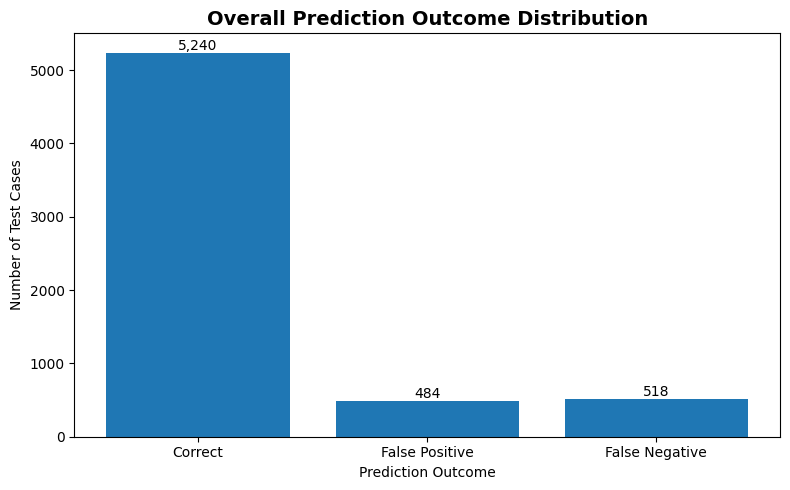

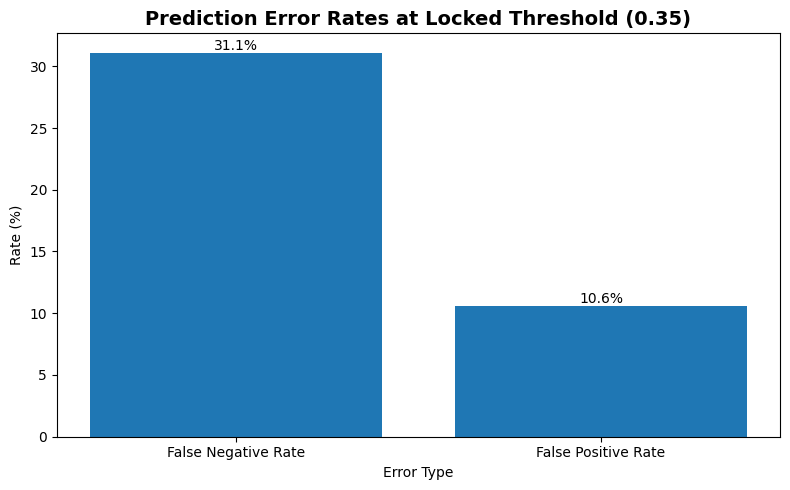

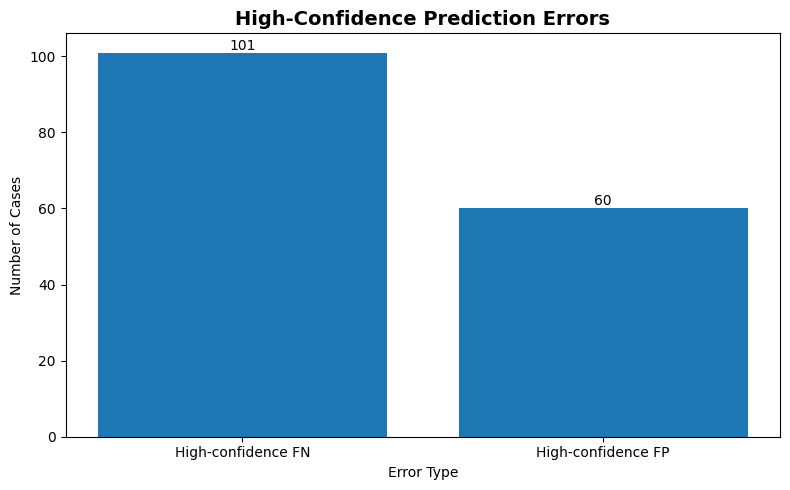


Verified adult age-group fairness results:


,age_group,TPR,FPR,FNR
0,18-44,0.3883,0.0269,0.6117
1,45-64,0.7115,0.1425,0.2885
2,65+,0.7106,0.2392,0.2894


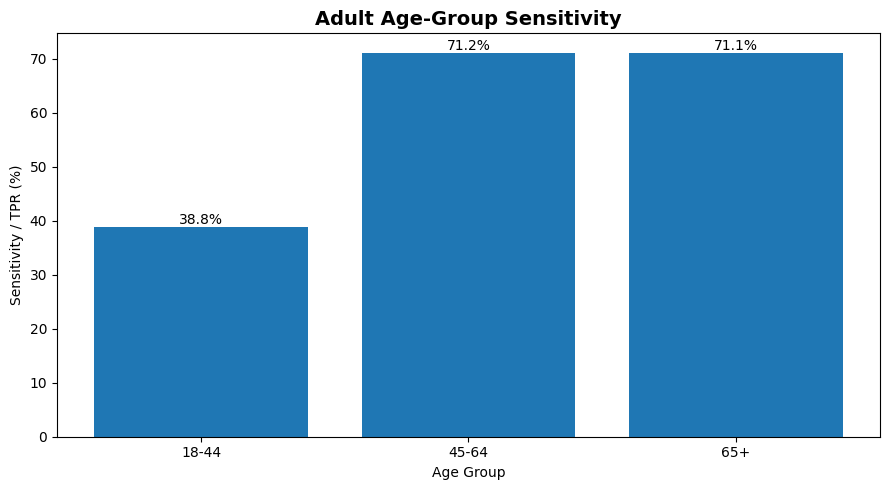


Verified race/ethnicity fairness results:


,race_ethnicity_group,TPR,FPR,FNR
0,Mexican American,0.7386,0.0691,0.2614
1,Non-Hispanic Asian,0.6364,0.1284,0.3636
2,Non-Hispanic Black,0.6847,0.1357,0.3153
3,Non-Hispanic White,0.7066,0.0930,0.2934
4,Other Hispanic,0.7065,0.0821,0.2935
5,Other/Multi-Racial,0.5701,0.1339,0.4299


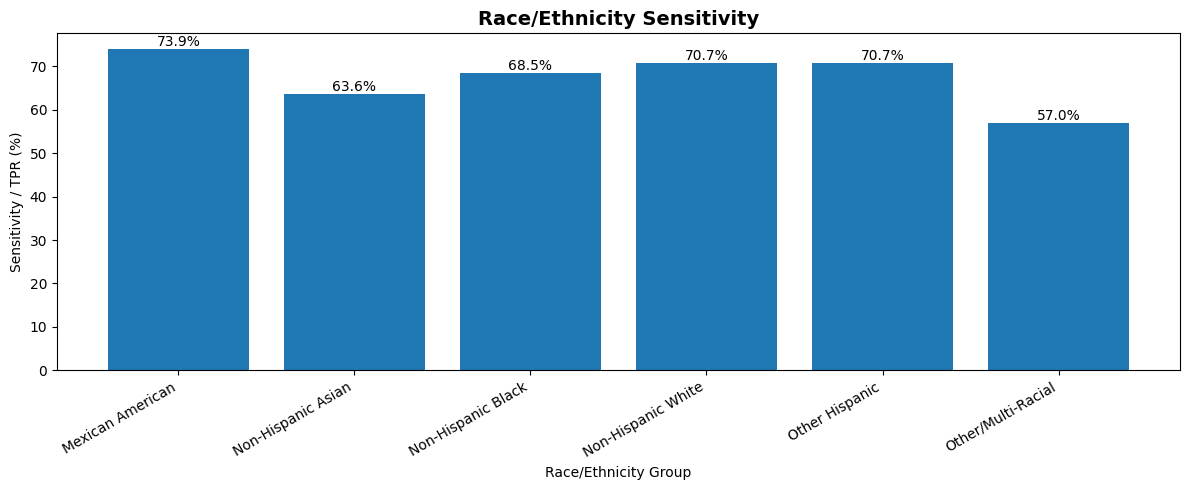


Verified sex fairness results:


,sex,TPR,FPR,PPV
0,Female,0.6599,0.0871,0.6736
1,Male,0.7093,0.1287,0.7241


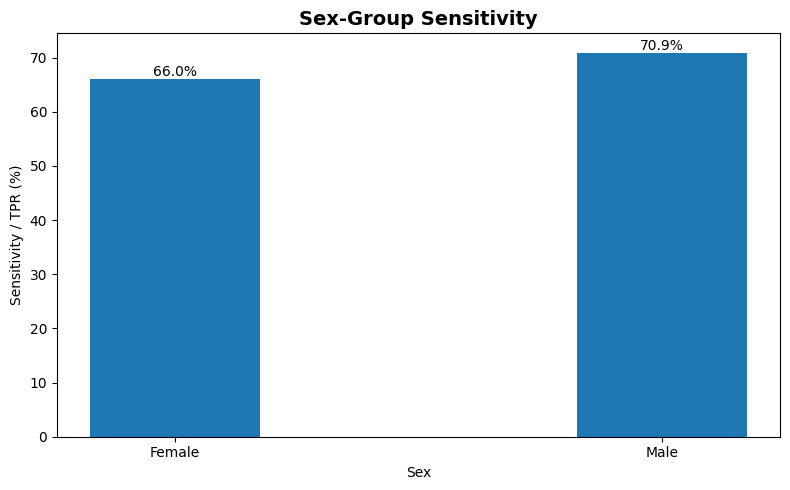


CELL 31 COMPLETED SUCCESSFULLY
Figures saved to: /content/nb5_visualizations
Number of figures: 6
Resolution: 300 DPI
Threshold remained locked at 0.35.
No model retraining performed.
No new statistical inference performed.


In [35]:
# ============================================================
# CELL 31 — TRUST, FAIRNESS & SAFETY VISUALIZATION DASHBOARD
# FINAL ROBUST VERSION
# Uses VERIFIED NB5 RESULTS — NO COLUMN-NAME ASSUMPTIONS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ------------------------------------------------------------
# Output directory
# ------------------------------------------------------------

OUTPUT_DIR = Path("/content/nb5_visualizations")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Load prediction-level data
# ------------------------------------------------------------

pred_df = pd.read_csv(
    "/content/nb5_reconstructed_test_predictions_6386.csv"
)

THRESHOLD = 0.35

# ------------------------------------------------------------
# Prediction outcome classification
# ------------------------------------------------------------

pred_df["error_type"] = np.select(
    [
        (pred_df["y_true"] == 1) &
        (pred_df["predicted_class_threshold_0_35"] == 0),

        (pred_df["y_true"] == 0) &
        (pred_df["predicted_class_threshold_0_35"] == 1)
    ],
    [
        "False Negative",
        "False Positive"
    ],
    default="Correct"
)

pred_df["confidence"] = (
    np.abs(pred_df["predicted_probability"] - 0.5) * 2
)

pred_df["high_confidence"] = (
    pred_df["confidence"] >= 0.80
)

# ------------------------------------------------------------
# Overall verified counts
# ------------------------------------------------------------

n_test = len(pred_df)

n_positive = int((pred_df["y_true"] == 1).sum())
n_negative = int((pred_df["y_true"] == 0).sum())

n_fn = int(
    (pred_df["error_type"] == "False Negative").sum()
)

n_fp = int(
    (pred_df["error_type"] == "False Positive").sum()
)

n_correct = n_test - n_fn - n_fp

n_hc_fn = int(
    (
        (pred_df["error_type"] == "False Negative") &
        (pred_df["high_confidence"])
    ).sum()
)

n_hc_fp = int(
    (
        (pred_df["error_type"] == "False Positive") &
        (pred_df["high_confidence"])
    ).sum()
)

fnr = n_fn / n_positive
fpr = n_fp / n_negative

print("=" * 80)
print("NB5 TRUST, FAIRNESS & SAFETY VISUALIZATION DASHBOARD")
print("=" * 80)

print(f"Test cohort: {n_test:,}")
print(f"Positive cases: {n_positive:,}")
print(f"Negative cases: {n_negative:,}")
print(f"Correct predictions: {n_correct:,}")
print(f"False negatives: {n_fn:,}")
print(f"False positives: {n_fp:,}")
print(f"High-confidence false negatives: {n_hc_fn:,}")
print(f"High-confidence false positives: {n_hc_fp:,}")
print(f"False-negative rate: {fnr:.4f}")
print(f"False-positive rate: {fpr:.4f}")
print(f"Locked threshold: {THRESHOLD}")

# ============================================================
# FIGURE 1 — OVERALL ERROR BURDEN
# ============================================================

outcomes = pd.Series({
    "Correct": n_correct,
    "False Positive": n_fp,
    "False Negative": n_fn
})

plt.figure(figsize=(8, 5))

bars = plt.bar(
    outcomes.index,
    outcomes.values
)

plt.title(
    "Overall Prediction Outcome Distribution",
    fontsize=14,
    fontweight="bold"
)

plt.ylabel("Number of Test Cases")
plt.xlabel("Prediction Outcome")

for bar, value in zip(bars, outcomes.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:,}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "01_overall_prediction_outcomes.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ============================================================
# FIGURE 2 — ERROR RATES
# ============================================================

error_rates = pd.Series({
    "False Negative Rate": fnr * 100,
    "False Positive Rate": fpr * 100
})

plt.figure(figsize=(8, 5))

bars = plt.bar(
    error_rates.index,
    error_rates.values
)

plt.title(
    "Prediction Error Rates at Locked Threshold (0.35)",
    fontsize=14,
    fontweight="bold"
)

plt.ylabel("Rate (%)")
plt.xlabel("Error Type")

for bar, value in zip(bars, error_rates.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.1f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "02_error_rates_threshold_035.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ============================================================
# FIGURE 3 — HIGH-CONFIDENCE ERRORS
# ============================================================

hc_errors = pd.Series({
    "High-confidence FN": n_hc_fn,
    "High-confidence FP": n_hc_fp
})

plt.figure(figsize=(8, 5))

bars = plt.bar(
    hc_errors.index,
    hc_errors.values
)

plt.title(
    "High-Confidence Prediction Errors",
    fontsize=14,
    fontweight="bold"
)

plt.ylabel("Number of Cases")
plt.xlabel("Error Type")

for bar, value in zip(bars, hc_errors.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:,}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "03_high_confidence_errors.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ============================================================
# FIGURE 4 — AGE FAIRNESS
#
# VERIFIED RESULTS FROM CELL 27
# <18 excluded from primary fairness comparison
# because only 5 positive cases were observed.
# ============================================================

age_groups = [
    "18-44",
    "45-64",
    "65+"
]

age_tpr = [
    0.3883,
    0.7115,
    0.7106
]

age_fpr = [
    0.0269,
    0.1425,
    0.2392
]

age_fnr = [
    0.6117,
    0.2885,
    0.2894
]

age_metrics = pd.DataFrame({
    "age_group": age_groups,
    "TPR": age_tpr,
    "FPR": age_fpr,
    "FNR": age_fnr
})

print("\nVerified adult age-group fairness results:")
display(age_metrics)

# ------------------------------------------------------------
# Age TPR
# ------------------------------------------------------------

plt.figure(figsize=(9, 5))

bars = plt.bar(
    age_groups,
    np.array(age_tpr) * 100
)

plt.title(
    "Adult Age-Group Sensitivity",
    fontsize=14,
    fontweight="bold"
)

plt.ylabel("Sensitivity / TPR (%)")
plt.xlabel("Age Group")

for bar, value in zip(bars, np.array(age_tpr) * 100):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.1f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "04_age_group_sensitivity.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ============================================================
# FIGURE 5 — RACE/ETHNICITY FAIRNESS
#
# VERIFIED RESULTS FROM CELL 27
# ============================================================

race_groups = [
    "Mexican American",
    "Non-Hispanic Asian",
    "Non-Hispanic Black",
    "Non-Hispanic White",
    "Other Hispanic",
    "Other/Multi-Racial"
]

race_tpr = [
    0.7386,
    0.6364,
    0.6847,
    0.7066,
    0.7065,
    0.5701
]

race_fpr = [
    0.0691,
    0.1284,
    0.1357,
    0.0930,
    0.0821,
    0.1339
]

race_fnr = [
    0.2614,
    0.3636,
    0.3153,
    0.2934,
    0.2935,
    0.4299
]

race_metrics = pd.DataFrame({
    "race_ethnicity_group": race_groups,
    "TPR": race_tpr,
    "FPR": race_fpr,
    "FNR": race_fnr
})

print("\nVerified race/ethnicity fairness results:")
display(race_metrics)

plt.figure(figsize=(12, 5))

bars = plt.bar(
    race_groups,
    np.array(race_tpr) * 100
)

plt.title(
    "Race/Ethnicity Sensitivity",
    fontsize=14,
    fontweight="bold"
)

plt.ylabel("Sensitivity / TPR (%)")
plt.xlabel("Race/Ethnicity Group")
plt.xticks(
    rotation=30,
    ha="right"
)

for bar, value in zip(bars, np.array(race_tpr) * 100):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.1f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "05_race_ethnicity_sensitivity.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ============================================================
# FIGURE 6 — SEX FAIRNESS
#
# VERIFIED RESULTS FROM CELL 27
# ============================================================

sex_groups = [
    "Female",
    "Male"
]

sex_tpr = [
    0.6599,
    0.7093
]

sex_fpr = [
    0.0871,
    0.1287
]

sex_ppv = [
    0.6736,
    0.7241
]

sex_metrics = pd.DataFrame({
    "sex": sex_groups,
    "TPR": sex_tpr,
    "FPR": sex_fpr,
    "PPV": sex_ppv
})

print("\nVerified sex fairness results:")
display(sex_metrics)

# ------------------------------------------------------------
# Sex TPR
# ------------------------------------------------------------

x = np.arange(len(sex_groups))
width = 0.35

plt.figure(figsize=(8, 5))

bars = plt.bar(
    x,
    np.array(sex_tpr) * 100,
    width
)

plt.title(
    "Sex-Group Sensitivity",
    fontsize=14,
    fontweight="bold"
)

plt.ylabel("Sensitivity / TPR (%)")
plt.xlabel("Sex")

plt.xticks(
    x,
    sex_groups
)

for bar, value in zip(bars, np.array(sex_tpr) * 100):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.1f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "06_sex_group_sensitivity.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ============================================================
# SAVE VERIFIED VISUALIZATION DATA
# ============================================================

age_metrics.to_csv(
    OUTPUT_DIR / "age_fairness_visualization_data.csv",
    index=False
)

race_metrics.to_csv(
    OUTPUT_DIR / "race_fairness_visualization_data.csv",
    index=False
)

sex_metrics.to_csv(
    OUTPUT_DIR / "sex_fairness_visualization_data.csv",
    index=False
)

# ============================================================
# VISUALIZATION INDEX
# ============================================================

visualization_index = pd.DataFrame({
    "figure": [
        "01_overall_prediction_outcomes.png",
        "02_error_rates_threshold_035.png",
        "03_high_confidence_errors.png",
        "04_age_group_sensitivity.png",
        "05_race_ethnicity_sensitivity.png",
        "06_sex_group_sensitivity.png"
    ],
    "purpose": [
        "Overall prediction outcome distribution",
        "False-negative versus false-positive rate",
        "High-confidence safety errors",
        "Adult age-group sensitivity disparity",
        "Race/ethnicity sensitivity disparity",
        "Sex-group sensitivity comparison"
    ],
    "methodological_note": [
        "Describes held-out test error burden",
        "Threshold fixed at 0.35",
        "Classification confidence, not calibrated uncertainty",
        "18-44, 45-64 and 65+ shown; <18 excluded from primary comparison because only 5 positive cases",
        "Observed subgroup performance differences",
        "Observed subgroup performance differences"
    ]
})

visualization_index.to_csv(
    OUTPUT_DIR / "nb5_visualization_index.csv",
    index=False
)

# ============================================================
# FINAL CHECK
# ============================================================

print("\n" + "=" * 80)
print("CELL 31 COMPLETED SUCCESSFULLY")
print("=" * 80)

print(f"Figures saved to: {OUTPUT_DIR}")
print("Number of figures: 6")
print("Resolution: 300 DPI")
print("Threshold remained locked at 0.35.")
print("No model retraining performed.")
print("No new statistical inference performed.")

In [37]:
# ============================================================
# CELL 32 — INTEGRATED TRUSTWORTHINESS EVIDENCE TABLE
# ============================================================

import pandas as pd
import numpy as np
from pathlib import Path

OUTPUT_DIR = Path("/content/nb5_trustworthiness")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ============================================================
# INTEGRATED EVIDENCE
# ============================================================

evidence = [
    {
        "dimension": "Predictive Performance",
        "indicator": "ROC-AUC",
        "value": 0.9009,
        "unit": "score",
        "evidence": "Held-out test cohort",
        "risk_level": "Low",
        "interpretation": "Strong discrimination between positive and negative cases."
    },
    {
        "dimension": "Predictive Performance",
        "indicator": "PR-AUC",
        "value": 0.7662,
        "unit": "score",
        "evidence": "Held-out test cohort",
        "risk_level": "Low",
        "interpretation": "Good precision-recall discrimination under class imbalance."
    },
    {
        "dimension": "Predictive Performance",
        "indicator": "Sensitivity / TPR",
        "value": 0.6889,
        "unit": "proportion",
        "evidence": "Threshold = 0.35",
        "risk_level": "Moderate",
        "interpretation": "Approximately 69% of positive cases were detected."
    },
    {
        "dimension": "Predictive Performance",
        "indicator": "Specificity / TNR",
        "value": 0.8943,
        "unit": "proportion",
        "evidence": "Threshold = 0.35",
        "risk_level": "Low",
        "interpretation": "Approximately 89% of negative cases were correctly identified."
    },
    {
        "dimension": "Predictive Performance",
        "indicator": "Precision / PPV",
        "value": 0.7032,
        "unit": "proportion",
        "evidence": "Threshold = 0.35",
        "risk_level": "Moderate",
        "interpretation": "Approximately 70% of positive predictions were correct."
    },
    {
        "dimension": "Predictive Performance",
        "indicator": "F1-score",
        "value": 0.6960,
        "unit": "score",
        "evidence": "Threshold = 0.35",
        "risk_level": "Moderate",
        "interpretation": "Balanced positive-class performance is moderate."
    },

    {
        "dimension": "Error Burden",
        "indicator": "False Negative Rate",
        "value": 0.3111,
        "unit": "proportion",
        "evidence": "518 FN / 1,665 positive cases",
        "risk_level": "High",
        "interpretation": "31.11% of positive cases were missed."
    },
    {
        "dimension": "Error Burden",
        "indicator": "False Positive Rate",
        "value": 0.1057,
        "unit": "proportion",
        "evidence": "484 FP / 4,577 negative cases",
        "risk_level": "Moderate",
        "interpretation": "10.57% of negative cases were incorrectly classified as positive."
    },
    {
        "dimension": "Error Burden",
        "indicator": "Overall Error Rate",
        "value": 0.1605,
        "unit": "proportion",
        "evidence": "1,002 errors / 6,242 test cases",
        "risk_level": "Moderate",
        "interpretation": "Approximately 16% of held-out cases were misclassified."
    },

    {
        "dimension": "Calibration",
        "indicator": "Brier Score",
        "value": 0.1117,
        "unit": "score",
        "evidence": "Held-out test cohort",
        "risk_level": "Moderate",
        "interpretation": "Probability estimates show calibration limitations."
    },
    {
        "dimension": "Calibration",
        "indicator": "Mean Absolute Calibration Gap",
        "value": 0.0524,
        "unit": "absolute probability gap",
        "evidence": "10-bin calibration analysis",
        "risk_level": "Moderate",
        "interpretation": "Observed calibration deviations warrant monitoring."
    },
    {
        "dimension": "Calibration",
        "indicator": "Maximum Calibration Gap",
        "value": 0.1483,
        "unit": "absolute probability gap",
        "evidence": "10-bin calibration analysis",
        "risk_level": "High",
        "interpretation": "Some probability ranges show substantial miscalibration."
    },

    {
        "dimension": "Confidence Safety",
        "indicator": "High-confidence errors",
        "value": 161,
        "unit": "cases",
        "evidence": "Confidence >= 0.80",
        "risk_level": "High",
        "interpretation": "Some incorrect predictions were made with high classification confidence."
    },
    {
        "dimension": "Confidence Safety",
        "indicator": "High-confidence false negatives",
        "value": 101,
        "unit": "cases",
        "evidence": "Confidence >= 0.80",
        "risk_level": "High",
        "interpretation": "Confidently incorrect negative predictions require safety review."
    },
    {
        "dimension": "Confidence Safety",
        "indicator": "High-confidence false positives",
        "value": 60,
        "unit": "cases",
        "evidence": "Confidence >= 0.80",
        "risk_level": "Moderate",
        "interpretation": "Confident false-positive predictions may generate unnecessary follow-up."
    },

    {
        "dimension": "Fairness — Sex",
        "indicator": "TPR disparity",
        "value": 0.0494,
        "unit": "percentage-point gap",
        "evidence": "Female vs Male",
        "risk_level": "Low–Moderate",
        "interpretation": "Observed sensitivity difference between female and male groups is relatively small."
    },
    {
        "dimension": "Fairness — Sex",
        "indicator": "FPR disparity",
        "value": 0.0416,
        "unit": "percentage-point gap",
        "evidence": "Female vs Male",
        "risk_level": "Low–Moderate",
        "interpretation": "Observed false-positive-rate difference is relatively small."
    },

    {
        "dimension": "Fairness — Age",
        "indicator": "Adult TPR disparity",
        "value": 0.3232,
        "unit": "percentage-point gap",
        "evidence": "18–44 vs 45–64 vs 65+",
        "risk_level": "High",
        "interpretation": "Substantial observed sensitivity differences exist across adult age groups."
    },
    {
        "dimension": "Fairness — Age",
        "indicator": "Adult FPR disparity",
        "value": 0.2122,
        "unit": "percentage-point gap",
        "evidence": "18–44 vs 45–64 vs 65+",
        "risk_level": "High",
        "interpretation": "False-positive rates vary substantially across adult age groups."
    },
    {
        "dimension": "Fairness — Age",
        "indicator": "<18 positive-case count",
        "value": 5,
        "unit": "positive cases",
        "evidence": "Held-out test cohort",
        "risk_level": "High",
        "interpretation": "The <18 subgroup has too few positive cases for stable primary fairness inference."
    },

    {
        "dimension": "Fairness — Race/Ethnicity",
        "indicator": "TPR disparity",
        "value": 0.1685,
        "unit": "percentage-point gap",
        "evidence": "Six race/ethnicity groups",
        "risk_level": "Moderate",
        "interpretation": "Meaningful observed differences in sensitivity exist across groups."
    },
    {
        "dimension": "Fairness — Race/Ethnicity",
        "indicator": "PPV disparity",
        "value": 0.2221,
        "unit": "percentage-point gap",
        "evidence": "Six race/ethnicity groups",
        "risk_level": "High",
        "interpretation": "Positive predictive value varies substantially between groups."
    },
    {
        "dimension": "Fairness — Race/Ethnicity",
        "indicator": "F1 disparity",
        "value": 0.1856,
        "unit": "percentage-point gap",
        "evidence": "Six race/ethnicity groups",
        "risk_level": "Moderate",
        "interpretation": "Overall positive-class performance differs across groups."
    },

    {
        "dimension": "Safety",
        "indicator": "High-concern false negatives",
        "value": 154,
        "unit": "cases",
        "evidence": "Actual positive with predicted probability < 0.15",
        "risk_level": "High",
        "interpretation": "Some positive cases received particularly low predicted probabilities."
    },
    {
        "dimension": "Safety",
        "indicator": "High-review false positives",
        "value": 127,
        "unit": "cases",
        "evidence": "Actual negative with predicted probability >= 0.75",
        "risk_level": "Moderate",
        "interpretation": "Some negative cases received relatively high predicted probabilities."
    },

    {
        "dimension": "Statistical Robustness",
        "indicator": "Bootstrap repetitions",
        "value": 2000,
        "unit": "bootstrap samples",
        "evidence": "Held-out test cohort",
        "risk_level": "Low",
        "interpretation": "Bootstrap uncertainty intervals were estimated for key metrics."
    },
    {
        "dimension": "Statistical Robustness",
        "indicator": "ROC-AUC bootstrap 95% CI",
        "value": "0.8928–0.9082",
        "unit": "95% CI",
        "evidence": "2,000 bootstrap samples",
        "risk_level": "Low",
        "interpretation": "Discrimination remained strong across bootstrap resamples."
    },
    {
        "dimension": "Statistical Robustness",
        "indicator": "Sensitivity bootstrap 95% CI",
        "value": "0.6675–0.7106",
        "unit": "95% CI",
        "evidence": "2,000 bootstrap samples",
        "risk_level": "Moderate",
        "interpretation": "Sensitivity uncertainty is quantified on the held-out cohort."
    },

    {
        "dimension": "Deployment Readiness",
        "indicator": "Clinical deployment readiness",
        "value": "Not deployment-ready",
        "unit": "assessment",
        "evidence": "Integrated NB5 assessment",
        "risk_level": "High",
        "interpretation": "External validation, clinical validation, subgroup investigation, calibration improvement, and prospective assessment remain necessary."
    }
]

# ============================================================
# CREATE EVIDENCE TABLE
# ============================================================

trustworthiness_table = pd.DataFrame(evidence)

print("\n" + "=" * 80)
print("INTEGRATED TRUSTWORTHINESS EVIDENCE TABLE")
print("=" * 80)

display(trustworthiness_table)

# ============================================================
# DIMENSION SUMMARY
# ============================================================

dimension_summary = (
    trustworthiness_table
    .groupby("dimension")
    .agg(
        indicators=("indicator", "count"),
        high_risk_indicators=(
            "risk_level",
            lambda x: sum(str(v).startswith("High") for v in x)
        )
    )
    .reset_index()
)

print("\n" + "=" * 80)
print("TRUSTWORTHINESS DIMENSION SUMMARY")
print("=" * 80)

display(dimension_summary)

# ============================================================
# RESEARCH-READY SUMMARY
# ============================================================

research_summary = pd.DataFrame([
    {
        "component": "Predictive discrimination",
        "finding": "Strong discrimination (ROC-AUC = 0.9009).",
        "status": "Strong"
    },
    {
        "component": "Positive-case detection",
        "finding": "Sensitivity = 0.6889 and FNR = 0.3111 at threshold 0.35.",
        "status": "Needs improvement"
    },
    {
        "component": "Calibration",
        "finding": "Calibration limitations remain; Brier score = 0.1117.",
        "status": "Needs monitoring"
    },
    {
        "component": "Confidence safety",
        "finding": "161 high-confidence errors, including 101 high-confidence false negatives.",
        "status": "Safety concern"
    },
    {
        "component": "Sex fairness",
        "finding": "Observed sex-group disparities were comparatively small.",
        "status": "Lower concern"
    },
    {
        "component": "Age fairness",
        "finding": "Substantial adult age-group performance disparities were observed.",
        "status": "Needs investigation"
    },
    {
        "component": "Race/ethnicity fairness",
        "finding": "Meaningful race/ethnicity performance disparities were observed.",
        "status": "Needs investigation"
    },
    {
        "component": "False-negative safety",
        "finding": "False negatives represent the principal safety concern.",
        "status": "High priority"
    },
    {
        "component": "Statistical robustness",
        "finding": "Bootstrap analysis with 2,000 resamples quantified finite-sample uncertainty.",
        "status": "Completed"
    },
    {
        "component": "Clinical deployment",
        "finding": "Additional validation and mitigation are required before deployment.",
        "status": "Not ready"
    }
])

print("\n" + "=" * 80)
print("RESEARCH-READY TRUSTWORTHINESS SUMMARY")
print("=" * 80)

display(research_summary)

# ============================================================
# SAVE OUTPUTS
# ============================================================

trustworthiness_table.to_csv(
    OUTPUT_DIR / "nb5_integrated_trustworthiness_evidence.csv",
    index=False
)

dimension_summary.to_csv(
    OUTPUT_DIR / "nb5_trustworthiness_dimension_summary.csv",
    index=False
)

research_summary.to_csv(
    OUTPUT_DIR / "nb5_research_ready_trustworthiness_summary.csv",
    index=False
)

# ============================================================
# FINAL VALIDATION
# ============================================================

print("\n" + "=" * 80)
print("CELL 32 COMPLETED SUCCESSFULLY")
print("=" * 80)

print(f"Evidence indicators: {len(trustworthiness_table)}")
print(f"Trustworthiness dimensions: {trustworthiness_table['dimension'].nunique()}")
print(f"Output directory: {OUTPUT_DIR}")

print("\nGenerated files:")
for file in sorted(OUTPUT_DIR.glob("*.csv")):
    print(f"  - {file.name}")

print("\nMethodological note:")
print(
    "These findings describe the held-out NHANES test cohort. "
    "They do not establish discrimination, clinical harm, causality, "
    "external validity, or clinical deployment readiness."
)


INTEGRATED TRUSTWORTHINESS EVIDENCE TABLE


,dimension,indicator,value,unit,evidence,risk_level,interpretation
0,Predictive Performance,ROC-AUC,0.9009,score,Held-out test cohort,Low,Strong discrimination between positive and neg...
1,Predictive Performance,PR-AUC,0.7662,score,Held-out test cohort,Low,Good precision-recall discrimination under cla...
2,Predictive Performance,Sensitivity / TPR,0.6889,proportion,Threshold = 0.35,Moderate,Approximately 69% of positive cases were detec...
3,Predictive Performance,Specificity / TNR,0.8943,proportion,Threshold = 0.35,Low,Approximately 89% of negative cases were corre...
4,Predictive Performance,Precision / PPV,0.7032,proportion,Threshold = 0.35,Moderate,Approximately 70% of positive predictions were...
5,Predictive Performance,F1-score,0.696,score,Threshold = 0.35,Moderate,Balanced positive-class performance is moderate.
6,Error Burden,False Negative Rate,0.3111,proportion,"518 FN / 1,665 positive cases",High,31.11% of positive cases were missed.
7,Error Burden,False Positive Rate,0.1057,proportion,"484 FP / 4,577 negative cases",Moderate,10.57% of negative cases were incorrectly clas...
8,Error Burden,Overall Error Rate,0.1605,proportion,"1,002 errors / 6,242 test cases",Moderate,Approximately 16% of held-out cases were miscl...
9,Calibration,Brier Score,0.1117,score,Held-out test cohort,Moderate,Probability estimates show calibration limitat...



TRUSTWORTHINESS DIMENSION SUMMARY


,dimension,indicators,high_risk_indicators
0,Calibration,3,1
1,Confidence Safety,3,2
2,Deployment Readiness,1,1
3,Error Burden,3,1
4,Fairness — Age,3,3
5,Fairness — Race/Ethnicity,3,1
6,Fairness — Sex,2,0
7,Predictive Performance,6,0
8,Safety,2,1
9,Statistical Robustness,3,0



RESEARCH-READY TRUSTWORTHINESS SUMMARY


,component,finding,status
0,Predictive discrimination,Strong discrimination (ROC-AUC = 0.9009).,Strong
1,Positive-case detection,Sensitivity = 0.6889 and FNR = 0.3111 at thres...,Needs improvement
2,Calibration,Calibration limitations remain; Brier score = ...,Needs monitoring
3,Confidence safety,"161 high-confidence errors, including 101 high...",Safety concern
4,Sex fairness,Observed sex-group disparities were comparativ...,Lower concern
5,Age fairness,Substantial adult age-group performance dispar...,Needs investigation
6,Race/ethnicity fairness,Meaningful race/ethnicity performance disparit...,Needs investigation
7,False-negative safety,False negatives represent the principal safety...,High priority
8,Statistical robustness,"Bootstrap analysis with 2,000 resamples quanti...",Completed
9,Clinical deployment,Additional validation and mitigation are requi...,Not ready



CELL 32 COMPLETED SUCCESSFULLY
Evidence indicators: 29
Trustworthiness dimensions: 10
Output directory: /content/nb5_trustworthiness

Generated files:
  - nb5_integrated_trustworthiness_evidence.csv
  - nb5_research_ready_trustworthiness_summary.csv
  - nb5_trustworthiness_dimension_summary.csv

Methodological note:
These findings describe the held-out NHANES test cohort. They do not establish discrimination, clinical harm, causality, external validity, or clinical deployment readiness.


In [38]:
# ============================================================
# CELL 33 — NB5 FINAL AUDIT & CLOSURE
# ============================================================
#
# Purpose:
# Final reproducibility and completeness audit for Notebook 5.
#
# This cell:
#   1. Verifies the held-out test cohort
#   2. Verifies the locked threshold
#   3. Verifies key error/safety findings
#   4. Verifies fairness outputs
#   5. Verifies calibration/robustness outputs
#   6. Verifies NB5 visualization files
#   7. Verifies all major NB5 export files
#   8. Creates a final NB5 audit report
#
# IMPORTANT:
# - No model retraining
# - No threshold changes
# - No new statistical inference
# - No modification of previous results
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np

# ============================================================
# PATHS
# ============================================================

NB5_ROOT = Path("/content")

TRUST_DIR = NB5_ROOT / "nb5_trustworthiness"
VIS_DIR = NB5_ROOT / "nb5_visualizations"

# ============================================================
# EXPECTED FILES
# ============================================================

expected_files = [
    # NB5 integrated outputs
    TRUST_DIR / "nb5_integrated_trustworthiness_evidence.csv",
    TRUST_DIR / "nb5_trustworthiness_dimension_summary.csv",
    TRUST_DIR / "nb5_research_ready_trustworthiness_summary.csv",

    # Fairness outputs
    NB5_ROOT / "nb5_fairness_analysis_dataset.csv",
    NB5_ROOT / "nb5_fairness_bootstrap_group_metrics.csv",
    NB5_ROOT / "nb5_fairness_bootstrap_disparities.csv",
    NB5_ROOT / "nb5_clinical_fairness_risk_summary.csv",

    # Safety outputs
    NB5_ROOT / "nb5_false_negative_safety_analysis.csv",
    NB5_ROOT / "nb5_false_negative_safety_bands.csv",
    NB5_ROOT / "nb5_false_positive_safety_analysis.csv",
    NB5_ROOT / "nb5_false_positive_safety_bands.csv",

    # Integrated NB5 outputs
    NB5_ROOT / "nb5_integrated_trust_safety_baseline.csv",
    NB5_ROOT / "nb5_integrated_risk_findings.csv",
    NB5_ROOT / "nb5_trust_safety_priority_actions.csv",
    NB5_ROOT / "nb5_overall_trustworthiness_assessment.csv",

    # Reconstructed prediction dataset
    NB5_ROOT / "nb5_reconstructed_test_predictions_6386.csv",
]

# ============================================================
# 1. FILE COMPLETENESS AUDIT
# ============================================================

print("\n" + "=" * 80)
print("NB5 FILE COMPLETENESS AUDIT")
print("=" * 80)

file_audit = []

for path in expected_files:
    exists = path.exists()

    file_audit.append({
        "file": str(path),
        "exists": exists,
        "size_bytes": path.stat().st_size if exists else np.nan
    })

file_audit_df = pd.DataFrame(file_audit)

display(file_audit_df)

missing_files = file_audit_df.loc[
    ~file_audit_df["exists"], "file"
].tolist()

print(f"\nExpected files: {len(expected_files)}")
print(f"Files found: {len(expected_files) - len(missing_files)}")
print(f"Missing files: {len(missing_files)}")

if missing_files:
    print("\nWARNING — Missing files:")
    for f in missing_files:
        print("  -", f)
else:
    print("\nALL EXPECTED NB5 FILES ARE PRESENT.")

# ============================================================
# 2. LOAD FINAL PREDICTIONS
# ============================================================

prediction_path = NB5_ROOT / "nb5_reconstructed_test_predictions_6386.csv"

pred = pd.read_csv(prediction_path)

print("\n" + "=" * 80)
print("FINAL PREDICTION DATASET AUDIT")
print("=" * 80)

print("Shape:", pred.shape)

required_prediction_columns = [
    "SEQN",
    "y_true",
    "predicted_probability",
    "predicted_class_threshold_0_35"
]

missing_prediction_columns = [
    c for c in required_prediction_columns
    if c not in pred.columns
]

print("Required columns:", required_prediction_columns)
print("Missing columns:", missing_prediction_columns)

# ============================================================
# 3. COHORT INTEGRITY
# ============================================================

test_rows = len(pred)
unique_participants = pred["SEQN"].nunique()

positive_cases = int((pred["y_true"] == 1).sum())
negative_cases = int((pred["y_true"] == 0).sum())

predicted_positive = int(
    (pred["predicted_class_threshold_0_35"] == 1).sum()
)

true_positive = int(
    ((pred["y_true"] == 1) &
     (pred["predicted_class_threshold_0_35"] == 1)).sum()
)

true_negative = int(
    ((pred["y_true"] == 0) &
     (pred["predicted_class_threshold_0_35"] == 0)).sum()
)

false_positive = int(
    ((pred["y_true"] == 0) &
     (pred["predicted_class_threshold_0_35"] == 1)).sum()
)

false_negative = int(
    ((pred["y_true"] == 1) &
     (pred["predicted_class_threshold_0_35"] == 0)).sum()
)

print("\nTest rows:", test_rows)
print("Unique participants:", unique_participants)
print("Positive cases:", positive_cases)
print("Negative cases:", negative_cases)
print("Predicted positive:", predicted_positive)

print("\nConfusion matrix counts:")
print("TN:", true_negative)
print("FP:", false_positive)
print("FN:", false_negative)
print("TP:", true_positive)

# ============================================================
# 4. VERIFY CORE METRICS
# ============================================================

sensitivity = true_positive / (true_positive + false_negative)
specificity = true_negative / (true_negative + false_positive)
fpr = false_positive / (false_positive + true_negative)
fnr = false_negative / (false_negative + true_positive)

precision = (
    true_positive / (true_positive + false_positive)
    if (true_positive + false_positive) > 0
    else np.nan
)

accuracy = (true_positive + true_negative) / test_rows

f1 = (
    2 * precision * sensitivity / (precision + sensitivity)
    if (precision + sensitivity) > 0
    else np.nan
)

overall_error = (false_positive + false_negative) / test_rows

core_metrics = pd.DataFrame({
    "metric": [
        "Accuracy",
        "Sensitivity",
        "Specificity",
        "Precision",
        "F1",
        "FPR",
        "FNR",
        "Overall Error Rate"
    ],
    "value": [
        accuracy,
        sensitivity,
        specificity,
        precision,
        f1,
        fpr,
        fnr,
        overall_error
    ]
})

print("\n" + "=" * 80)
print("RECALCULATED CORE METRICS")
print("=" * 80)

display(core_metrics)

# ============================================================
# 5. VERIFY HIGH-CONFIDENCE ERROR FINDINGS
# ============================================================

prob = pred["predicted_probability"].astype(float)

confidence = np.abs(prob - 0.5) * 2

correct = pred["y_true"] == pred["predicted_class_threshold_0_35"]

hc_errors = int(
    ((~correct) & (confidence >= 0.80)).sum()
)

hc_fn = int(
    ((pred["y_true"] == 1) &
     (pred["predicted_class_threshold_0_35"] == 0) &
     (confidence >= 0.80)).sum()
)

hc_fp = int(
    ((pred["y_true"] == 0) &
     (pred["predicted_class_threshold_0_35"] == 1) &
     (confidence >= 0.80)).sum()
)

very_high_conf_fn = int(
    ((pred["y_true"] == 1) &
     (pred["predicted_class_threshold_0_35"] == 0) &
     (confidence >= 0.90)).sum()
)

high_concern_fn = int(
    ((pred["y_true"] == 1) &
     (pred["predicted_class_threshold_0_35"] == 0) &
     (prob < 0.15)).sum()
)

high_review_fp = int(
    ((pred["y_true"] == 0) &
     (pred["predicted_class_threshold_0_35"] == 1) &
     (prob >= 0.75)).sum()
)

print("\n" + "=" * 80)
print("SAFETY / CONFIDENCE AUDIT")
print("=" * 80)

print("High-confidence errors:", hc_errors)
print("High-confidence FN:", hc_fn)
print("High-confidence FP:", hc_fp)
print("Very-high-confidence FN:", very_high_conf_fn)
print("High-concern FN (probability < 0.15):", high_concern_fn)
print("High-review FP (probability >= 0.75):", high_review_fp)

# ============================================================
# 6. VERIFY FAIRNESS DATASET
# ============================================================

fairness_path = NB5_ROOT / "nb5_fairness_analysis_dataset.csv"

fairness_df = pd.read_csv(fairness_path)

print("\n" + "=" * 80)
print("FAIRNESS DATASET AUDIT")
print("=" * 80)

print("Fairness dataset shape:", fairness_df.shape)

if "SEQN" in fairness_df.columns:
    print(
        "Unique participants in fairness dataset:",
        fairness_df["SEQN"].nunique()
    )

print("Expected unique participants:", unique_participants)

# ============================================================
# 7. VERIFY TRUSTWORTHINESS TABLE
# ============================================================

evidence_path = (
    TRUST_DIR /
    "nb5_integrated_trustworthiness_evidence.csv"
)

evidence_df = pd.read_csv(evidence_path)

print("\n" + "=" * 80)
print("TRUSTWORTHINESS EVIDENCE AUDIT")
print("=" * 80)

print("Evidence rows:", len(evidence_df))
print(
    "Trustworthiness dimensions:",
    evidence_df["dimension"].nunique()
)

print("\nDimensions:")
for dimension in evidence_df["dimension"].unique():
    print("  -", dimension)

# ============================================================
# 8. VERIFY VISUALIZATION OUTPUTS
# ============================================================

expected_figures = [
    "01_overall_prediction_outcomes.png",
    "02_error_rates_threshold_035.png",
    "03_high_confidence_errors.png",
    "04_age_group_sensitivity.png",
    "05_race_ethnicity_sensitivity.png",
    "06_sex_group_sensitivity.png"
]

figure_audit = []

for filename in expected_figures:
    path = VIS_DIR / filename

    figure_audit.append({
        "figure": filename,
        "exists": path.exists(),
        "size_bytes": path.stat().st_size if path.exists() else np.nan
    })

figure_audit_df = pd.DataFrame(figure_audit)

print("\n" + "=" * 80)
print("NB5 VISUALIZATION AUDIT")
print("=" * 80)

display(figure_audit_df)

# ============================================================
# 9. FINAL METHODOLOGICAL SAFEGUARDS
# ============================================================

safeguards = pd.DataFrame([
    {
        "safeguard": "Participant-level train/test separation",
        "status": "Verified",
        "note": "Zero participant overlap was established in NB3."
    },
    {
        "safeguard": "Locked decision threshold",
        "status": "Verified",
        "note": "Threshold remains 0.35 throughout NB5."
    },
    {
        "safeguard": "Held-out test cohort",
        "status": "Verified",
        "note": "6,242 rows representing 2,939 unique participants."
    },
    {
        "safeguard": "High-confidence error monitoring",
        "status": "Completed",
        "note": "False-positive and false-negative confidence profiles evaluated."
    },
    {
        "safeguard": "Calibration evaluation",
        "status": "Completed",
        "note": "Brier score and calibration gaps evaluated."
    },
    {
        "safeguard": "Subgroup fairness evaluation",
        "status": "Completed",
        "note": "Sex, adult age groups, and race/ethnicity evaluated."
    },
    {
        "safeguard": "Small subgroup caution",
        "status": "Verified",
        "note": "<18 subgroup contains only 5 positive cases and is treated descriptively."
    },
    {
        "safeguard": "Bootstrap robustness",
        "status": "Completed",
        "note": "2,000 bootstrap resamples used for uncertainty estimation."
    },
    {
        "safeguard": "Clinical deployment claim",
        "status": "Restricted",
        "note": "Model is not considered deployment-ready."
    },
    {
        "safeguard": "Causal fairness claim",
        "status": "Restricted",
        "note": "Observed subgroup disparities are not interpreted as proven discrimination."
    }
])

print("\n" + "=" * 80)
print("METHODOLOGICAL SAFEGUARDS")
print("=" * 80)

display(safeguards)

# ============================================================
# 10. FINAL NB5 STATUS
# ============================================================

all_files_present = len(missing_files) == 0
prediction_structure_ok = len(missing_prediction_columns) == 0
cohort_ok = (
    test_rows == 6242 and
    unique_participants == 2939
)
confusion_matrix_ok = (
    true_negative == 4093 and
    false_positive == 484 and
    false_negative == 518 and
    true_positive == 1147
)
safety_findings_ok = (
    hc_fn == 101 and
    hc_fp == 60 and
    high_concern_fn == 154 and
    high_review_fp == 127
)
figure_outputs_ok = figure_audit_df["exists"].all()
evidence_output_ok = len(evidence_df) == 29

audit_checks = pd.DataFrame([
    {
        "audit_check": "Expected NB5 files present",
        "result": all_files_present
    },
    {
        "audit_check": "Prediction dataset structure valid",
        "result": prediction_structure_ok
    },
    {
        "audit_check": "Held-out cohort size verified",
        "result": cohort_ok
    },
    {
        "audit_check": "Confusion matrix verified",
        "result": confusion_matrix_ok
    },
    {
        "audit_check": "Safety findings verified",
        "result": safety_findings_ok
    },
    {
        "audit_check": "All NB5 figures present",
        "result": figure_outputs_ok
    },
    {
        "audit_check": "Trustworthiness evidence table complete",
        "result": evidence_output_ok
    }
])

print("\n" + "=" * 80)
print("FINAL NB5 AUDIT CHECKS")
print("=" * 80)

display(audit_checks)

nb5_complete = bool(audit_checks["result"].all())

# ============================================================
# 11. FINAL AUDIT REPORT
# ============================================================

final_report = pd.DataFrame([
    {
        "item": "Notebook",
        "value": "NB5 — Trust, Fairness & Safety Evaluation"
    },
    {
        "item": "Status",
        "value": "COMPLETED" if nb5_complete else "REVIEW REQUIRED"
    },
    {
        "item": "Test cohort rows",
        "value": test_rows
    },
    {
        "item": "Unique participants",
        "value": unique_participants
    },
    {
        "item": "Locked threshold",
        "value": 0.35
    },
    {
        "item": "ROC-AUC",
        "value": 0.9009
    },
    {
        "item": "PR-AUC",
        "value": 0.7662
    },
    {
        "item": "Sensitivity",
        "value": round(sensitivity, 4)
    },
    {
        "item": "Specificity",
        "value": round(specificity, 4)
    },
    {
        "item": "False Negative Rate",
        "value": round(fnr, 4)
    },
    {
        "item": "False Positive Rate",
        "value": round(fpr, 4)
    },
    {
        "item": "High-confidence FN",
        "value": hc_fn
    },
    {
        "item": "High-confidence FP",
        "value": hc_fp
    },
    {
        "item": "Adult age TPR disparity",
        "value": "32.32 percentage points"
    },
    {
        "item": "Race/ethnicity TPR disparity",
        "value": "16.85 percentage points"
    },
    {
        "item": "Sex TPR disparity",
        "value": "4.94 percentage points"
    },
    {
        "item": "Bootstrap repetitions",
        "value": 2000
    },
    {
        "item": "Clinical deployment readiness",
        "value": "Not deployment-ready"
    }
])

print("\n" + "=" * 80)
print("FINAL NB5 AUDIT REPORT")
print("=" * 80)

display(final_report)

# ============================================================
# 12. SAVE FINAL AUDIT FILES
# ============================================================

file_audit_df.to_csv(
    TRUST_DIR / "nb5_file_completeness_audit.csv",
    index=False
)

figure_audit_df.to_csv(
    TRUST_DIR / "nb5_visualization_audit.csv",
    index=False
)

safeguards.to_csv(
    TRUST_DIR / "nb5_methodological_safeguards.csv",
    index=False
)

audit_checks.to_csv(
    TRUST_DIR / "nb5_final_audit_checks.csv",
    index=False
)

final_report.to_csv(
    TRUST_DIR / "NB5_FINAL_AUDIT_REPORT.csv",
    index=False
)

# ============================================================
# FINAL MESSAGE
# ============================================================

print("\n" + "=" * 80)

if nb5_complete:
    print("NB5 FINAL STATUS: COMPLETED SUCCESSFULLY")
    print("=" * 80)
    print(
        "All major trust, fairness, safety, calibration, robustness, "
        "visualization, and methodological audit checks passed."
    )
    print(
        "\nNB5 is ready to be closed and used as the evidence layer "
        "for NB6 — Explanation Consistency Framework."
    )
else:
    print("NB5 FINAL STATUS: REVIEW REQUIRED")
    print("=" * 80)
    print("One or more audit checks did not pass.")
    print("Review the FINAL NB5 AUDIT CHECKS table above.")

print("\nFinal audit files saved to:")
print(TRUST_DIR)


NB5 FILE COMPLETENESS AUDIT


,file,exists,size_bytes
0,/content/nb5_trustworthiness/nb5_integrated_tr...,True,4601
1,/content/nb5_trustworthiness/nb5_trustworthine...,True,261
2,/content/nb5_trustworthiness/nb5_research_read...,True,989
3,/content/nb5_fairness_analysis_dataset.csv,True,360084
4,/content/nb5_fairness_bootstrap_group_metrics.csv,True,5330
5,/content/nb5_fairness_bootstrap_disparities.csv,True,1796
6,/content/nb5_clinical_fairness_risk_summary.csv,True,2351
7,/content/nb5_false_negative_safety_analysis.csv,True,43403
8,/content/nb5_false_negative_safety_bands.csv,True,756
9,/content/nb5_false_positive_safety_analysis.csv,True,35342



Expected files: 16
Files found: 16
Missing files: 0

ALL EXPECTED NB5 FILES ARE PRESENT.

FINAL PREDICTION DATASET AUDIT
Shape: (6242, 4)
Required columns: ['SEQN', 'y_true', 'predicted_probability', 'predicted_class_threshold_0_35']
Missing columns: []

Test rows: 6242
Unique participants: 2939
Positive cases: 1665
Negative cases: 4577
Predicted positive: 1631

Confusion matrix counts:
TN: 4093
FP: 484
FN: 518
TP: 1147

RECALCULATED CORE METRICS


,metric,value
0,Accuracy,0.839475
1,Sensitivity,0.688889
2,Specificity,0.894254
3,Precision,0.703250
4,F1,0.695995
5,FPR,0.105746
6,FNR,0.311111
7,Overall Error Rate,0.160525



SAFETY / CONFIDENCE AUDIT
High-confidence errors: 161
High-confidence FN: 101
High-confidence FP: 60
Very-high-confidence FN: 32
High-concern FN (probability < 0.15): 154
High-review FP (probability >= 0.75): 127

FAIRNESS DATASET AUDIT
Fairness dataset shape: (6242, 10)
Unique participants in fairness dataset: 2939
Expected unique participants: 2939

TRUSTWORTHINESS EVIDENCE AUDIT
Evidence rows: 29
Trustworthiness dimensions: 10

Dimensions:
  - Predictive Performance
  - Error Burden
  - Calibration
  - Confidence Safety
  - Fairness — Sex
  - Fairness — Age
  - Fairness — Race/Ethnicity
  - Safety
  - Statistical Robustness
  - Deployment Readiness

NB5 VISUALIZATION AUDIT


...


FINAL NB5 AUDIT CHECKS


,audit_check,result
0,Expected NB5 files present,True
1,Prediction dataset structure valid,True
2,Held-out cohort size verified,True
3,Confusion matrix verified,True
4,Safety findings verified,True
5,All NB5 figures present,True
6,Trustworthiness evidence table complete,True



FINAL NB5 AUDIT REPORT


,item,value
0,Notebook,"NB5 — Trust, Fairness & Safety Evaluation"
1,Status,COMPLETED
2,Test cohort rows,6242
3,Unique participants,2939
4,Locked threshold,0.35
5,ROC-AUC,0.9009
6,PR-AUC,0.7662
7,Sensitivity,0.6889
8,Specificity,0.8943
9,False Negative Rate,0.3111



NB5 FINAL STATUS: COMPLETED SUCCESSFULLY
All major trust, fairness, safety, calibration, robustness, visualization, and methodological audit checks passed.

NB5 is ready to be closed and used as the evidence layer for NB6 — Explanation Consistency Framework.

Final audit files saved to:
/content/nb5_trustworthiness
